[Setup] Importing libraries...
[Setup] Device: cpu
[Setup] Completed in 7.67s | Total: 7.67s

[Ablation] Beta values: [0.0, 0.05, 0.1, 0.2]
[Ablation] LR_QUANTUM: 0.0005
[Ablation] N_QUBITS: 4
[Ablation] N_REUP_LAYERS: 4
[Ablation] Seeds: [42, 0]
[Ablation] Total runs: 8

[Data] Loading Indian Pines...
[Data] Image: (145, 145, 200), Classes: 16

[Preprocess] Normalizing and extracting patches...
[Preprocess] Extracted 10249 patches in 0.30s

[Ablation] Starting topology beta ablation...

[Ablation] Config=beta=0.00 | Seed=42
    [β=0.00] Ep 50/50 | train=94.7% val=84.1% topo_loss=0.0000 | 33.5s
[Ablation] beta=0.00 seed=42 → OA=84.51% AA=85.42% κ=0.8345 | elapsed 28.2m

[Ablation] Config=beta=0.00 | Seed=0
    [β=0.00] Ep 50/50 | train=97.8% val=91.2% topo_loss=0.0000 | 31.9s
[Ablation] beta=0.00 seed=0 → OA=92.48% AA=92.64% κ=0.9196 | elapsed 25.2m

[Ablation] Config=beta=0.05 | Seed=42
    [β=0.05] Ep 50/50 | train=94.5% val=89.4% topo_loss=-0.0484 | 28.7s
[Ablation] beta=0.05 seed=4

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\dhany\\ablate_beta_indianpines_metrics.png'

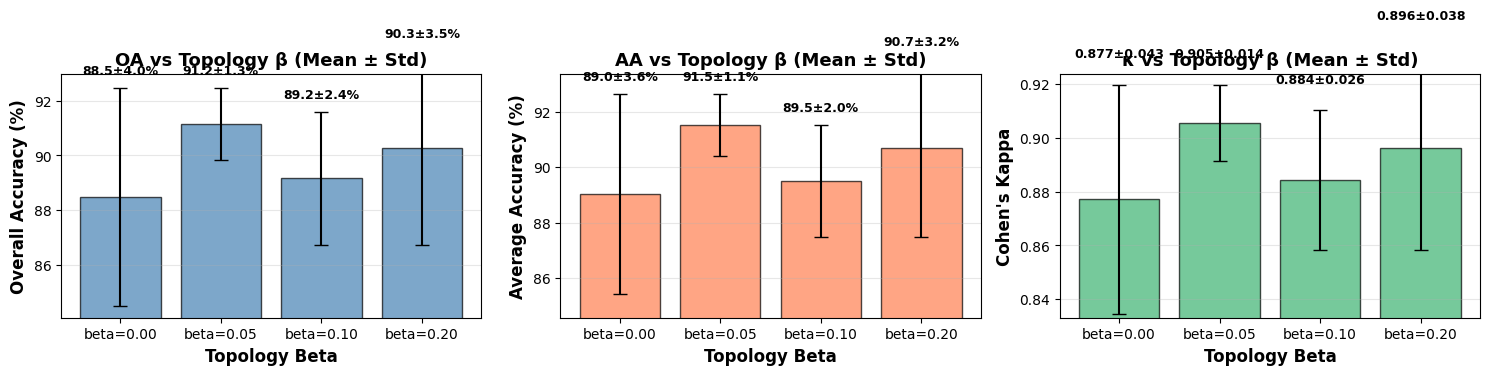

In [ ]:
# =============================================================================
# Ablation: Topology Beta for Indian Pines
#
# Tests TOPOLOGY_BETA ∈ {0, 0.05, 0.1, 0.2} with winning configs:
# - LR_QUANTUM = 0.0005 (from Phase 1 HP search)
# - N_QUBITS = 4 (from Phase 2a qubit ablation)
# - N_REUP_LAYERS = 4 (from Phase 2b depth ablation)
# - 2 seeds (42, 0) for robust results
#
# Output: Ablation table + winner → use in Phase 2d (validation on test set)
#         + visualization graphs for paper
# =============================================================================

import time
GLOBAL_START = time.time()

def elapsed():
    return time.time() - GLOBAL_START

print("[Setup] Importing libraries...")
t0 = time.time()

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from scipy.io import loadmat
from sklearn.metrics import accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"[Setup] GPU detected: {torch.cuda.get_device_name(0)}")

print(f"[Setup] Device: {DEVICE}")
print(f"[Setup] Completed in {time.time()-t0:.2f}s | Total: {elapsed():.2f}s")

# =============================================================================
# ABLATION CONFIGURATION
# =============================================================================
BETA_CONFIGS = [
    {"name": "beta=0.00",  "TOPOLOGY_BETA": 0.00},
    {"name": "beta=0.05",  "TOPOLOGY_BETA": 0.05},
    {"name": "beta=0.10",  "TOPOLOGY_BETA": 0.10},
    {"name": "beta=0.20",  "TOPOLOGY_BETA": 0.20},
]
ABLATION_SEEDS = [42, 0]  # 2 seeds for robust beta ablation

# Winning configs from previous ablations
LR_QUANTUM_WINNER = 0.0005
N_QUBITS_WINNER = 4
N_REUP_LAYERS_WINNER = 4

print(f"\n[Ablation] Beta values: {[c['TOPOLOGY_BETA'] for c in BETA_CONFIGS]}")
print(f"[Ablation] LR_QUANTUM: {LR_QUANTUM_WINNER}")
print(f"[Ablation] N_QUBITS: {N_QUBITS_WINNER}")
print(f"[Ablation] N_REUP_LAYERS: {N_REUP_LAYERS_WINNER}")
print(f"[Ablation] Seeds: {ABLATION_SEEDS}")
print(f"[Ablation] Total runs: {len(BETA_CONFIGS) * len(ABLATION_SEEDS)}")

# =============================================================================
# DATASET LOADING
# =============================================================================
print("\n" + "=" * 60)
print("[Data] Loading Indian Pines...")
t0 = time.time()

DATA_PATH = r"indian pines data\Indian_pines_corrected.mat"
GT_PATH = r"indian pines data\Indian_pines_gt.mat"

data_mat = loadmat(DATA_PATH)
gt_mat = loadmat(GT_PATH)
data_keys = [k for k in data_mat.keys() if not k.startswith("__")]
gt_keys = [k for k in gt_mat.keys() if not k.startswith("__")]
data_raw = data_mat[data_keys[0]].astype(np.float32)
gt = gt_mat[gt_keys[0]].astype(np.int64)

H, W, N_BANDS = data_raw.shape
unique_labels = np.sort(np.unique(gt))
unique_labels = unique_labels[unique_labels > 0]
NUM_CLASSES = len(unique_labels)
LABEL_MAP = {orig: idx for idx, orig in enumerate(unique_labels)}

print(f"[Data] Image: ({H}, {W}, {N_BANDS}), Classes: {NUM_CLASSES}")

# =============================================================================
# FIXED HYPERPARAMETERS
# =============================================================================
N_SUB_ROTATIONS = 3
ROUTER_BOTTLENECK = 32
SPATIAL_DIM = 32
FUSION_DIM = 64
DROPOUT = 0.2
PATCH_SIZE = 9
TRAIN_SAMPLES_PER_CLASS = 30
VAL_SAMPLES_PER_CLASS = 15
HALF = PATCH_SIZE // 2

BATCH_SIZE = 16
N_EPOCHS = 50
LR_CLASSICAL = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 5.0
FOCAL_GAMMA = 2.0

# =============================================================================
# PREPROCESSING
# =============================================================================
print("\n" + "=" * 60)
print("[Preprocess] Normalizing and extracting patches...")
t0 = time.time()

data_norm = np.zeros_like(data_raw)
for b in range(N_BANDS):
    band = data_raw[:, :, b]
    bmin, bmax = band.min(), band.max()
    if bmax - bmin > 0:
        data_norm[:, :, b] = (band - bmin) / (bmax - bmin)

data_padded = np.pad(data_norm, ((HALF, HALF), (HALF, HALF), (0, 0)), mode="reflect")
labeled_indices = np.argwhere(gt > 0)
N_labeled = len(labeled_indices)

patches = np.zeros((N_labeled, PATCH_SIZE, PATCH_SIZE, N_BANDS), dtype=np.float32)
spectra = np.zeros((N_labeled, N_BANDS), dtype=np.float32)
labels = np.zeros(N_labeled, dtype=np.int64)

for idx, (i, j) in enumerate(labeled_indices):
    patches[idx] = data_padded[i:i + PATCH_SIZE, j:j + PATCH_SIZE, :]
    spectra[idx] = data_norm[i, j, :]
    labels[idx] = LABEL_MAP[gt[i, j]]

print(f"[Preprocess] Extracted {N_labeled} patches in {time.time()-t0:.2f}s")

# =============================================================================
# QUANTUM CIRCUIT (fixed for N_QUBITS=4)
# =============================================================================
def make_quantum_circuit(n_qubits, n_reup_layers, n_sub_rotations):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(enc_angles, thetas, ent_angles):
        for l in range(n_reup_layers):
            for q in range(n_qubits):
                for s in range(n_sub_rotations):
                    idx = (l * n_qubits * n_sub_rotations + q * n_sub_rotations + s) * 3
                    qml.Rot(
                        thetas[idx]     + enc_angles[idx],
                        thetas[idx + 1] + enc_angles[idx + 1],
                        thetas[idx + 2] + enc_angles[idx + 2],
                        wires=q
                    )
            if l < n_reup_layers - 1:
                for q in range(n_qubits):
                    ent_idx = l * n_qubits + q
                    qml.CRZ(ent_angles[ent_idx], wires=[q, (q + 1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    return circuit

circuit = make_quantum_circuit(N_QUBITS_WINNER, N_REUP_LAYERS_WINNER, N_SUB_ROTATIONS)

# =============================================================================
# MODEL CLASSES
# =============================================================================
class AdaptiveQuantumBranch(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 bottleneck=32, circuit=None):
        super().__init__()
        self.n_bands = n_bands
        self.n_qubits = n_qubits
        self.n_reup_layers = n_reup_layers
        self.n_sub_rotations = n_sub_rotations
        self.circuit = circuit
        encoding_dim = n_qubits * n_sub_rotations * 3

        self.band_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck),
                nn.ReLU(),
                nn.Linear(bottleneck, n_bands),
                nn.Sigmoid()
            ) for _ in range(n_reup_layers)
        ])
        self.projections = nn.ModuleList([
            nn.Linear(n_bands, encoding_dim) for _ in range(n_reup_layers)
        ])
        self.ent_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck),
                nn.ReLU(),
                nn.Linear(bottleneck, n_qubits),
                nn.Tanh()
            ) for _ in range(n_reup_layers - 1)
        ])
        total_thetas = n_reup_layers * encoding_dim
        self.thetas = nn.Parameter(torch.randn(total_thetas) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        routing_weights, ent_weights = [], []
        all_enc, all_ent = [], []

        for l in range(self.n_reup_layers):
            alpha = self.band_routers[l](x)
            routing_weights.append(alpha)
            z = alpha * x
            enc = self.projections[l](z) * math.pi
            all_enc.append(enc)
            if l < self.n_reup_layers - 1:
                phi = self.ent_routers[l](x) * math.pi
                ent_weights.append(phi)
                all_ent.append(phi)

        flat_enc = torch.cat(all_enc, dim=1)
        flat_ent = torch.cat(all_ent, dim=1)
        q_features = torch.zeros(batch_size, self.n_qubits, device=x.device)
        for i in range(batch_size):
            result = self.circuit(flat_enc[i], self.thetas, flat_ent[i])
            q_features[i] = torch.stack(result)
        return q_features, routing_weights, ent_weights


class SpatialBranch(nn.Module):
    def __init__(self, n_bands, spatial_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=(7, 3, 3), stride=(3, 1, 1), padding=(3, 1, 1)),
            nn.BatchNorm3d(8), nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(2, 1, 1), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 1, 1), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc = nn.Linear(32, spatial_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.relu(self.fc(x))


class AdaptiveReuploadClassifier(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 n_classes, circuit, router_bottleneck=32, spatial_dim=32,
                 fusion_dim=64, dropout=0.2):
        super().__init__()
        self.quantum_branch = AdaptiveQuantumBranch(
            n_bands, n_qubits, n_reup_layers, n_sub_rotations,
            router_bottleneck, circuit
        )
        self.spatial_branch = SpatialBranch(n_bands, spatial_dim)
        self.q_bn = nn.BatchNorm1d(n_qubits)
        self.s_bn = nn.BatchNorm1d(spatial_dim)
        fusion_input = n_qubits + spatial_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_input, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, n_classes)
        )

    def forward(self, patches, spectra):
        q_features, routing_weights, ent_weights = self.quantum_branch(spectra)
        s_features = self.spatial_branch(patches)
        q_normed = self.q_bn(q_features)
        s_normed = self.s_bn(s_features)
        fused = torch.cat([q_normed, s_normed], dim=1)
        logits = self.classifier(fused)
        return logits, routing_weights, ent_weights

# =============================================================================
# LOSSES
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        return ((1.0 - p_t) ** self.gamma * ce).mean()


def topology_diversity_loss(ent_weights, labels, n_classes, beta=0.05):
    if not ent_weights or beta == 0.0:
        return torch.tensor(0.0, device=labels.device)
    phi = torch.cat(ent_weights, dim=1)
    class_means = []
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            class_means.append(phi[mask].mean(dim=0))
    if len(class_means) < 2:
        return torch.zeros(1, device=phi.device).squeeze()
    class_means_t = torch.stack(class_means)
    inter_class_var = class_means_t.var(dim=0).mean()
    total_var = phi.var(dim=0).mean().clamp(min=1e-8)
    eta_sq = (inter_class_var / total_var).clamp(max=1.0)
    return -beta * eta_sq


def set_eval_with_bn_train(module):
    module.eval()
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm3d)):
            m.training = True

# =============================================================================
# TRAIN-ONE-RUN FUNCTION
# =============================================================================
def train_one_run(seed, beta):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # Data split
    rng = np.random.RandomState(seed)
    train_sel, val_sel = [], []
    for c in range(NUM_CLASSES):
        class_idx = np.where(labels == c)[0]
        rng.shuffle(class_idx)
        n_train = min(TRAIN_SAMPLES_PER_CLASS, max(1, len(class_idx) // 3))
        n_val = min(VAL_SAMPLES_PER_CLASS, max(1, (len(class_idx) - n_train) // 2))
        train_sel.extend(class_idx[:n_train].tolist())
        val_sel.extend(class_idx[n_train:n_train + n_val].tolist())
    train_sel = np.array(train_sel, dtype=np.int64)
    val_sel = np.array(val_sel, dtype=np.int64)
    rng.shuffle(train_sel)
    rng.shuffle(val_sel)

    train_patches_t = torch.FloatTensor(patches[train_sel].transpose(0, 3, 1, 2)[:, np.newaxis])
    val_patches_t   = torch.FloatTensor(patches[val_sel].transpose(0, 3, 1, 2)[:, np.newaxis])
    train_spectra_t = torch.FloatTensor(spectra[train_sel])
    val_spectra_t   = torch.FloatTensor(spectra[val_sel])
    train_labels_t  = torch.LongTensor(labels[train_sel])
    val_labels_t    = torch.LongTensor(labels[val_sel])

    train_ds = TensorDataset(train_patches_t, train_spectra_t, train_labels_t)
    val_ds   = TensorDataset(val_patches_t,   val_spectra_t,   val_labels_t)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    # Model
    model = AdaptiveReuploadClassifier(
        n_bands=N_BANDS, n_qubits=N_QUBITS_WINNER,
        n_reup_layers=N_REUP_LAYERS_WINNER, n_sub_rotations=N_SUB_ROTATIONS,
        n_classes=NUM_CLASSES, circuit=circuit,
        router_bottleneck=ROUTER_BOTTLENECK, spatial_dim=SPATIAL_DIM,
        fusion_dim=FUSION_DIM, dropout=DROPOUT
    ).to(DEVICE)

    quantum_params = list(model.quantum_branch.parameters())
    classical_params = (
        list(model.spatial_branch.parameters()) +
        list(model.q_bn.parameters()) +
        list(model.s_bn.parameters()) +
        list(model.classifier.parameters())
    )
    optimizer = optim.Adam([
        {"params": quantum_params,   "lr": LR_QUANTUM_WINNER, "weight_decay": 0},
        {"params": classical_params, "lr": LR_CLASSICAL,      "weight_decay": WEIGHT_DECAY}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = FocalLoss(gamma=FOCAL_GAMMA)

    best_val_acc = -1.0
    val_preds_best = None
    val_labels_best = None
    epoch_topo_losses = []

    for epoch in range(1, N_EPOCHS + 1):
        ep_start = time.time()
        model.train()
        train_correct, train_total = 0, 0
        epoch_topo_loss = 0.0
        n_batches = 0

        for patches_b, spectra_b, labels_b in train_loader:
            patches_b = patches_b.to(DEVICE)
            spectra_b = spectra_b.to(DEVICE)
            labels_b = labels_b.to(DEVICE)

            optimizer.zero_grad()
            logits, _, ent_w = model(patches_b, spectra_b)
            cls_loss = criterion(logits, labels_b)
            topo_loss = topology_diversity_loss(ent_w, labels_b, NUM_CLASSES, beta)
            loss = cls_loss + topo_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()

            train_correct += (logits.argmax(1) == labels_b).sum().item()
            train_total += labels_b.size(0)
            epoch_topo_loss += topo_loss.item()
            n_batches += 1

        epoch_topo_loss /= max(n_batches, 1)
        epoch_topo_losses.append(epoch_topo_loss)
        train_acc = train_correct / train_total

        # Validate
        set_eval_with_bn_train(model)
        val_correct, val_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for patches_b, spectra_b, labels_b in val_loader:
                logits, _, _ = model(patches_b.to(DEVICE), spectra_b.to(DEVICE))
                preds = logits.argmax(1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels_b.numpy())
                val_correct += (logits.argmax(1).cpu() == labels_b).sum().item()
                val_total += labels_b.size(0)

        val_acc = val_correct / val_total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            val_preds_best = np.array(all_preds)
            val_labels_best = np.array(all_labels)

        scheduler.step()
        ep_time = time.time() - ep_start
        print(f"    [β={beta:.2f}] Ep {epoch:02d}/{N_EPOCHS} | "
              f"train={train_acc*100:.1f}% val={val_acc*100:.1f}% topo_loss={epoch_topo_loss:.4f} | {ep_time:.1f}s",
              end="\r")
    print()

    # Compute metrics on best val
    val_aa = 0.0
    if val_labels_best is not None:
        for c in range(NUM_CLASSES):
            mask = val_labels_best == c
            if mask.sum() > 0:
                val_aa += accuracy_score(val_labels_best[mask], val_preds_best[mask])
        val_aa /= NUM_CLASSES

    val_kappa = cohen_kappa_score(val_labels_best, val_preds_best) if val_labels_best is not None else 0.0

    return best_val_acc, val_aa, val_kappa, epoch_topo_losses

# =============================================================================
# ABLATION LOOP
# =============================================================================
print("\n" + "=" * 60)
print("[Ablation] Starting topology beta ablation...")
ablation_start = time.time()

results = {cfg["name"]: {} for cfg in BETA_CONFIGS}
topo_loss_history = {cfg["name"]: [] for cfg in BETA_CONFIGS}

for cfg in BETA_CONFIGS:
    beta = cfg["TOPOLOGY_BETA"]

    for seed in ABLATION_SEEDS:
        print(f"\n[Ablation] Config={cfg['name']} | Seed={seed}")
        run_start = time.time()
        oa, aa, kappa, topo_losses = train_one_run(seed, beta)
        results[cfg["name"]][seed] = {"OA": oa, "AA": aa, "Kappa": kappa}
        topo_loss_history[cfg["name"]].append(topo_losses)
        print(f"[Ablation] {cfg['name']} seed={seed} → OA={oa*100:.2f}% AA={aa*100:.2f}% κ={kappa:.4f} | "
              f"elapsed {(time.time()-run_start)/60:.1f}m")

ablation_time = time.time() - ablation_start

# =============================================================================
# RESULTS TABLE
# =============================================================================
print("\n" + "=" * 60)
print("[Ablation] RESULTS")
print("=" * 60)
print(f"\n{'Config':<12s} {'Metric':<8s} " +
      " ".join(f"seed={s:>3d}" for s in ABLATION_SEEDS) +
      f"  {'Mean':>7s}  {'Std':>6s}")
print("-" * 70)

config_oas = []
for cfg in BETA_CONFIGS:
    for metric in ["OA", "AA", "Kappa"]:
        values = [results[cfg["name"]][s][metric] for s in ABLATION_SEEDS]
        mean_val = np.mean(values)
        std_val = np.std(values)
        val_str = " ".join(f"{v*100:>7.2f}%" if metric != "Kappa" else f"{v:>7.4f}" for v in values)
        fmt_mean = f"{mean_val*100:>6.2f}%" if metric != "Kappa" else f"{mean_val:>6.4f}"
        fmt_std = f"{std_val*100:>5.2f}%" if metric != "Kappa" else f"{std_val:>5.4f}"
        print(f"{cfg['name']:<12s} {metric:<8s} {val_str}  {fmt_mean}  {fmt_std}")

    oa_mean = np.mean([results[cfg["name"]][s]["OA"] for s in ABLATION_SEEDS])
    config_oas.append((cfg, oa_mean))
    print()

winner = max(config_oas, key=lambda x: x[1])
winner_cfg, winner_oa = winner

print("=" * 70)
print(f"[Ablation] WINNER: {winner_cfg['name']}")
print(f"  TOPOLOGY_BETA = {winner_cfg['TOPOLOGY_BETA']}")
print(f"  Mean val OA = {winner_oa*100:.2f}%")
print("=" * 70)

print(f"\n[Ablation] Paste into Phase 2d (validation on test set):")
print(f"  TOPOLOGY_BETA = {winner_cfg['TOPOLOGY_BETA']}")
print(f"  N_QUBITS = {N_QUBITS_WINNER}")
print(f"  N_REUP_LAYERS = {N_REUP_LAYERS_WINNER}")

print(f"\n[Ablation] Total time: {ablation_time/60:.1f} min | Wall time: {elapsed()/60:.1f} min")

# =============================================================================
# VISUALIZATIONS
# =============================================================================
print("\n" + "=" * 60)
print("[Viz] Generating graphs for paper...")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

beta_labels = [cfg["name"] for cfg in BETA_CONFIGS]
oa_vals = [np.mean([results[cfg["name"]][s]["OA"] for s in ABLATION_SEEDS]) * 100 for cfg in BETA_CONFIGS]
oa_stds = [np.std([results[cfg["name"]][s]["OA"] for s in ABLATION_SEEDS]) * 100 for cfg in BETA_CONFIGS]
aa_vals = [np.mean([results[cfg["name"]][s]["AA"] for s in ABLATION_SEEDS]) * 100 for cfg in BETA_CONFIGS]
aa_stds = [np.std([results[cfg["name"]][s]["AA"] for s in ABLATION_SEEDS]) * 100 for cfg in BETA_CONFIGS]
kappa_vals = [np.mean([results[cfg["name"]][s]["Kappa"] for s in ABLATION_SEEDS]) for cfg in BETA_CONFIGS]
kappa_stds = [np.std([results[cfg["name"]][s]["Kappa"] for s in ABLATION_SEEDS]) for cfg in BETA_CONFIGS]

# OA plot
axes[0].bar(beta_labels, oa_vals, yerr=oa_stds, color='steelblue', alpha=0.7, edgecolor='black', capsize=5)
axes[0].set_ylabel('Overall Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Topology Beta', fontsize=12, fontweight='bold')
axes[0].set_title('OA vs Topology β (Mean ± Std)', fontsize=13, fontweight='bold')
axes[0].set_ylim([min(oa_vals) * 0.95, max(oa_vals) * 1.02])
axes[0].grid(axis='y', alpha=0.3)
for i, (v, s) in enumerate(zip(oa_vals, oa_stds)):
    axes[0].text(i, v + s + 0.5, f'{v:.1f}±{s:.1f}%', ha='center', fontsize=9, fontweight='bold')

# AA plot
axes[1].bar(beta_labels, aa_vals, yerr=aa_stds, color='coral', alpha=0.7, edgecolor='black', capsize=5)
axes[1].set_ylabel('Average Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Topology Beta', fontsize=12, fontweight='bold')
axes[1].set_title('AA vs Topology β (Mean ± Std)', fontsize=13, fontweight='bold')
axes[1].set_ylim([min(aa_vals) * 0.95, max(aa_vals) * 1.02])
axes[1].grid(axis='y', alpha=0.3)
for i, (v, s) in enumerate(zip(aa_vals, aa_stds)):
    axes[1].text(i, v + s + 0.5, f'{v:.1f}±{s:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Kappa plot
axes[2].bar(beta_labels, kappa_vals, yerr=kappa_stds, color='mediumseagreen', alpha=0.7, edgecolor='black', capsize=5)
axes[2].set_ylabel('Cohen\'s Kappa', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Topology Beta', fontsize=12, fontweight='bold')
axes[2].set_title('κ vs Topology β (Mean ± Std)', fontsize=13, fontweight='bold')
axes[2].set_ylim([min(kappa_vals) * 0.95, max(kappa_vals) * 1.02])
axes[2].grid(axis='y', alpha=0.3)
for i, (v, s) in enumerate(zip(kappa_vals, kappa_stds)):
    axes[2].text(i, v + s + 0.01, f'{v:.3f}±{s:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(r'images_ablation\ablate_beta_indianpines_metrics.png', dpi=300, bbox_inches='tight')
print("[Viz] Saved: ablate_beta_indianpines_metrics.png")
plt.close()

# Topology loss curves over epochs (averaged across seeds)
fig, ax = plt.subplots(figsize=(10, 6))

for cfg in BETA_CONFIGS:
    loss_histories = topo_loss_history[cfg["name"]]
    if len(loss_histories) > 0:
        mean_losses = np.mean(loss_histories, axis=0)
        ax.plot(range(1, len(mean_losses) + 1), mean_losses, marker='o', markersize=3,
                label=cfg["name"], linewidth=2, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Topology Diversity Loss (Avg per batch)', fontsize=12, fontweight='bold')
ax.set_title('Topology Loss Evolution During Training\n(Indian Pines, N_QUBITS=4, N_REUP_LAYERS=4)',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r'images_ablation\ablate_beta_indianpines_topo_loss.png', dpi=300, bbox_inches='tight')
print("[Viz] Saved: ablate_beta_indianpines_topo_loss.png")
plt.close()

print("[Viz] All visualizations complete.")
print("\n" + "=" * 60)
print("[Done] Ablation script finished successfully.")
print("=" * 60)

## [Recovery] Regenerate saved ablation figures without rerunning training

Run the next two cells only if the overnight ablation already finished in the current kernel and you just need the figures saved into `images_ablation`.


In [4]:
from pathlib import Path

required_objects = ["results", "topo_loss_history", "BETA_CONFIGS", "ABLATION_SEEDS", "np", "plt"]
missing_objects = [name for name in required_objects if name not in globals()]

output_dir = Path("images_ablation")
output_dir.mkdir(exist_ok=True)

if missing_objects:
    print("[Recovery] Missing in-memory objects:", missing_objects)
    print("[Recovery] This means the original ablation kernel state is gone.")
    print("[Recovery] In that case, do not rerun the whole notebook yet; ask Codex to reconstruct only what is recoverable.")
else:
    print("[Recovery] Kernel still has the ablation objects.")
    print(f"[Recovery] Figures will be written to: {output_dir.resolve()}")


[Recovery] Kernel still has the ablation objects.
[Recovery] Figures will be written to: C:\Users\saika\OneDrive\Desktop\test 6\images_ablation


[Recovery] Regenerating ablation figures from in-memory results...


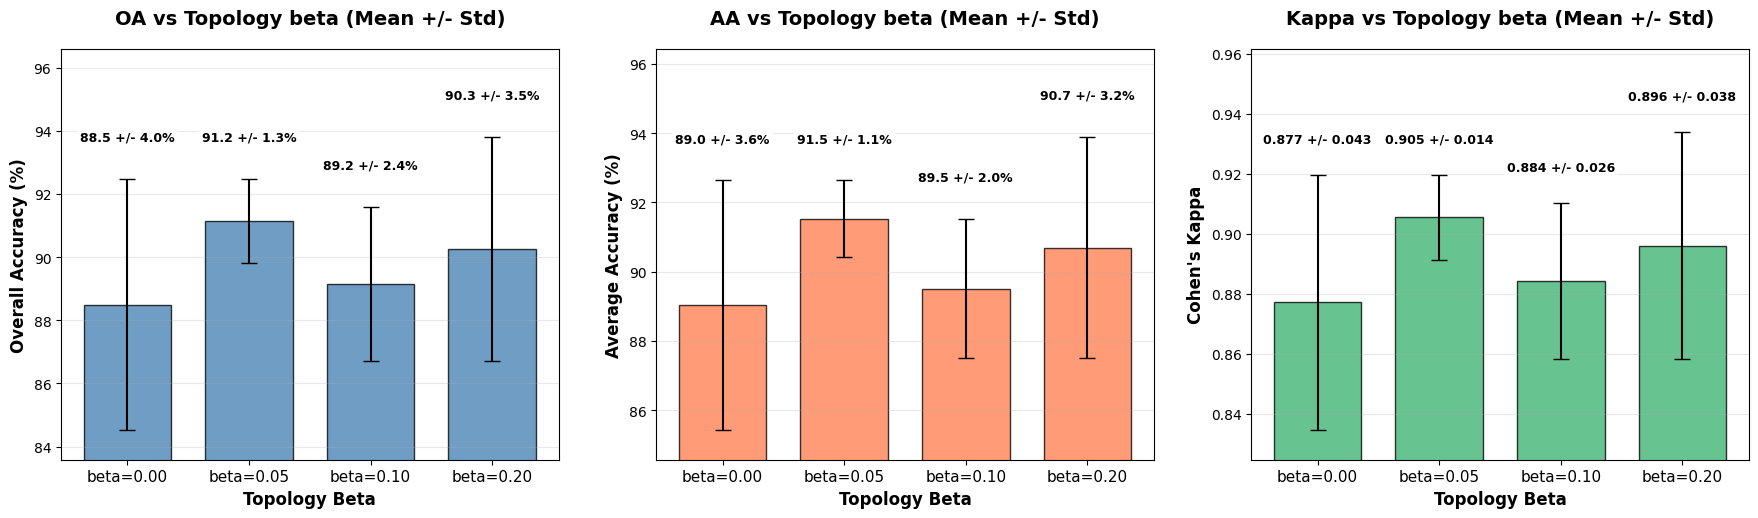

[Recovery] Saved: images_ablation\ablate_beta_indianpines_metrics.png


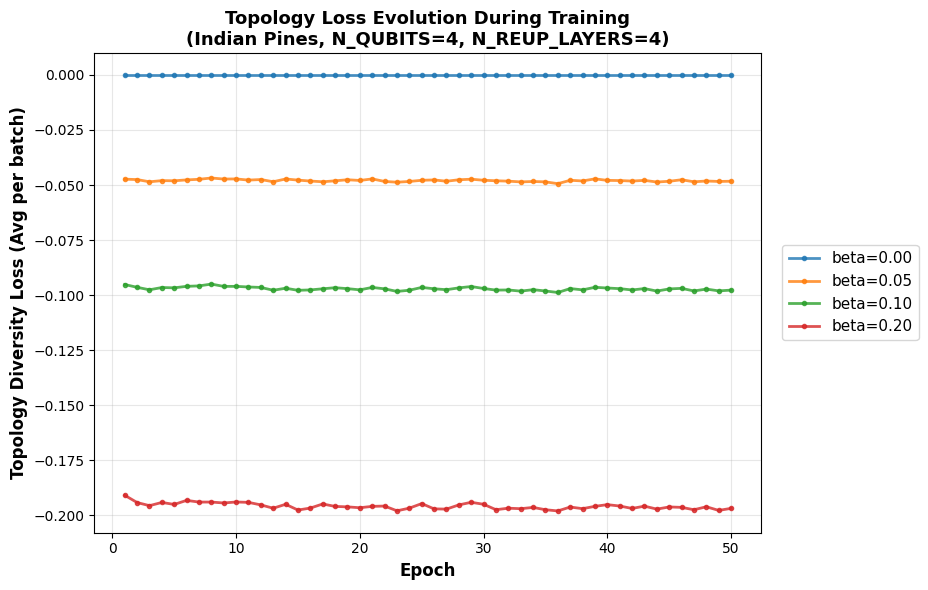

[Recovery] Saved: images_ablation\ablate_beta_indianpines_topo_loss.png
[Recovery] Figure regeneration complete.


In [6]:
from pathlib import Path

required_objects = ["results", "topo_loss_history", "BETA_CONFIGS", "ABLATION_SEEDS", "np", "plt"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "[Recovery] Cannot regenerate figures because these objects are missing from memory: "
        + ", ".join(missing_objects)
    )

output_dir = Path("images_ablation")
output_dir.mkdir(exist_ok=True)

print("[Recovery] Regenerating ablation figures from in-memory results...")

beta_labels = [cfg["name"] for cfg in BETA_CONFIGS]
oa_vals = [np.mean([results[cfg["name"]][s]["OA"] for s in ABLATION_SEEDS]) * 100 for cfg in BETA_CONFIGS]
oa_stds = [np.std([results[cfg["name"]][s]["OA"] for s in ABLATION_SEEDS]) * 100 for cfg in BETA_CONFIGS]
aa_vals = [np.mean([results[cfg["name"]][s]["AA"] for s in ABLATION_SEEDS]) * 100 for cfg in BETA_CONFIGS]
aa_stds = [np.std([results[cfg["name"]][s]["AA"] for s in ABLATION_SEEDS]) * 100 for cfg in BETA_CONFIGS]
kappa_vals = [np.mean([results[cfg["name"]][s]["Kappa"] for s in ABLATION_SEEDS]) for cfg in BETA_CONFIGS]
kappa_stds = [np.std([results[cfg["name"]][s]["Kappa"] for s in ABLATION_SEEDS]) for cfg in BETA_CONFIGS]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))

def stylize_metric_axis(ax, labels, values, errors, color, ylabel, title, is_percent):
    ax.bar(labels, values, yerr=errors, color=color, alpha=0.78, edgecolor="black", capsize=6, width=0.72)
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_xlabel("Topology Beta", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=18)
    ax.grid(axis="y", alpha=0.28)
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=10)

    lower = min(v - e for v, e in zip(values, errors))
    upper = max(v + e for v, e in zip(values, errors))
    span = max(upper - lower, 1.0 if is_percent else 0.02)
    label_gap = span * (0.12 if is_percent else 0.10)
    top_padding = span * (0.30 if is_percent else 0.28)
    bottom_padding = span * 0.10
    ax.set_ylim(lower - bottom_padding, upper + top_padding)

    for i, (v, e) in enumerate(zip(values, errors)):
        label = f"{v:.1f} +/- {e:.1f}%" if is_percent else f"{v:.3f} +/- {e:.3f}"
        ax.text(
            i,
            v + e + label_gap,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.92},
        )

stylize_metric_axis(
    axes[0], beta_labels, oa_vals, oa_stds, "steelblue",
    "Overall Accuracy (%)", "OA vs Topology beta (Mean +/- Std)", True
)
stylize_metric_axis(
    axes[1], beta_labels, aa_vals, aa_stds, "coral",
    "Average Accuracy (%)", "AA vs Topology beta (Mean +/- Std)", True
)
stylize_metric_axis(
    axes[2], beta_labels, kappa_vals, kappa_stds, "mediumseagreen",
    "Cohen's Kappa", "Kappa vs Topology beta (Mean +/- Std)", False
)

fig.tight_layout(pad=2.2, w_pad=2.4)
metrics_path = output_dir / "ablate_beta_indianpines_metrics.png"
plt.savefig(metrics_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f"[Recovery] Saved: {metrics_path}")

fig, ax = plt.subplots(figsize=(11.5, 6))
for cfg in BETA_CONFIGS:
    loss_histories = topo_loss_history[cfg["name"]]
    if len(loss_histories) > 0:
        mean_losses = np.mean(loss_histories, axis=0)
        ax.plot(
            range(1, len(mean_losses) + 1),
            mean_losses,
            marker="o",
            markersize=3,
            label=cfg["name"],
            linewidth=2,
            alpha=0.8,
        )

ax.set_xlabel("Epoch", fontsize=12, fontweight="bold")
ax.set_ylabel("Topology Diversity Loss (Avg per batch)", fontsize=12, fontweight="bold")
ax.set_title(
    "Topology Loss Evolution During Training\n(Indian Pines, N_QUBITS=4, N_REUP_LAYERS=4)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=11, frameon=True)
ax.grid(alpha=0.3)

fig.tight_layout(rect=(0, 0, 0.82, 1))
topo_path = output_dir / "ablate_beta_indianpines_topo_loss.png"
plt.savefig(topo_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f"[Recovery] Saved: {topo_path}")
print("[Recovery] Figure regeneration complete.")




In [8]:
# =============================================================================
# Phase 2d: Test Set Validation (Single Run, Seed 42)
#
# Winning config from all ablations, evaluated on NEVER-TOUCHED test set:
# - LR_QUANTUM = 0.0005
# - N_QUBITS = 4
# - N_REUP_LAYERS = 4
# - TOPOLOGY_BETA = 0.05
# - 1 seed (42) only — sanity check before Phase 3
#
# Goal: Verify val OA ≈ test OA (no huge gap = model generalizes)
# Output: Test OA, AA, κ + check for generalization gap
# =============================================================================

import time
GLOBAL_START = time.time()

def elapsed():
    return time.time() - GLOBAL_START

print("[Setup] Importing libraries...")
t0 = time.time()

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from scipy.io import loadmat
from sklearn.metrics import accuracy_score, cohen_kappa_score
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"[Setup] GPU detected: {torch.cuda.get_device_name(0)}")

print(f"[Setup] Device: {DEVICE}")
print(f"[Setup] Completed in {time.time()-t0:.2f}s | Total: {elapsed():.2f}s")

# =============================================================================
# WINNING CONFIGURATION
# =============================================================================
LR_QUANTUM = 0.0005
N_QUBITS = 4
N_REUP_LAYERS = 4
TOPOLOGY_BETA = 0.05
TEST_SEED = 42

print(f"\n[Config] Phase 2d (Validation Run)")
print(f"  LR_QUANTUM: {LR_QUANTUM}")
print(f"  N_QUBITS: {N_QUBITS}")
print(f"  N_REUP_LAYERS: {N_REUP_LAYERS}")
print(f"  TOPOLOGY_BETA: {TOPOLOGY_BETA}")
print(f"  Seed: {TEST_SEED}")

# =============================================================================
# DATASET LOADING
# =============================================================================
print("\n" + "=" * 60)
print("[Data] Loading Indian Pines...")
t0 = time.time()

DATA_PATH = r"indian pines data\Indian_pines_corrected.mat"
GT_PATH = r"indian pines data\Indian_pines_gt.mat"

data_mat = loadmat(DATA_PATH)
gt_mat = loadmat(GT_PATH)
data_keys = [k for k in data_mat.keys() if not k.startswith("__")]
gt_keys = [k for k in gt_mat.keys() if not k.startswith("__")]
data_raw = data_mat[data_keys[0]].astype(np.float32)
gt = gt_mat[gt_keys[0]].astype(np.int64)

H, W, N_BANDS = data_raw.shape
unique_labels = np.sort(np.unique(gt))
unique_labels = unique_labels[unique_labels > 0]
NUM_CLASSES = len(unique_labels)
LABEL_MAP = {orig: idx for idx, orig in enumerate(unique_labels)}

print(f"[Data] Image: ({H}, {W}, {N_BANDS}), Classes: {NUM_CLASSES}")

# =============================================================================
# FIXED HYPERPARAMETERS
# =============================================================================
N_SUB_ROTATIONS = 3
ROUTER_BOTTLENECK = 32
SPATIAL_DIM = 32
FUSION_DIM = 64
DROPOUT = 0.2
PATCH_SIZE = 9
TRAIN_SAMPLES_PER_CLASS = 30
VAL_SAMPLES_PER_CLASS = 15
TEST_SAMPLES_PER_CLASS = 50
HALF = PATCH_SIZE // 2

BATCH_SIZE = 16
N_EPOCHS = 50
LR_CLASSICAL = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 5.0
FOCAL_GAMMA = 2.0

# =============================================================================
# PREPROCESSING
# =============================================================================
print("\n" + "=" * 60)
print("[Preprocess] Normalizing and extracting patches...")
t0 = time.time()

data_norm = np.zeros_like(data_raw)
for b in range(N_BANDS):
    band = data_raw[:, :, b]
    bmin, bmax = band.min(), band.max()
    if bmax - bmin > 0:
        data_norm[:, :, b] = (band - bmin) / (bmax - bmin)

data_padded = np.pad(data_norm, ((HALF, HALF), (HALF, HALF), (0, 0)), mode="reflect")
labeled_indices = np.argwhere(gt > 0)
N_labeled = len(labeled_indices)

patches = np.zeros((N_labeled, PATCH_SIZE, PATCH_SIZE, N_BANDS), dtype=np.float32)
spectra = np.zeros((N_labeled, N_BANDS), dtype=np.float32)
labels = np.zeros(N_labeled, dtype=np.int64)

for idx, (i, j) in enumerate(labeled_indices):
    patches[idx] = data_padded[i:i + PATCH_SIZE, j:j + PATCH_SIZE, :]
    spectra[idx] = data_norm[i, j, :]
    labels[idx] = LABEL_MAP[gt[i, j]]

print(f"[Preprocess] Extracted {N_labeled} patches in {time.time()-t0:.2f}s")

# =============================================================================
# QUANTUM CIRCUIT
# =============================================================================
def make_quantum_circuit(n_qubits, n_reup_layers, n_sub_rotations):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(enc_angles, thetas, ent_angles):
        for l in range(n_reup_layers):
            for q in range(n_qubits):
                for s in range(n_sub_rotations):
                    idx = (l * n_qubits * n_sub_rotations + q * n_sub_rotations + s) * 3
                    qml.Rot(
                        thetas[idx]     + enc_angles[idx],
                        thetas[idx + 1] + enc_angles[idx + 1],
                        thetas[idx + 2] + enc_angles[idx + 2],
                        wires=q
                    )
            if l < n_reup_layers - 1:
                for q in range(n_qubits):
                    ent_idx = l * n_qubits + q
                    qml.CRZ(ent_angles[ent_idx], wires=[q, (q + 1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    return circuit

circuit = make_quantum_circuit(N_QUBITS, N_REUP_LAYERS, N_SUB_ROTATIONS)

# =============================================================================
# MODEL CLASSES
# =============================================================================
class AdaptiveQuantumBranch(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 bottleneck=32, circuit=None):
        super().__init__()
        self.n_bands = n_bands
        self.n_qubits = n_qubits
        self.n_reup_layers = n_reup_layers
        self.n_sub_rotations = n_sub_rotations
        self.circuit = circuit
        encoding_dim = n_qubits * n_sub_rotations * 3

        self.band_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck),
                nn.ReLU(),
                nn.Linear(bottleneck, n_bands),
                nn.Sigmoid()
            ) for _ in range(n_reup_layers)
        ])
        self.projections = nn.ModuleList([
            nn.Linear(n_bands, encoding_dim) for _ in range(n_reup_layers)
        ])
        self.ent_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck),
                nn.ReLU(),
                nn.Linear(bottleneck, n_qubits),
                nn.Tanh()
            ) for _ in range(n_reup_layers - 1)
        ])
        total_thetas = n_reup_layers * encoding_dim
        self.thetas = nn.Parameter(torch.randn(total_thetas) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        routing_weights, ent_weights = [], []
        all_enc, all_ent = [], []

        for l in range(self.n_reup_layers):
            alpha = self.band_routers[l](x)
            routing_weights.append(alpha)
            z = alpha * x
            enc = self.projections[l](z) * math.pi
            all_enc.append(enc)
            if l < self.n_reup_layers - 1:
                phi = self.ent_routers[l](x) * math.pi
                ent_weights.append(phi)
                all_ent.append(phi)

        flat_enc = torch.cat(all_enc, dim=1)
        flat_ent = torch.cat(all_ent, dim=1)
        q_features = torch.zeros(batch_size, self.n_qubits, device=x.device)
        for i in range(batch_size):
            result = self.circuit(flat_enc[i], self.thetas, flat_ent[i])
            q_features[i] = torch.stack(result)
        return q_features, routing_weights, ent_weights


class SpatialBranch(nn.Module):
    def __init__(self, n_bands, spatial_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=(7, 3, 3), stride=(3, 1, 1), padding=(3, 1, 1)),
            nn.BatchNorm3d(8), nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(2, 1, 1), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 1, 1), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc = nn.Linear(32, spatial_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.relu(self.fc(x))


class AdaptiveReuploadClassifier(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 n_classes, circuit, router_bottleneck=32, spatial_dim=32,
                 fusion_dim=64, dropout=0.2):
        super().__init__()
        self.quantum_branch = AdaptiveQuantumBranch(
            n_bands, n_qubits, n_reup_layers, n_sub_rotations,
            router_bottleneck, circuit
        )
        self.spatial_branch = SpatialBranch(n_bands, spatial_dim)
        self.q_bn = nn.BatchNorm1d(n_qubits)
        self.s_bn = nn.BatchNorm1d(spatial_dim)
        fusion_input = n_qubits + spatial_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_input, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, n_classes)
        )

    def forward(self, patches, spectra):
        q_features, routing_weights, ent_weights = self.quantum_branch(spectra)
        s_features = self.spatial_branch(patches)
        q_normed = self.q_bn(q_features)
        s_normed = self.s_bn(s_features)
        fused = torch.cat([q_normed, s_normed], dim=1)
        logits = self.classifier(fused)
        return logits, routing_weights, ent_weights

# =============================================================================
# LOSSES
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        return ((1.0 - p_t) ** self.gamma * ce).mean()


def topology_diversity_loss(ent_weights, labels, n_classes, beta=0.05):
    if not ent_weights or beta == 0.0:
        return torch.tensor(0.0, device=labels.device)
    phi = torch.cat(ent_weights, dim=1)
    class_means = []
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            class_means.append(phi[mask].mean(dim=0))
    if len(class_means) < 2:
        return torch.zeros(1, device=phi.device).squeeze()
    class_means_t = torch.stack(class_means)
    inter_class_var = class_means_t.var(dim=0).mean()
    total_var = phi.var(dim=0).mean().clamp(min=1e-8)
    eta_sq = (inter_class_var / total_var).clamp(max=1.0)
    return -beta * eta_sq


def set_eval_with_bn_train(module):
    module.eval()
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm3d)):
            m.training = True

# =============================================================================
# DATA SPLIT
# =============================================================================
print("\n" + "=" * 60)
print(f"[Split] Deterministic split with seed={TEST_SEED}...")

np.random.seed(TEST_SEED)
torch.manual_seed(TEST_SEED)

rng = np.random.RandomState(TEST_SEED)
train_sel, val_sel, test_sel = [], [], []

for c in range(NUM_CLASSES):
    class_idx = np.where(labels == c)[0]
    rng.shuffle(class_idx)
    n_train = min(TRAIN_SAMPLES_PER_CLASS, max(1, len(class_idx) // 3))
    n_val = min(VAL_SAMPLES_PER_CLASS, max(1, (len(class_idx) - n_train) // 2))
    n_test = min(TEST_SAMPLES_PER_CLASS, max(1, len(class_idx) - n_train - n_val))

    train_sel.extend(class_idx[:n_train].tolist())
    val_sel.extend(class_idx[n_train:n_train + n_val].tolist())
    test_sel.extend(class_idx[n_train + n_val:n_train + n_val + n_test].tolist())

train_sel = np.array(train_sel, dtype=np.int64)
val_sel = np.array(val_sel, dtype=np.int64)
test_sel = np.array(test_sel, dtype=np.int64)

print(f"[Split] Train: {len(train_sel)}, Val: {len(val_sel)}, Test: {len(test_sel)}")

# =============================================================================
# DATALOADERS
# =============================================================================
train_patches_t = torch.FloatTensor(patches[train_sel].transpose(0, 3, 1, 2)[:, np.newaxis])
val_patches_t   = torch.FloatTensor(patches[val_sel].transpose(0, 3, 1, 2)[:, np.newaxis])
test_patches_t  = torch.FloatTensor(patches[test_sel].transpose(0, 3, 1, 2)[:, np.newaxis])
train_spectra_t = torch.FloatTensor(spectra[train_sel])
val_spectra_t   = torch.FloatTensor(spectra[val_sel])
test_spectra_t  = torch.FloatTensor(spectra[test_sel])
train_labels_t  = torch.LongTensor(labels[train_sel])
val_labels_t    = torch.LongTensor(labels[val_sel])
test_labels_t   = torch.LongTensor(labels[test_sel])

train_ds = TensorDataset(train_patches_t, train_spectra_t, train_labels_t)
val_ds   = TensorDataset(val_patches_t,   val_spectra_t,   val_labels_t)
test_ds  = TensorDataset(test_patches_t,  test_spectra_t,  test_labels_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# =============================================================================
# MODEL TRAINING
# =============================================================================
print("\n" + "=" * 60)
print("[Train] Starting training (Phase 2d validation run)...")

model = AdaptiveReuploadClassifier(
    n_bands=N_BANDS, n_qubits=N_QUBITS,
    n_reup_layers=N_REUP_LAYERS, n_sub_rotations=N_SUB_ROTATIONS,
    n_classes=NUM_CLASSES, circuit=circuit,
    router_bottleneck=ROUTER_BOTTLENECK, spatial_dim=SPATIAL_DIM,
    fusion_dim=FUSION_DIM, dropout=DROPOUT
).to(DEVICE)

quantum_params = list(model.quantum_branch.parameters())
classical_params = (
    list(model.spatial_branch.parameters()) +
    list(model.q_bn.parameters()) +
    list(model.s_bn.parameters()) +
    list(model.classifier.parameters())
)
optimizer = optim.Adam([
    {"params": quantum_params,   "lr": LR_QUANTUM, "weight_decay": 0},
    {"params": classical_params, "lr": LR_CLASSICAL, "weight_decay": WEIGHT_DECAY}
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = FocalLoss(gamma=FOCAL_GAMMA)

best_val_acc = -1.0
best_model_state = None

train_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    ep_start = time.time()
    model.train()
    train_correct, train_total = 0, 0

    for patches_b, spectra_b, labels_b in train_loader:
        patches_b = patches_b.to(DEVICE)
        spectra_b = spectra_b.to(DEVICE)
        labels_b = labels_b.to(DEVICE)

        optimizer.zero_grad()
        logits, _, ent_w = model(patches_b, spectra_b)
        cls_loss = criterion(logits, labels_b)
        topo_loss = topology_diversity_loss(ent_w, labels_b, NUM_CLASSES, TOPOLOGY_BETA)
        loss = cls_loss + topo_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        train_correct += (logits.argmax(1) == labels_b).sum().item()
        train_total += labels_b.size(0)

    train_acc = train_correct / train_total

    # Validate
    set_eval_with_bn_train(model)
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for patches_b, spectra_b, labels_b in val_loader:
            logits, _, _ = model(patches_b.to(DEVICE), spectra_b.to(DEVICE))
            val_correct += (logits.argmax(1).cpu() == labels_b).sum().item()
            val_total += labels_b.size(0)

    val_acc = val_correct / val_total
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()

    scheduler.step()
    ep_time = time.time() - ep_start
    print(f"[Train] Ep {epoch:02d}/{N_EPOCHS} | train={train_acc*100:.1f}% val={val_acc*100:.1f}% | {ep_time:.1f}s", end="\r")

print()
train_time = time.time() - train_start

# =============================================================================
# TEST EVALUATION
# =============================================================================
print("\n" + "=" * 60)
print("[Test] Loading best model and evaluating on test set...")

model.load_state_dict(best_model_state)
set_eval_with_bn_train(model)

test_preds, test_labels_list = [], []
with torch.no_grad():
    for patches_b, spectra_b, labels_b in test_loader:
        logits, _, _ = model(patches_b.to(DEVICE), spectra_b.to(DEVICE))
        preds = logits.argmax(1).cpu().numpy()
        test_preds.extend(preds)
        test_labels_list.extend(labels_b.numpy())

test_preds = np.array(test_preds)
test_labels_list = np.array(test_labels_list)

# Compute metrics
test_oa = accuracy_score(test_labels_list, test_preds)
test_aa = 0.0
for c in range(NUM_CLASSES):
    mask = test_labels_list == c
    if mask.sum() > 0:
        test_aa += accuracy_score(test_labels_list[mask], test_preds[mask])
test_aa /= NUM_CLASSES
test_kappa = cohen_kappa_score(test_labels_list, test_preds)

# =============================================================================
# RESULTS
# =============================================================================
print("\n" + "=" * 60)
print("[Results] PHASE 2D VALIDATION RESULTS")
print("=" * 60)
print(f"\nVal OA:  {best_val_acc*100:.2f}%")
print(f"Test OA: {test_oa*100:.2f}%")
print(f"GAP:     {abs(best_val_acc - test_oa)*100:.2f}%")
print(f"\nTest AA: {test_aa*100:.2f}%")
print(f"Test κ:  {test_kappa:.4f}")
print("=" * 60)

# Check for concerning gap
gap = abs(best_val_acc - test_oa)
if gap > 0.05:
    print(f"\n[WARNING] Large val-test gap ({gap*100:.2f}%). Model may not be generalizing well.")
    print(f"[WARNING] Investigate before proceeding to Phase 3.")
else:
    print(f"\n[OK] Val-test gap ({gap*100:.2f}%) is acceptable. Model generalizes well.")
    print(f"[OK] Ready to proceed to Phase 3 (3-seed final test).")

print(f"\n[Timing] Training: {train_time/60:.1f}m | Total: {elapsed()/60:.1f}m")
print("=" * 60)

[Setup] Importing libraries...
[Setup] Device: cpu
[Setup] Completed in 0.00s | Total: 0.00s

[Config] Phase 2d (Validation Run)
  LR_QUANTUM: 0.0005
  N_QUBITS: 4
  N_REUP_LAYERS: 4
  TOPOLOGY_BETA: 0.05
  Seed: 42

[Data] Loading Indian Pines...
[Data] Image: (145, 145, 200), Classes: 16

[Preprocess] Normalizing and extracting patches...
[Preprocess] Extracted 10249 patches in 0.34s

[Split] Deterministic split with seed=42...
[Split] Train: 420, Val: 226, Test: 681

[Train] Starting training (Phase 2d validation run)...
[Train] Ep 50/50 | train=93.5% val=27.9% | 30.9s

[Test] Loading best model and evaluating on test set...

[Results] PHASE 2D VALIDATION RESULTS

Val OA:  29.65%
Test OA: 14.98%
GAP:     14.67%

Test AA: 15.07%
Test κ:  0.0858

[WARNING] Large val-test gap (14.67%). Model may not be generalizing well.
[WARNING] Investigate before proceeding to Phase 3.

[Timing] Training: 28.4m | Total: 28.7m


In [9]:
# =============================================================================
# Phase 2d: Test Set Validation (Single Run, Seed 42) - rerun 
#
# Winning config from all ablations, evaluated on NEVER-TOUCHED test set:
# - LR_QUANTUM = 0.0005
# - N_QUBITS = 4
# - N_REUP_LAYERS = 4
# - TOPOLOGY_BETA = 0.05
# - 1 seed (42) only — sanity check before Phase 3
#
# Goal: Verify val OA ≈ test OA (no huge gap = model generalizes)
# Output: Test OA, AA, κ + check for generalization gap
# =============================================================================

import time
GLOBAL_START = time.time()

def elapsed():
    return time.time() - GLOBAL_START

print("[Setup] Importing libraries...")
t0 = time.time()

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from scipy.io import loadmat
from sklearn.metrics import accuracy_score, cohen_kappa_score
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"[Setup] GPU detected: {torch.cuda.get_device_name(0)}")

print(f"[Setup] Device: {DEVICE}")
print(f"[Setup] Completed in {time.time()-t0:.2f}s | Total: {elapsed():.2f}s")

# =============================================================================
# WINNING CONFIGURATION
# =============================================================================
LR_QUANTUM = 0.0005
N_QUBITS = 4
N_REUP_LAYERS = 4
TOPOLOGY_BETA = 0.05
TEST_SEED = 42

print(f"\n[Config] Phase 2d (Validation Run)")
print(f"  LR_QUANTUM: {LR_QUANTUM}")
print(f"  N_QUBITS: {N_QUBITS}")
print(f"  N_REUP_LAYERS: {N_REUP_LAYERS}")
print(f"  TOPOLOGY_BETA: {TOPOLOGY_BETA}")
print(f"  Seed: {TEST_SEED}")

# =============================================================================
# DATASET LOADING
# =============================================================================
print("\n" + "=" * 60)
print("[Data] Loading Indian Pines...")
t0 = time.time()

DATA_PATH = r"indian pines data\Indian_pines_corrected.mat"
GT_PATH = r"indian pines data\Indian_pines_gt.mat"

data_mat = loadmat(DATA_PATH)
gt_mat = loadmat(GT_PATH)
data_keys = [k for k in data_mat.keys() if not k.startswith("__")]
gt_keys = [k for k in gt_mat.keys() if not k.startswith("__")]
data_raw = data_mat[data_keys[0]].astype(np.float32)
gt = gt_mat[gt_keys[0]].astype(np.int64)

H, W, N_BANDS = data_raw.shape
unique_labels = np.sort(np.unique(gt))
unique_labels = unique_labels[unique_labels > 0]
NUM_CLASSES = len(unique_labels)
LABEL_MAP = {orig: idx for idx, orig in enumerate(unique_labels)}

print(f"[Data] Image: ({H}, {W}, {N_BANDS}), Classes: {NUM_CLASSES}")

# =============================================================================
# FIXED HYPERPARAMETERS
# =============================================================================
N_SUB_ROTATIONS = 3
ROUTER_BOTTLENECK = 32
SPATIAL_DIM = 32
FUSION_DIM = 64
DROPOUT = 0.2
PATCH_SIZE = 9
TRAIN_SAMPLES_PER_CLASS = 30
VAL_SAMPLES_PER_CLASS = 15
TEST_SAMPLES_PER_CLASS = 50
HALF = PATCH_SIZE // 2

BATCH_SIZE = 16
N_EPOCHS = 50
LR_CLASSICAL = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 5.0
FOCAL_GAMMA = 2.0

# =============================================================================
# PREPROCESSING
# =============================================================================
print("\n" + "=" * 60)
print("[Preprocess] Normalizing and extracting patches...")
t0 = time.time()

data_norm = np.zeros_like(data_raw)
for b in range(N_BANDS):
    band = data_raw[:, :, b]
    bmin, bmax = band.min(), band.max()
    if bmax - bmin > 0:
        data_norm[:, :, b] = (band - bmin) / (bmax - bmin)

data_padded = np.pad(data_norm, ((HALF, HALF), (HALF, HALF), (0, 0)), mode="reflect")
labeled_indices = np.argwhere(gt > 0)
N_labeled = len(labeled_indices)

patches = np.zeros((N_labeled, PATCH_SIZE, PATCH_SIZE, N_BANDS), dtype=np.float32)
spectra = np.zeros((N_labeled, N_BANDS), dtype=np.float32)
labels = np.zeros(N_labeled, dtype=np.int64)

for idx, (i, j) in enumerate(labeled_indices):
    patches[idx] = data_padded[i:i + PATCH_SIZE, j:j + PATCH_SIZE, :]
    spectra[idx] = data_norm[i, j, :]
    labels[idx] = LABEL_MAP[gt[i, j]]

print(f"[Preprocess] Extracted {N_labeled} patches in {time.time()-t0:.2f}s")

# =============================================================================
# QUANTUM CIRCUIT
# =============================================================================
def make_quantum_circuit(n_qubits, n_reup_layers, n_sub_rotations):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(enc_angles, thetas, ent_angles):
        for l in range(n_reup_layers):
            for q in range(n_qubits):
                for s in range(n_sub_rotations):
                    idx = (l * n_qubits * n_sub_rotations + q * n_sub_rotations + s) * 3
                    qml.Rot(
                        thetas[idx]     + enc_angles[idx],
                        thetas[idx + 1] + enc_angles[idx + 1],
                        thetas[idx + 2] + enc_angles[idx + 2],
                        wires=q
                    )
            if l < n_reup_layers - 1:
                for q in range(n_qubits):
                    ent_idx = l * n_qubits + q
                    qml.CRZ(ent_angles[ent_idx], wires=[q, (q + 1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    return circuit

circuit = make_quantum_circuit(N_QUBITS, N_REUP_LAYERS, N_SUB_ROTATIONS)

# =============================================================================
# MODEL CLASSES
# =============================================================================
class AdaptiveQuantumBranch(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 bottleneck=32, circuit=None):
        super().__init__()
        self.n_bands = n_bands
        self.n_qubits = n_qubits
        self.n_reup_layers = n_reup_layers
        self.n_sub_rotations = n_sub_rotations
        self.circuit = circuit
        encoding_dim = n_qubits * n_sub_rotations * 3

        self.band_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck),
                nn.ReLU(),
                nn.Linear(bottleneck, n_bands),
                nn.Sigmoid()
            ) for _ in range(n_reup_layers)
        ])
        self.projections = nn.ModuleList([
            nn.Linear(n_bands, encoding_dim) for _ in range(n_reup_layers)
        ])
        self.ent_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck),
                nn.ReLU(),
                nn.Linear(bottleneck, n_qubits),
                nn.Tanh()
            ) for _ in range(n_reup_layers - 1)
        ])
        total_thetas = n_reup_layers * encoding_dim
        self.thetas = nn.Parameter(torch.randn(total_thetas) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        routing_weights, ent_weights = [], []
        all_enc, all_ent = [], []

        for l in range(self.n_reup_layers):
            alpha = self.band_routers[l](x)
            routing_weights.append(alpha)
            z = alpha * x
            enc = self.projections[l](z) * math.pi
            all_enc.append(enc)
            if l < self.n_reup_layers - 1:
                phi = self.ent_routers[l](x) * math.pi
                ent_weights.append(phi)
                all_ent.append(phi)

        flat_enc = torch.cat(all_enc, dim=1)
        flat_ent = torch.cat(all_ent, dim=1)
        q_features = torch.zeros(batch_size, self.n_qubits, device=x.device)
        for i in range(batch_size):
            result = self.circuit(flat_enc[i], self.thetas, flat_ent[i])
            q_features[i] = torch.stack(result)
        return q_features, routing_weights, ent_weights


class SpatialBranch(nn.Module):
    def __init__(self, n_bands, spatial_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=(7, 3, 3), stride=(3, 1, 1), padding=(3, 1, 1)),
            nn.BatchNorm3d(8), nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(2, 1, 1), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 1, 1), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc = nn.Linear(32, spatial_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.relu(self.fc(x))


class AdaptiveReuploadClassifier(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 n_classes, circuit, router_bottleneck=32, spatial_dim=32,
                 fusion_dim=64, dropout=0.2):
        super().__init__()
        self.quantum_branch = AdaptiveQuantumBranch(
            n_bands, n_qubits, n_reup_layers, n_sub_rotations,
            router_bottleneck, circuit
        )
        self.spatial_branch = SpatialBranch(n_bands, spatial_dim)
        self.q_bn = nn.BatchNorm1d(n_qubits)
        self.s_bn = nn.BatchNorm1d(spatial_dim)
        fusion_input = n_qubits + spatial_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_input, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, n_classes)
        )

    def forward(self, patches, spectra):
        q_features, routing_weights, ent_weights = self.quantum_branch(spectra)
        s_features = self.spatial_branch(patches)
        q_normed = self.q_bn(q_features)
        s_normed = self.s_bn(s_features)
        fused = torch.cat([q_normed, s_normed], dim=1)
        logits = self.classifier(fused)
        return logits, routing_weights, ent_weights

# =============================================================================
# LOSSES
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        return ((1.0 - p_t) ** self.gamma * ce).mean()


def topology_diversity_loss(ent_weights, labels, n_classes, beta=0.05):
    if not ent_weights or beta == 0.0:
        return torch.tensor(0.0, device=labels.device)
    phi = torch.cat(ent_weights, dim=1)
    class_means = []
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            class_means.append(phi[mask].mean(dim=0))
    if len(class_means) < 2:
        return torch.zeros(1, device=phi.device).squeeze()
    class_means_t = torch.stack(class_means)
    inter_class_var = class_means_t.var(dim=0).mean()
    total_var = phi.var(dim=0).mean().clamp(min=1e-8)
    eta_sq = (inter_class_var / total_var).clamp(max=1.0)
    return -beta * eta_sq


def set_eval_with_bn_train(module):
    module.eval()
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm3d)):
            m.training = True

# =============================================================================
# DATA SPLIT
# =============================================================================
print("\n" + "=" * 60)
print(f"[Split] Deterministic split with seed={TEST_SEED}...")

np.random.seed(TEST_SEED)
torch.manual_seed(TEST_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(TEST_SEED)

rng = np.random.RandomState(TEST_SEED)
train_sel, val_sel, test_sel = [], [], []

for c in range(NUM_CLASSES):
    class_idx = np.where(labels == c)[0]
    rng.shuffle(class_idx)
    n_train = min(TRAIN_SAMPLES_PER_CLASS, max(1, len(class_idx) // 3))
    n_val = min(VAL_SAMPLES_PER_CLASS, max(1, (len(class_idx) - n_train) // 2))
    n_test = min(TEST_SAMPLES_PER_CLASS, max(1, len(class_idx) - n_train - n_val))

    train_sel.extend(class_idx[:n_train].tolist())
    val_sel.extend(class_idx[n_train:n_train + n_val].tolist())
    test_sel.extend(class_idx[n_train + n_val:n_train + n_val + n_test].tolist())

train_sel = np.array(train_sel, dtype=np.int64)
val_sel = np.array(val_sel, dtype=np.int64)
test_sel = np.array(test_sel, dtype=np.int64)

print(f"[Split] Train: {len(train_sel)}, Val: {len(val_sel)}, Test: {len(test_sel)}")

# =============================================================================
# DATALOADERS
# =============================================================================
train_patches_t = torch.FloatTensor(patches[train_sel].transpose(0, 3, 1, 2)[:, np.newaxis])
val_patches_t   = torch.FloatTensor(patches[val_sel].transpose(0, 3, 1, 2)[:, np.newaxis])
test_patches_t  = torch.FloatTensor(patches[test_sel].transpose(0, 3, 1, 2)[:, np.newaxis])
train_spectra_t = torch.FloatTensor(spectra[train_sel])
val_spectra_t   = torch.FloatTensor(spectra[val_sel])
test_spectra_t  = torch.FloatTensor(spectra[test_sel])
train_labels_t  = torch.LongTensor(labels[train_sel])
val_labels_t    = torch.LongTensor(labels[val_sel])
test_labels_t   = torch.LongTensor(labels[test_sel])

train_ds = TensorDataset(train_patches_t, train_spectra_t, train_labels_t)
val_ds   = TensorDataset(val_patches_t,   val_spectra_t,   val_labels_t)
test_ds  = TensorDataset(test_patches_t,  test_spectra_t,  test_labels_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# =============================================================================
# MODEL TRAINING
# =============================================================================
print("\n" + "=" * 60)
print("[Train] Starting training (Phase 2d validation run)...")

model = AdaptiveReuploadClassifier(
    n_bands=N_BANDS, n_qubits=N_QUBITS,
    n_reup_layers=N_REUP_LAYERS, n_sub_rotations=N_SUB_ROTATIONS,
    n_classes=NUM_CLASSES, circuit=circuit,
    router_bottleneck=ROUTER_BOTTLENECK, spatial_dim=SPATIAL_DIM,
    fusion_dim=FUSION_DIM, dropout=DROPOUT
).to(DEVICE)

quantum_params = list(model.quantum_branch.parameters())
classical_params = (
    list(model.spatial_branch.parameters()) +
    list(model.q_bn.parameters()) +
    list(model.s_bn.parameters()) +
    list(model.classifier.parameters())
)
optimizer = optim.Adam([
    {"params": quantum_params,   "lr": LR_QUANTUM, "weight_decay": 0},
    {"params": classical_params, "lr": LR_CLASSICAL, "weight_decay": WEIGHT_DECAY}
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = FocalLoss(gamma=FOCAL_GAMMA)

best_val_acc = -1.0
best_model_state = None

train_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    ep_start = time.time()
    model.train()
    train_correct, train_total = 0, 0

    for patches_b, spectra_b, labels_b in train_loader:
        patches_b = patches_b.to(DEVICE)
        spectra_b = spectra_b.to(DEVICE)
        labels_b = labels_b.to(DEVICE)

        optimizer.zero_grad()
        logits, _, ent_w = model(patches_b, spectra_b)
        cls_loss = criterion(logits, labels_b)
        topo_loss = topology_diversity_loss(ent_w, labels_b, NUM_CLASSES, TOPOLOGY_BETA)
        loss = cls_loss + topo_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        train_correct += (logits.argmax(1) == labels_b).sum().item()
        train_total += labels_b.size(0)

    train_acc = train_correct / train_total

    # Validate
    set_eval_with_bn_train(model)
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for patches_b, spectra_b, labels_b in val_loader:
            logits, _, _ = model(patches_b.to(DEVICE), spectra_b.to(DEVICE))
            val_correct += (logits.argmax(1).cpu() == labels_b).sum().item()
            val_total += labels_b.size(0)

    val_acc = val_correct / val_total
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()

    scheduler.step()
    ep_time = time.time() - ep_start
    print(f"[Train] Ep {epoch:02d}/{N_EPOCHS} | train={train_acc*100:.1f}% val={val_acc*100:.1f}% | {ep_time:.1f}s", end="\r")

print()
train_time = time.time() - train_start

# =============================================================================
# TEST EVALUATION
# =============================================================================
print("\n" + "=" * 60)
print("[Test] Loading best model and evaluating on test set...")

model.load_state_dict(best_model_state)
set_eval_with_bn_train(model)

test_preds, test_labels_list = [], []
with torch.no_grad():
    for patches_b, spectra_b, labels_b in test_loader:
        logits, _, _ = model(patches_b.to(DEVICE), spectra_b.to(DEVICE))
        preds = logits.argmax(1).cpu().numpy()
        test_preds.extend(preds)
        test_labels_list.extend(labels_b.numpy())

test_preds = np.array(test_preds)
test_labels_list = np.array(test_labels_list)

# Compute metrics
test_oa = accuracy_score(test_labels_list, test_preds)
test_aa = 0.0
for c in range(NUM_CLASSES):
    mask = test_labels_list == c
    if mask.sum() > 0:
        test_aa += accuracy_score(test_labels_list[mask], test_preds[mask])
test_aa /= NUM_CLASSES
test_kappa = cohen_kappa_score(test_labels_list, test_preds)

# =============================================================================
# RESULTS
# =============================================================================
print("\n" + "=" * 60)
print("[Results] PHASE 2D VALIDATION RESULTS")
print("=" * 60)
print(f"\nVal OA:  {best_val_acc*100:.2f}%")
print(f"Test OA: {test_oa*100:.2f}%")
print(f"GAP:     {abs(best_val_acc - test_oa)*100:.2f}%")
print(f"\nTest AA: {test_aa*100:.2f}%")
print(f"Test κ:  {test_kappa:.4f}")
print("=" * 60)

# Check for concerning gap
gap = abs(best_val_acc - test_oa)
if gap > 0.05:
    print(f"\n[WARNING] Large val-test gap ({gap*100:.2f}%). Model may not be generalizing well.")
    print(f"[WARNING] Investigate before proceeding to Phase 3.")
else:
    print(f"\n[OK] Val-test gap ({gap*100:.2f}%) is acceptable. Model generalizes well.")
    print(f"[OK] Ready to proceed to Phase 3 (3-seed final test).")

print(f"\n[Timing] Training: {train_time/60:.1f}m | Total: {elapsed()/60:.1f}m")
print("=" * 60)

[Setup] Importing libraries...
[Setup] Device: cpu
[Setup] Completed in 0.00s | Total: 0.00s

[Config] Phase 2d (Validation Run)
  LR_QUANTUM: 0.0005
  N_QUBITS: 4
  N_REUP_LAYERS: 4
  TOPOLOGY_BETA: 0.05
  Seed: 42

[Data] Loading Indian Pines...
[Data] Image: (145, 145, 200), Classes: 16

[Preprocess] Normalizing and extracting patches...
[Preprocess] Extracted 10249 patches in 0.30s

[Split] Deterministic split with seed=42...
[Split] Train: 420, Val: 226, Test: 681

[Train] Starting training (Phase 2d validation run)...


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# ADRET — FINAL RUN on Indian Pines  (the ultimate evaluation script)
#
# Winning configuration (from Phase 1 HP search + Phase 2a/2b/2c ablations):
#   LR_QUANTUM = 0.0005, N_QUBITS = 4, N_REUP_LAYERS = 4, TOPOLOGY_BETA = 0.05
#
# Splits (fixed across ADRET experiments): 30 / 15 / 50 per class (train/val/test)
#
# Outputs all saved under adret_indian_pines_outputs:
#   Metrics
#     - OA, AA, Cohen's κ  (val + test, with 1000-sample bootstrap 95% CIs)
#     - Per-class accuracy / precision / recall / F1 / support
#     - Macro + weighted averaged P/R/F1
#     - sklearn classification report
#     - Parameter counts (quantum / spatial / classifier / BN)
#   Figures
#      1. fig_training_curves.png
#      2. fig_confmat_counts.png / fig_confmat_norm.png
#      3. fig_per_class_accuracy.png
#      4. fig_per_class_prf.png
#      5. fig_classification_map.png              (full-image inference)
#      6. fig_error_map.png
#      7. fig_topology_loss.png
#      8. fig_band_attention.png
#      9. fig_per_class_band_routing.png
#     10. fig_class_discriminative_bands.png
#     11. fig_entanglement_phi.png
#     12. fig_per_class_entanglement_topology.png
#     13. fig_entanglement_strength_per_class.png
#     14. fig_band_qubit_attribution.png
#     15. fig_topology_vs_covariance.png
#     16. fig_entanglement_graph.png             (networkx-style qubit graph)
#     17. fig_spectral_signatures.png
#     18. fig_tsne_quantum.png
#     19. fig_pr_curves.png
#     20. fig_calibration.png
#     21. fig_qfeat_violins.png
#   Tables / artifacts
#     - results_indianpines.json                  (full metric dump)
#     - training_history.csv
#     - architecture_summary.txt
#     - adret_indianpines_best.pt                 (best-val checkpoint)
#     - predictions.npz                           (raw preds / q-features / α / φ)
# =============================================================================

import os
import json
import math
import csv
import time
import warnings
warnings.filterwarnings("ignore")

GLOBAL_START = time.time()
def elapsed():
    return time.time() - GLOBAL_START

print("[Setup] Importing libraries...")
t0 = time.time()

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from scipy.io import loadmat
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    precision_recall_fscore_support, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"[Setup] GPU: {torch.cuda.get_device_name(0)}")
print(f"[Setup] Device: {DEVICE}")
print(f"[Setup] NumPy: {np.__version__} | PyTorch: {torch.__version__} | PennyLane: {qml.__version__}")
print(f"[Setup] Imports completed in {time.time()-t0:.2f}s")

OUTPUT_DIR = r"adret_indian_pines_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[Setup] Output directory: {OUTPUT_DIR}")

# =============================================================================
# WINNING CONFIGURATION
# =============================================================================
LR_QUANTUM        = 0.0005     # Phase 1 winner
N_QUBITS          = 4          # Phase 2a winner
N_REUP_LAYERS     = 4          # Phase 2b winner
TOPOLOGY_BETA     = 0.05       # Phase 2c winner
SEED              = 42

N_SUB_ROTATIONS   = 3
ROUTER_BOTTLENECK = 32
SPATIAL_DIM       = 32
FUSION_DIM        = 64
DROPOUT           = 0.2
PATCH_SIZE        = 9
HALF              = PATCH_SIZE // 2

TRAIN_PER_CLASS   = 30
VAL_PER_CLASS     = 15
TEST_PER_CLASS    = 50

BATCH_SIZE        = 16
N_EPOCHS          = 50
LR_CLASSICAL      = 1e-3
WEIGHT_DECAY      = 1e-4
GRAD_CLIP_NORM    = 5.0
FOCAL_GAMMA       = 2.0
BOOTSTRAP_N       = 1000       # for 95% CI on test metrics

print("\n" + "="*60)
print("[Config] ADRET Final Configuration")
print("="*60)
print(f"  LR_QUANTUM       = {LR_QUANTUM}")
print(f"  N_QUBITS         = {N_QUBITS}")
print(f"  N_REUP_LAYERS    = {N_REUP_LAYERS}")
print(f"  TOPOLOGY_BETA    = {TOPOLOGY_BETA}")
print(f"  N_SUB_ROTATIONS  = {N_SUB_ROTATIONS}")
print(f"  PATCH_SIZE       = {PATCH_SIZE}")
print(f"  BATCH_SIZE       = {BATCH_SIZE}")
print(f"  N_EPOCHS         = {N_EPOCHS}")
print(f"  SEED             = {SEED}")
print(f"  TRAIN/VAL/TEST   = {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  BOOTSTRAP_N      = {BOOTSTRAP_N}")

# =============================================================================
# DATASET LOADING
# =============================================================================
print("\n" + "="*60)
print("[Data] Loading Indian Pines...")
t0 = time.time()

DATA_PATH = r"indian pines data\Indian_pines_corrected.mat"
GT_PATH = r"indian pines data\Indian_pines_gt.mat"

data_mat  = loadmat(DATA_PATH)
gt_mat    = loadmat(GT_PATH)
data_keys = [k for k in data_mat.keys() if not k.startswith("__")]
gt_keys   = [k for k in gt_mat.keys()   if not k.startswith("__")]
data_raw  = data_mat[data_keys[0]].astype(np.float32)
gt        = gt_mat[gt_keys[0]].astype(np.int64)

H, W, N_BANDS = data_raw.shape
unique_labels = np.sort(np.unique(gt))
unique_labels = unique_labels[unique_labels > 0]
NUM_CLASSES   = len(unique_labels)
LABEL_MAP     = {orig: idx for idx, orig in enumerate(unique_labels)}

CLASS_NAMES_FULL = [
    "Alfalfa", "Corn-notill", "Corn-mintill", "Corn",
    "Grass-pasture", "Grass-trees", "Grass-pasture-mowed", "Hay-windrowed",
    "Oats", "Soybean-notill", "Soybean-mintill", "Soybean-clean",
    "Wheat", "Woods", "Buildings-Grass-Trees-Drives", "Stone-Steel-Towers"
]
CLASS_NAMES = CLASS_NAMES_FULL[:NUM_CLASSES]

# Distinct colors for class maps
CLASS_COLORS = [
    "#C0392B", "#27AE60", "#2980B9", "#F1C40F",
    "#8E44AD", "#16A085", "#D35400", "#2C3E50",
    "#E74C3C", "#1ABC9C", "#3498DB", "#F39C12",
    "#9B59B6", "#2ECC71", "#E67E22", "#95A5A6",
][:NUM_CLASSES]

print(f"[Data] Image: ({H}, {W}, {N_BANDS}), Classes: {NUM_CLASSES}")
print(f"[Data] Labeled pixels: {int((gt > 0).sum())}")
print(f"[Data] Loaded in {time.time()-t0:.2f}s")

# =============================================================================
# PREPROCESSING
# =============================================================================
print("\n" + "="*60)
print("[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...")
t0 = time.time()

data_norm = np.zeros_like(data_raw)
for b in range(N_BANDS):
    band = data_raw[:, :, b]
    bmin, bmax = band.min(), band.max()
    if bmax - bmin > 0:
        data_norm[:, :, b] = (band - bmin) / (bmax - bmin)

data_padded     = np.pad(data_norm, ((HALF, HALF), (HALF, HALF), (0, 0)), mode="reflect")
labeled_indices = np.argwhere(gt > 0)
N_labeled       = len(labeled_indices)

patches = np.zeros((N_labeled, PATCH_SIZE, PATCH_SIZE, N_BANDS), dtype=np.float32)
spectra = np.zeros((N_labeled, N_BANDS), dtype=np.float32)
labels  = np.zeros(N_labeled, dtype=np.int64)

for idx, (i, j) in enumerate(labeled_indices):
    patches[idx] = data_padded[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :]
    spectra[idx] = data_norm[i, j, :]
    labels[idx]  = LABEL_MAP[gt[i, j]]

print(f"[Preprocess] Extracted {N_labeled} patches in {time.time()-t0:.2f}s")
print(f"[Preprocess] Class distribution:")
for c in range(NUM_CLASSES):
    n = int((labels == c).sum())
    print(f"  {c+1:2d}. {CLASS_NAMES[c]:<32s}  n = {n}")

# =============================================================================
# QUANTUM CIRCUIT
# =============================================================================
def make_quantum_circuit(n_qubits, n_reup_layers, n_sub_rotations):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(enc_angles, thetas, ent_angles):
        for l in range(n_reup_layers):
            for q in range(n_qubits):
                for s in range(n_sub_rotations):
                    idx = (l * n_qubits * n_sub_rotations + q * n_sub_rotations + s) * 3
                    qml.Rot(
                        thetas[idx]     + enc_angles[idx],
                        thetas[idx + 1] + enc_angles[idx + 1],
                        thetas[idx + 2] + enc_angles[idx + 2],
                        wires=q
                    )
            if l < n_reup_layers - 1:
                for q in range(n_qubits):
                    ent_idx = l * n_qubits + q
                    qml.CRZ(ent_angles[ent_idx], wires=[q, (q+1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    return circuit

circuit = make_quantum_circuit(N_QUBITS, N_REUP_LAYERS, N_SUB_ROTATIONS)
ENCODING_DIM     = N_QUBITS * N_SUB_ROTATIONS * 3
TOTAL_ROT_GATES  = N_REUP_LAYERS * N_QUBITS * N_SUB_ROTATIONS
TOTAL_CRZ_GATES  = (N_REUP_LAYERS - 1) * N_QUBITS
TOTAL_THETAS     = N_REUP_LAYERS * ENCODING_DIM
print(f"\n[Quantum] {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} CRZ gates, "
      f"{TOTAL_THETAS} trainable θ biases")

# =============================================================================
# MODEL CLASSES
# =============================================================================
class AdaptiveQuantumBranch(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 bottleneck=32, circuit=None):
        super().__init__()
        self.n_bands         = n_bands
        self.n_qubits        = n_qubits
        self.n_reup_layers   = n_reup_layers
        self.n_sub_rotations = n_sub_rotations
        self.circuit         = circuit
        encoding_dim         = n_qubits * n_sub_rotations * 3

        self.band_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_bands), nn.Sigmoid()
            ) for _ in range(n_reup_layers)
        ])
        self.projections  = nn.ModuleList([
            nn.Linear(n_bands, encoding_dim) for _ in range(n_reup_layers)
        ])
        self.ent_routers  = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_qubits), nn.Tanh()
            ) for _ in range(n_reup_layers - 1)
        ])
        total_thetas      = n_reup_layers * encoding_dim
        self.thetas       = nn.Parameter(torch.randn(total_thetas) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        all_enc, all_ent         = [], []
        routing_weights, ent_wts = [], []

        for l in range(self.n_reup_layers):
            alpha = self.band_routers[l](x)
            routing_weights.append(alpha)
            enc = self.projections[l](alpha * x) * math.pi
            all_enc.append(enc)
            if l < self.n_reup_layers - 1:
                phi = self.ent_routers[l](x) * math.pi
                ent_wts.append(phi)
                all_ent.append(phi)

        flat_enc = torch.cat(all_enc, dim=1)
        flat_ent = torch.cat(all_ent, dim=1)
        q_feat   = torch.zeros(batch_size, self.n_qubits, device=x.device)
        for i in range(batch_size):
            res = self.circuit(flat_enc[i], self.thetas, flat_ent[i])
            q_feat[i] = torch.stack(res)
        return q_feat, routing_weights, ent_wts


class SpatialBranch(nn.Module):
    def __init__(self, n_bands, spatial_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8,  kernel_size=(7, 3, 3), stride=(3, 1, 1), padding=(3, 1, 1)),
            nn.BatchNorm3d(8),  nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(2, 1, 1), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 1, 1), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc   = nn.Linear(32, spatial_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        return self.relu(self.fc(x.view(x.size(0), -1)))


class AdaptiveReuploadClassifier(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 n_classes, circuit, router_bottleneck=32, spatial_dim=32,
                 fusion_dim=64, dropout=0.2):
        super().__init__()
        self.quantum_branch = AdaptiveQuantumBranch(
            n_bands, n_qubits, n_reup_layers, n_sub_rotations,
            router_bottleneck, circuit
        )
        self.spatial_branch = SpatialBranch(n_bands, spatial_dim)
        self.q_bn           = nn.BatchNorm1d(n_qubits)
        self.s_bn           = nn.BatchNorm1d(spatial_dim)
        self.classifier     = nn.Sequential(
            nn.Linear(n_qubits + spatial_dim, fusion_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, n_classes)
        )

    def forward(self, patches, spectra):
        q_feat, rw, ew = self.quantum_branch(spectra)
        s_feat         = self.spatial_branch(patches)
        fused          = torch.cat([self.q_bn(q_feat), self.s_bn(s_feat)], dim=1)
        return self.classifier(fused), rw, ew


def count_parameters(model):
    total       = sum(p.numel() for p in model.parameters() if p.requires_grad)
    quantum     = sum(p.numel() for p in model.quantum_branch.parameters() if p.requires_grad)
    spatial     = sum(p.numel() for p in model.spatial_branch.parameters() if p.requires_grad)
    classifier  = sum(p.numel() for p in model.classifier.parameters()     if p.requires_grad)
    bn          = sum(p.numel() for p in model.q_bn.parameters() if p.requires_grad) + \
                  sum(p.numel() for p in model.s_bn.parameters() if p.requires_grad)
    return {"total": total, "quantum": quantum, "spatial": spatial,
            "classifier": classifier, "bn": bn}


def architecture_summary(model, out_path):
    lines = ["ADRET Architecture Summary", "=" * 60]
    for name, module in model.named_modules():
        if name == "" or len(list(module.children())) > 0:
            continue
        n_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        lines.append(f"  {name:<50s} {str(type(module).__name__):<20s} params={n_params:,}")
    lines.append("=" * 60)
    lines.append(f"  Total trainable parameters: "
                 f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    with open(out_path, "w") as f:
        f.write("\n".join(lines))

# =============================================================================
# LOSSES
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        return ((1.0 - p_t) ** self.gamma * ce).mean()


def topology_diversity_loss(ent_weights, labels, n_classes, beta=0.05):
    if not ent_weights or beta == 0.0:
        return torch.tensor(0.0, device=labels.device)
    phi = torch.cat(ent_weights, dim=1)
    class_means = []
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            class_means.append(phi[mask].mean(dim=0))
    if len(class_means) < 2:
        return torch.zeros(1, device=phi.device).squeeze()
    cm     = torch.stack(class_means)
    eta_sq = (cm.var(dim=0).mean() / phi.var(dim=0).mean().clamp(min=1e-8)).clamp(max=1.0)
    return -beta * eta_sq


def set_eval_with_bn_train(module):
    """Transductive BatchNorm (Bronskill et al. ICML 2020) — eval overall, BN in train mode."""
    module.eval()
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm3d)):
            m.training = True

# =============================================================================
# MAIN RUN FUNCTION (mirrors ablation structure for reproducibility)
# =============================================================================
def run(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # -------- Data split --------
    rng = np.random.RandomState(seed)
    train_sel, val_sel, test_sel = [], [], []
    for c in range(NUM_CLASSES):
        class_idx = np.where(labels == c)[0]
        rng.shuffle(class_idx)
        n_train = min(TRAIN_PER_CLASS, max(1, len(class_idx) // 3))
        n_val   = min(VAL_PER_CLASS,   max(1, (len(class_idx) - n_train) // 2))
        n_test  = min(TEST_PER_CLASS,  max(1, len(class_idx) - n_train - n_val))
        train_sel.extend(class_idx[:n_train].tolist())
        val_sel.extend(class_idx[n_train:n_train+n_val].tolist())
        test_sel.extend(class_idx[n_train+n_val:n_train+n_val+n_test].tolist())
    train_sel = np.array(train_sel, dtype=np.int64)
    val_sel   = np.array(val_sel,   dtype=np.int64)
    test_sel  = np.array(test_sel,  dtype=np.int64)
    rng.shuffle(train_sel)
    rng.shuffle(val_sel)

    print(f"\n[Split] Train: {len(train_sel)} | Val: {len(val_sel)} | Test: {len(test_sel)}")

    def make_loader(sel, shuffle):
        p = torch.FloatTensor(patches[sel].transpose(0, 3, 1, 2)[:, np.newaxis])
        s = torch.FloatTensor(spectra[sel])
        l = torch.LongTensor(labels[sel])
        return DataLoader(TensorDataset(p, s, l), batch_size=BATCH_SIZE,
                          shuffle=shuffle, drop_last=shuffle)

    train_loader = make_loader(train_sel, shuffle=True)
    val_loader   = make_loader(val_sel,   shuffle=False)
    test_loader  = make_loader(test_sel,  shuffle=False)

    # -------- Model --------
    model = AdaptiveReuploadClassifier(
        n_bands=N_BANDS, n_qubits=N_QUBITS, n_reup_layers=N_REUP_LAYERS,
        n_sub_rotations=N_SUB_ROTATIONS, n_classes=NUM_CLASSES, circuit=circuit,
        router_bottleneck=ROUTER_BOTTLENECK, spatial_dim=SPATIAL_DIM,
        fusion_dim=FUSION_DIM, dropout=DROPOUT
    ).to(DEVICE)

    param_counts = count_parameters(model)
    print(f"[Model] Total params: {param_counts['total']:,}")
    print(f"        Quantum:     {param_counts['quantum']:,}")
    print(f"        Spatial:     {param_counts['spatial']:,}")
    print(f"        Classifier:  {param_counts['classifier']:,}")
    print(f"        BatchNorm:   {param_counts['bn']:,}")

    architecture_summary(model, os.path.join(OUTPUT_DIR, "architecture_summary.txt"))

    quantum_params  = list(model.quantum_branch.parameters())
    classical_params = (list(model.spatial_branch.parameters()) +
                        list(model.q_bn.parameters()) +
                        list(model.s_bn.parameters()) +
                        list(model.classifier.parameters()))
    optimizer = optim.Adam([
        {"params": quantum_params,   "lr": LR_QUANTUM,   "weight_decay": 0},
        {"params": classical_params, "lr": LR_CLASSICAL, "weight_decay": WEIGHT_DECAY}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = FocalLoss(gamma=FOCAL_GAMMA)

    # -------- Training loop --------
    history = {
        "train_loss": [], "train_acc": [], "val_acc": [], "topo_loss": [],
        "lr_q": [], "lr_c": [], "epoch_time": []
    }
    best_val_acc = -1.0
    best_epoch   = -1
    best_state   = None

    print("\n[Train] Starting training...")
    train_start = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        ep_start = time.time()
        model.train()
        train_correct, train_total = 0, 0
        epoch_loss_sum, epoch_topo_sum, n_batches = 0.0, 0.0, 0

        for p_b, s_b, l_b in train_loader:
            p_b, s_b, l_b = p_b.to(DEVICE), s_b.to(DEVICE), l_b.to(DEVICE)
            optimizer.zero_grad()
            logits, _, ew = model(p_b, s_b)
            cls_loss  = criterion(logits, l_b)
            topo_loss = topology_diversity_loss(ew, l_b, NUM_CLASSES, TOPOLOGY_BETA)
            loss      = cls_loss + topo_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()

            train_correct  += (logits.argmax(1) == l_b).sum().item()
            train_total    += l_b.size(0)
            epoch_loss_sum += loss.item()
            epoch_topo_sum += topo_loss.item()
            n_batches      += 1

        train_acc = train_correct / train_total
        avg_loss  = epoch_loss_sum / max(n_batches, 1)
        avg_topo  = epoch_topo_sum / max(n_batches, 1)

        # Validation (transductive BN)
        set_eval_with_bn_train(model)
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for p_b, s_b, l_b in val_loader:
                logits, _, _ = model(p_b.to(DEVICE), s_b.to(DEVICE))
                val_correct += (logits.argmax(1).cpu() == l_b).sum().item()
                val_total   += l_b.size(0)
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["topo_loss"].append(avg_topo)
        history["lr_q"].append(optimizer.param_groups[0]["lr"])
        history["lr_c"].append(optimizer.param_groups[1]["lr"])
        history["epoch_time"].append(time.time() - ep_start)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()
        ep_time = time.time() - ep_start
        print(f"[Train] Ep {epoch:02d}/{N_EPOCHS} | loss={avg_loss:.4f} | "
              f"train={train_acc*100:.1f}% val={val_acc*100:.1f}% "
              f"topo={avg_topo:.4f} | {ep_time:.1f}s", end="\r")

    print()
    train_time = time.time() - train_start
    print(f"[Train] Finished in {train_time/60:.1f} min | best val={best_val_acc*100:.2f}% @ ep {best_epoch}")

    # -------- Load best model --------
    model.load_state_dict(best_state)

    # -------- Evaluate on val + test (collect features + probs + routing weights) --------
    def evaluate(loader, collect_extras=False):
        set_eval_with_bn_train(model)
        all_preds, all_labels, all_probs = [], [], []
        all_qfeat, all_alpha, all_phi = [], [], []
        with torch.no_grad():
            for p_b, s_b, l_b in loader:
                logits, rw, ew = model(p_b.to(DEVICE), s_b.to(DEVICE))
                probs = F.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(probs)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(l_b.numpy())
                if collect_extras:
                    q_feat, _, _ = model.quantum_branch(s_b.to(DEVICE))
                    all_qfeat.append(q_feat.cpu().numpy())
                    all_alpha.append(torch.stack(rw, dim=1).cpu().numpy())  # [B, L, bands]
                    if ew:
                        all_phi.append(torch.stack(ew, dim=1).cpu().numpy())  # [B, L-1, nq]
        preds  = np.array(all_preds)
        lbls   = np.array(all_labels)
        probs  = np.concatenate(all_probs, axis=0)
        extras = {}
        if collect_extras:
            extras["qfeat"] = np.concatenate(all_qfeat, axis=0)
            extras["alpha"] = np.concatenate(all_alpha, axis=0)
            extras["phi"]   = np.concatenate(all_phi,   axis=0) if all_phi else np.empty((0,))
        return preds, lbls, probs, extras

    print("\n[Eval] Computing predictions on val + test sets...")
    val_preds,  val_lbls,  val_probs,  _      = evaluate(val_loader,  collect_extras=False)
    test_preds, test_lbls, test_probs, extras = evaluate(test_loader, collect_extras=True)

    # -------- Full-image inference --------
    print("[Eval] Full-image inference (all labeled pixels)...")
    full_preds = []
    full_probs = []
    set_eval_with_bn_train(model)
    all_p_t = torch.FloatTensor(patches.transpose(0, 3, 1, 2)[:, np.newaxis])
    all_s_t = torch.FloatTensor(spectra)
    pb = 64
    with torch.no_grad():
        for start in range(0, len(all_p_t), pb):
            end = min(start + pb, len(all_p_t))
            logits, _, _ = model(all_p_t[start:end].to(DEVICE),
                                 all_s_t[start:end].to(DEVICE))
            full_probs.append(F.softmax(logits, dim=1).cpu().numpy())
            full_preds.extend(logits.argmax(1).cpu().numpy())
    full_preds = np.array(full_preds)
    full_probs = np.concatenate(full_probs, axis=0)
    print(f"[Eval] Predicted {len(full_preds)} labeled pixels")

    return {
        "model":       model,
        "history":     history,
        "best_epoch":  best_epoch,
        "train_time":  train_time,
        "param_counts": param_counts,
        "val_preds":   val_preds,
        "val_lbls":    val_lbls,
        "val_probs":   val_probs,
        "test_preds":  test_preds,
        "test_lbls":   test_lbls,
        "test_probs":  test_probs,
        "test_qfeat":  extras["qfeat"],
        "test_alpha":  extras["alpha"],
        "test_phi":    extras["phi"],
        "full_preds":  full_preds,
        "full_probs":  full_probs,
        "train_sel":   train_sel,
        "val_sel":     val_sel,
        "test_sel":    test_sel,
        "best_state":  best_state,
    }

# =============================================================================
# METRICS
# =============================================================================
def compute_metrics(y_true, y_pred, n_classes):
    oa    = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    per_class = []
    for c in range(n_classes):
        mask = y_true == c
        if mask.sum() > 0:
            per_class.append(accuracy_score(y_true[mask], y_pred[mask]))
        else:
            per_class.append(0.0)
    aa = float(np.mean(per_class))

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(n_classes)), zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "oa": float(oa), "aa": aa, "kappa": float(kappa),
        "per_class_acc": [float(x) for x in per_class],
        "precision":     [float(x) for x in precision],
        "recall":        [float(x) for x in recall],
        "f1":            [float(x) for x in f1],
        "support":       [int(x)   for x in support],
        "macro_precision":    float(macro_p),
        "macro_recall":       float(macro_r),
        "macro_f1":           float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall":    float(weighted_r),
        "weighted_f1":        float(weighted_f1),
    }


def bootstrap_ci(y_true, y_pred, n_classes, n_boot=1000, ci=0.95, seed=0):
    """Bootstrap 95% CI on OA / AA / κ."""
    rng  = np.random.RandomState(seed)
    N    = len(y_true)
    oas, aas, kappas = [], [], []
    for _ in range(n_boot):
        idx  = rng.randint(0, N, size=N)
        yt, yp = y_true[idx], y_pred[idx]
        oas.append(accuracy_score(yt, yp))
        pc = []
        for c in range(n_classes):
            m = yt == c
            if m.sum() > 0:
                pc.append(accuracy_score(yt[m], yp[m]))
        aas.append(float(np.mean(pc)) if pc else 0.0)
        kappas.append(cohen_kappa_score(yt, yp))
    alpha = (1 - ci) / 2
    lo, hi = alpha * 100, (1 - alpha) * 100
    return {
        "oa_ci":    [float(np.percentile(oas, lo)),    float(np.percentile(oas, hi))],
        "aa_ci":    [float(np.percentile(aas, lo)),    float(np.percentile(aas, hi))],
        "kappa_ci": [float(np.percentile(kappas, lo)), float(np.percentile(kappas, hi))],
    }

# =============================================================================
# VISUALIZATION HELPERS
# =============================================================================
def save_fig(out_path):
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  → {out_path}")


def plot_training_curves(history, out_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ep = np.arange(1, len(history["train_loss"]) + 1)

    axes[0, 0].plot(ep, history["train_loss"], "b-", linewidth=1.8)
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Training Loss"); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(ep, np.array(history["train_acc"]) * 100, "b-", label="Train OA", linewidth=1.8)
    axes[0, 1].plot(ep, np.array(history["val_acc"])   * 100, "r-", label="Val OA",   linewidth=1.8)
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("OA (%)")
    axes[0, 1].set_title("Train vs Validation OA"); axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 100)

    axes[1, 0].plot(ep, history["topo_loss"], color="#7c3aed", linewidth=1.8)
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel(r"$-\beta \cdot \eta^2$")
    axes[1, 0].set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(ep, history["lr_q"], "g-", label="Quantum LR", linewidth=1.8)
    axes[1, 1].plot(ep, history["lr_c"], "m-", label="Classical LR", linewidth=1.8)
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("LR Schedule (Cosine Annealing)")
    axes[1, 1].set_yscale("log"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout(); save_fig(out_path)


def plot_confusion_matrices(y_true, y_pred, class_names, out_counts, out_norm):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (counts) — Indian Pines test set")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > cm.max()/2 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_counts)

    row_sums = cm.sum(axis=1, keepdims=True); row_sums[row_sums == 0] = 1
    cm_norm  = cm.astype(np.float32) / row_sums
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (row-normalized) — Indian Pines test set")
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v > 0.5 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_norm)


def plot_per_class_accuracy(per_class, class_names, out_path):
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, np.array(per_class) * 100, color=CLASS_COLORS, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Test Accuracy (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Test Accuracy — Indian Pines"); ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, per_class):
        ax.text(b.get_x() + b.get_width()/2, v*100 + 1, f"{v*100:.1f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_prf(precision, recall, f1, class_names, out_path):
    xs = np.arange(len(class_names)); w = 0.28
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(xs - w, np.array(precision)*100, w, label="Precision", color="#3b82f6", edgecolor="black")
    ax.bar(xs,     np.array(recall)*100,    w, label="Recall",    color="#ef4444", edgecolor="black")
    ax.bar(xs + w, np.array(f1)*100,        w, label="F1",        color="#10b981", edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Score (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Precision / Recall / F1 — Indian Pines")
    ax.grid(axis="y", alpha=0.3); ax.legend(loc="lower right")
    plt.tight_layout(); save_fig(out_path)


def plot_classification_map(gt, full_preds_labeled, test_oa, class_names, class_colors,
                            label_map, labeled_indices, out_path):
    """Ground truth + full-image predictions + error map, side-by-side."""
    # Remap GT to contiguous labels for display (1..NUM_CLASSES)
    gt_disp = np.zeros_like(gt)
    for orig, new in label_map.items():
        gt_disp[gt == orig] = new + 1

    pred_map = np.zeros((H, W), dtype=np.int64)
    for idx, (i, j) in enumerate(labeled_indices):
        pred_map[i, j] = full_preds_labeled[idx] + 1

    err_map = np.zeros((H, W, 3), dtype=np.uint8)
    for idx, (i, j) in enumerate(labeled_indices):
        if labels[idx] == full_preds_labeled[idx]:
            err_map[i, j] = [22, 163, 74]
        else:
            err_map[i, j] = [220, 38, 38]

    colors_full = ["#000000"] + class_colors
    cmap = mcolors.ListedColormap(colors_full)
    norm = mcolors.BoundaryNorm(range(len(class_names) + 2), cmap.N)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    axes[0].imshow(gt_disp,  cmap=cmap, norm=norm, interpolation="nearest")
    axes[0].set_title("Ground Truth", fontsize=14, fontweight="bold"); axes[0].axis("off")
    axes[1].imshow(pred_map, cmap=cmap, norm=norm, interpolation="nearest")
    axes[1].set_title(f"ADRET Prediction (Test OA={test_oa*100:.2f}%)", fontsize=14, fontweight="bold"); axes[1].axis("off")
    axes[2].imshow(err_map, interpolation="nearest")
    axes[2].set_title("Error Map — all labeled pixels\n(green=correct, red=wrong)", fontsize=14, fontweight="bold")
    axes[2].axis("off")

    handles = [plt.Line2D([0], [0], marker="s", color="w",
                          markerfacecolor=class_colors[c], markersize=10,
                          label=class_names[c]) for c in range(len(class_names))]
    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8,
               frameon=True, bbox_to_anchor=(0.5, -0.08))
    plt.suptitle("ADRET — Indian Pines classification", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_error_map_alone(err_map, out_path):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(err_map, interpolation="nearest")
    ax.set_title("Test-set prediction errors (green=correct, red=wrong)")
    ax.axis("off")
    plt.tight_layout(); save_fig(out_path)


def plot_topology_loss(history, out_path):
    fig, ax = plt.subplots(figsize=(8, 4))
    ep = np.arange(1, len(history["topo_loss"]) + 1)
    ax.plot(ep, history["topo_loss"], color="#7c3aed", linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel(r"$-\beta \cdot \eta^2$")
    ax.set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_band_attention(alpha, out_path):
    """Mean band-router attention per layer across test samples."""
    mean_per_layer = alpha.mean(axis=0)
    L, B = mean_per_layer.shape
    fig, ax = plt.subplots(figsize=(12, 4))
    layer_colors = ["#E53935", "#1E88E5", "#43A047", "#FB8C00"]
    for l in range(L):
        ax.plot(np.arange(B), mean_per_layer[l],
                color=layer_colors[l % len(layer_colors)],
                linewidth=1.5, label=f"Layer {l+1}")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Mean routing weight α")
    ax.set_title("Band-Router Attention (mean across test samples)")
    ax.grid(alpha=0.3); ax.legend(); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_band_routing(avg_routing, class_names, out_path):
    """avg_routing: [NUM_CLASSES, N_REUP_LAYERS, N_BANDS]."""
    NC, L, B = avg_routing.shape
    fig, axes = plt.subplots(NC, 1, figsize=(14, 1.6 * NC), sharex=True, sharey=True)
    vmax = avg_routing.max()
    for c in range(NC):
        im = axes[c].imshow(avg_routing[c], aspect="auto", cmap="YlOrRd",
                            vmin=0, vmax=vmax, interpolation="nearest",
                            extent=[0, B, L - 0.5, -0.5])
        axes[c].set_ylabel("Layer", fontsize=9)
        axes[c].set_yticks(range(L))
        axes[c].set_yticklabels([f"L{l+1}" for l in range(L)], fontsize=8)
        axes[c].set_title(class_names[c], fontsize=9, pad=3)
    axes[-1].set_xlabel("Spectral band index", fontsize=11)
    fig.suptitle("Per-Class Adaptive Band Routing (all layers × all bands)",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.colorbar(im, ax=axes, shrink=0.6, label="Routing weight")
    save_fig(out_path)


def plot_class_discriminative_bands(avg_routing, out_path):
    """Per-band std across classes — highlights class-discriminative bands."""
    std_per_layer = avg_routing.std(axis=0)         # [L, B]
    std_combined  = std_per_layer.max(axis=0)       # [B]
    B = std_combined.shape[0]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(B), std_combined, color="#5C6BC0", alpha=0.85, width=1.0)
    top10 = np.argsort(std_combined)[-10:]
    for b in top10:
        ax.annotate(f"{b}", xy=(b, std_combined[b]), fontsize=7,
                    ha="center", va="bottom", color="#D32F2F")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Cross-class routing std")
    ax.set_title("Class-discriminative bands (higher std = routed differently across classes)")
    ax.grid(alpha=0.3); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_entanglement_phi(phi, out_path):
    """phi: [N, L-1, n_qubits]. Violin plot per layer."""
    if phi.size == 0:
        print("  (no entanglement layers — skipped φ plot)")
        return
    L_ent, Q = phi.shape[1], phi.shape[2]
    fig, axes = plt.subplots(1, L_ent, figsize=(5 * L_ent, 4), squeeze=False)
    for l in range(L_ent):
        axes[0, l].violinplot([phi[:, l, q] for q in range(Q)], showmedians=True)
        axes[0, l].set_xticks(np.arange(1, Q + 1))
        axes[0, l].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=9)
        axes[0, l].set_ylabel(r"$\varphi$ (radians)")
        axes[0, l].set_title(f"Entanglement layer {l+1}")
        axes[0, l].grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_entanglement_topology(avg_ent, class_names, out_path):
    """avg_ent: [NUM_CLASSES, N_REUP_LAYERS-1, N_QUBITS] - CRZ angle per class/layer/pair."""
    NC, L_ent, Q = avg_ent.shape
    cols  = 8
    rows  = int(np.ceil(NC / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.3*cols, 3.0*rows), sharey=True)
    axes_flat = axes.flatten()
    vabs = np.abs(avg_ent).max()
    for c in range(NC):
        im = axes_flat[c].imshow(avg_ent[c], aspect="auto", cmap="RdBu_r",
                                  vmin=-vabs, vmax=vabs, interpolation="nearest")
        axes_flat[c].set_xticks(range(Q))
        axes_flat[c].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=7, rotation=45, ha="right")
        axes_flat[c].set_title(class_names[c], fontsize=8, pad=3)
        if c % cols == 0:
            axes_flat[c].set_yticks(range(L_ent))
            axes_flat[c].set_yticklabels([f"L{l+1}→L{l+2}" for l in range(L_ent)], fontsize=8)
            axes_flat[c].set_ylabel("Between layers", fontsize=9)
    for c in range(NC, rows*cols):
        axes_flat[c].axis("off")
    fig.suptitle("Learned Entanglement Topology per Class (mean CRZ angle)",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.colorbar(im, ax=axes, shrink=0.7, label="CRZ angle (rad)")
    save_fig(out_path)


def plot_entanglement_strength_per_class(avg_ent, class_names, class_colors, out_path):
    """Mean |CRZ| per class, bar chart."""
    strength = np.abs(avg_ent).mean(axis=(1, 2))
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, strength, color=class_colors, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Mean |CRZ angle| (rad)")
    ax.set_title("Average Entanglement Strength per Class")
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, strength):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_band_qubit_attribution(model, n_bands, n_qubits, n_sub_rotations,
                                 n_reup_layers, out_path):
    """First-order band-qubit attribution from projection weights."""
    rows_per_q = n_sub_rotations * 3
    attr = np.zeros((n_qubits, n_bands))
    for l in range(n_reup_layers):
        w = model.quantum_branch.projections[l].weight.detach().cpu().numpy()
        for q in range(n_qubits):
            s, e = q * rows_per_q, (q + 1) * rows_per_q
            attr[q] += np.abs(w[s:e]).mean(axis=0)
    attr /= n_reup_layers

    windows       = [(0, 50), (50, 100), (100, 150), (150, n_bands)]
    window_short  = ["Vis", "NIR", "SWIR1", "SWIR2"]
    dom = [int(np.argmax([attr[q, s:e].sum() for s, e in windows])) for q in range(n_qubits)]

    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(attr, aspect="auto", cmap="plasma", interpolation="nearest")
    ax.set_yticks(range(n_qubits))
    ax.set_yticklabels([f"Q{q}  (dom: {window_short[dom[q]]})" for q in range(n_qubits)], fontsize=10)
    ax.set_xlabel("Spectral band index")
    ax.set_title("Spectral Band Attribution per Qubit (mean |projection weight|)")
    for s, _ in windows[1:]:
        ax.axvline(x=s - 0.5, color="white", linewidth=1.5, linestyle="--", alpha=0.8)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Mean |w|")
    plt.tight_layout(); save_fig(out_path)
    return attr, dom, windows, window_short


def plot_topology_vs_covariance(train_spectra, avg_ent, attr, dom, windows, window_short,
                                 n_qubits, n_reup_layers, out_path):
    spec_cov = np.cov(train_spectra.T)
    window_cov = np.zeros((4, 4))
    for i, (s1, e1) in enumerate(windows):
        for j, (s2, e2) in enumerate(windows):
            window_cov[i, j] = spec_cov[s1:e1, s2:e2].mean()

    mean_ent = np.zeros((n_qubits, n_qubits))
    NC, L_ent, _ = avg_ent.shape
    for c in range(NC):
        for l in range(L_ent):
            for q in range(n_qubits):
                t = (q + 1) % n_qubits
                v = abs(avg_ent[c, l, q])
                mean_ent[q, t] += v
                mean_ent[t, q] += v
    mean_ent /= (NC * L_ent * 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    im0 = axes[0].imshow(window_cov, cmap="coolwarm", aspect="auto")
    axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
    axes[0].set_xticklabels(window_short, fontsize=11)
    axes[0].set_yticklabels(window_short, fontsize=11)
    axes[0].set_title("Spectral Region Covariance\n(training data, 4 AVIRIS windows)")
    for i in range(4):
        for j in range(4):
            axes[0].text(j, i, f"{window_cov[i,j]:.3f}", ha="center", va="center", fontsize=10)
    plt.colorbar(im0, ax=axes[0], shrink=0.85, label="Mean covariance")

    q_labels = [f"Q{q}\n({window_short[dom[q]]})" for q in range(n_qubits)]
    im1 = axes[1].imshow(mean_ent, cmap="YlOrRd", aspect="auto", vmin=0)
    axes[1].set_xticks(range(n_qubits)); axes[1].set_yticks(range(n_qubits))
    axes[1].set_xticklabels(q_labels, fontsize=10)
    axes[1].set_yticklabels(q_labels, fontsize=10)
    axes[1].set_title("Learned Entanglement Topology\n(mean |CRZ|, qubits labeled by spectral region)")
    for i in range(n_qubits):
        for j in range(n_qubits):
            col = "white" if mean_ent[i, j] > mean_ent.max() * 0.6 else "black"
            axes[1].text(j, i, f"{mean_ent[i,j]:.3f}", ha="center", va="center", fontsize=10, color=col)
    plt.colorbar(im1, ax=axes[1], shrink=0.85, label="|CRZ| (rad)")

    plt.suptitle("Do strongly-entangled qubit pairs match spectrally-correlated regions?",
                 fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout(); save_fig(out_path)
    return mean_ent


def plot_entanglement_graph(mean_ent, dom, window_short, n_qubits, out_path):
    """Render the qubit ring with edge thickness ∝ mean |CRZ|."""
    fig, ax = plt.subplots(figsize=(7, 7))
    angles = np.linspace(0, 2*np.pi, n_qubits, endpoint=False) + np.pi/2
    xs = np.cos(angles); ys = np.sin(angles)
    max_w = mean_ent.max()

    for q in range(n_qubits):
        t = (q + 1) % n_qubits
        w = mean_ent[q, t]
        lw = 0.5 + 8 * (w / max_w) if max_w > 0 else 1.0
        ax.plot([xs[q], xs[t]], [ys[q], ys[t]], color="#6b7280",
                linewidth=lw, alpha=0.85, zorder=1)
        midx, midy = (xs[q] + xs[t]) / 2, (ys[q] + ys[t]) / 2
        ax.text(midx, midy, f"{w:.2f}", fontsize=9, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

    for q in range(n_qubits):
        ax.scatter(xs[q], ys[q], s=1500, c="#3b82f6", edgecolor="black", linewidth=2, zorder=2)
        ax.text(xs[q], ys[q], f"Q{q}\n{window_short[dom[q]]}", fontsize=11, color="white",
                ha="center", va="center", fontweight="bold", zorder=3)

    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Learned entanglement graph (edge width ∝ mean |CRZ|)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); save_fig(out_path)


def plot_spectral_signatures(spectra, labels, class_names, class_colors, n_bands, out_path):
    fig, ax = plt.subplots(figsize=(14, 6))
    xs = np.arange(n_bands)
    for c in range(len(class_names)):
        mask = labels == c
        if mask.sum() == 0:
            continue
        mean = spectra[mask].mean(axis=0)
        std  = spectra[mask].std(axis=0)
        ax.plot(xs, mean, color=class_colors[c], linewidth=1.4, label=class_names[c])
        ax.fill_between(xs, mean - std, mean + std, color=class_colors[c], alpha=0.12)
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Normalized reflectance [0, 1]")
    ax.set_title("Per-class mean spectral signature ± 1 std (all labeled pixels)")
    ax.grid(alpha=0.3); ax.set_xlim(0, n_bands - 1)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(); save_fig(out_path)


def plot_tsne_quantum(qfeat, labels, class_names, class_colors, out_path, seed=42):
    if qfeat.shape[1] < 2:
        print("  (fewer than 2 quantum features — skipped t-SNE)")
        return
    perplexity = min(30, max(5, len(qfeat) // 5))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed,
                init="pca", learning_rate="auto")
    emb = tsne.fit_transform(qfeat)
    fig, ax = plt.subplots(figsize=(9, 8))
    for c in range(len(class_names)):
        m = labels == c
        if m.sum() == 0:
            continue
        ax.scatter(emb[m, 0], emb[m, 1], c=class_colors[c], s=22,
                   alpha=0.8, label=class_names[c], edgecolor="black", linewidth=0.3)
    ax.set_title(f"t-SNE of quantum features (test set, perplexity={perplexity})")
    ax.legend(loc="best", fontsize=7, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_pr_curves(probs, labels, class_names, class_colors, out_path):
    n_classes = probs.shape[1]
    fig, ax = plt.subplots(figsize=(9, 7))
    for c in range(n_classes):
        y = (labels == c).astype(int)
        if y.sum() == 0:
            continue
        p, r, _ = precision_recall_curve(y, probs[:, c])
        ap = average_precision_score(y, probs[:, c])
        ax.plot(r, p, color=class_colors[c], linewidth=1.5,
                label=f"{class_names[c]} (AP={ap:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Per-class Precision-Recall curves — Indian Pines test set")
    ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=7, ncol=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_calibration(probs, preds, labels, out_path, n_bins=10):
    confidences = probs.max(axis=1)
    accuracies  = (preds == labels).astype(np.float32)
    frac_pos, mean_pred = calibration_curve(accuracies, confidences,
                                            n_bins=n_bins, strategy="uniform")
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "o-", color="#2563eb", linewidth=2, markersize=8,
            label="ADRET")
    # Histogram of confidence distribution on twin axis
    ax2 = ax.twinx()
    ax2.hist(confidences, bins=n_bins, range=(0, 1), alpha=0.25, color="#94a3b8")
    ax2.set_ylabel("# samples per bin", color="#64748b")
    ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title("Reliability diagram — Indian Pines test set")
    ax.grid(alpha=0.3); ax.legend(loc="upper left"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout(); save_fig(out_path)


def plot_qfeat_violins(qfeat, labels, class_names, n_qubits, out_path):
    fig, axes = plt.subplots(1, n_qubits, figsize=(5 * n_qubits, 5), sharey=True)
    for q in range(n_qubits):
        data = [qfeat[labels == c, q] for c in range(len(class_names))]
        parts = axes[q].violinplot(data, showmedians=True)
        axes[q].set_xticks(np.arange(1, len(class_names) + 1))
        axes[q].set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
        axes[q].set_title(f"Qubit {q} feature distribution")
        axes[q].grid(alpha=0.3)
        if q == 0:
            axes[q].set_ylabel(r"$\langle Z_q \rangle$")
    fig.suptitle("Per-class quantum feature distributions", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)

# =============================================================================
# ANALYSIS: per-class routing + entanglement (on test set)
# =============================================================================
def extract_per_class_weights(alpha, phi, labels, num_classes, n_reup_layers, n_bands, n_qubits):
    avg_routing = np.zeros((num_classes, n_reup_layers, n_bands))
    if phi.size > 0:
        L_ent = phi.shape[1]
        avg_ent = np.zeros((num_classes, L_ent, n_qubits))
    else:
        avg_ent = np.zeros((num_classes, 0, n_qubits))
    for c in range(num_classes):
        m = labels == c
        if m.sum() == 0:
            continue
        avg_routing[c] = alpha[m].mean(axis=0)
        if phi.size > 0:
            avg_ent[c] = phi[m].mean(axis=0)
    return avg_routing, avg_ent

# =============================================================================
# RUN
# =============================================================================
print("\n" + "="*60)
print(f"[Run] ADRET final training on Indian Pines | seed={SEED}")
print("="*60)

res = run(SEED)

# =============================================================================
# METRICS
# =============================================================================
print("\n" + "="*60)
print("[Metrics] Computing full metric suite...")
print("="*60)

val_metrics  = compute_metrics(res["val_lbls"],  res["val_preds"],  NUM_CLASSES)
test_metrics = compute_metrics(res["test_lbls"], res["test_preds"], NUM_CLASSES)

print(f"[Metrics] Bootstrap 95% CIs on test set (n={BOOTSTRAP_N})...")

test_ci = bootstrap_ci(res["test_lbls"], res["test_preds"], NUM_CLASSES,
                       n_boot=BOOTSTRAP_N, ci=0.95, seed=SEED)

print(f"\n[Val]  OA = {val_metrics['oa']*100:.2f}%  AA = {val_metrics['aa']*100:.2f}%  κ = {val_metrics['kappa']:.4f}")
print(f"[Test] OA = {test_metrics['oa']*100:.2f}%  [95% CI {test_ci['oa_ci'][0]*100:.2f} – {test_ci['oa_ci'][1]*100:.2f}]")
print(f"[Test] AA = {test_metrics['aa']*100:.2f}%  [95% CI {test_ci['aa_ci'][0]*100:.2f} – {test_ci['aa_ci'][1]*100:.2f}]")
print(f"[Test] κ  = {test_metrics['kappa']:.4f}  [95% CI {test_ci['kappa_ci'][0]:.4f} – {test_ci['kappa_ci'][1]:.4f}]")
print(f"       Val–Test OA gap = {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")

print(f"\n[Test] Macro    P={test_metrics['macro_precision']*100:.2f}% "
      f"R={test_metrics['macro_recall']*100:.2f}% F1={test_metrics['macro_f1']*100:.2f}%")
print(f"[Test] Weighted P={test_metrics['weighted_precision']*100:.2f}% "
      f"R={test_metrics['weighted_recall']*100:.2f}% F1={test_metrics['weighted_f1']*100:.2f}%")

print("\n[Test] Per-class metrics:")
print(f"  {'Class':<32s} {'Acc':>6s} {'Prec':>6s} {'Rec':>6s} {'F1':>6s} {'Support':>8s}")
print("  " + "-" * 70)
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<32s} "
          f"{test_metrics['per_class_acc'][c]*100:>6.2f} "
          f"{test_metrics['precision'][c]*100:>6.2f} "
          f"{test_metrics['recall'][c]*100:>6.2f} "
          f"{test_metrics['f1'][c]*100:>6.2f} "
          f"{test_metrics['support'][c]:>8d}")

print("\n[Test] Full classification report:")
print(classification_report(
    res["test_lbls"], res["test_preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

# =============================================================================
# ANALYSIS: per-class routing / entanglement + band-qubit attribution
# =============================================================================
print("\n" + "="*60)
print("[Analysis] Extracting per-class routing and entanglement...")
print("="*60)

avg_routing, avg_ent = extract_per_class_weights(
    res["test_alpha"], res["test_phi"], res["test_lbls"],
    NUM_CLASSES, N_REUP_LAYERS, N_BANDS, N_QUBITS
)
print(f"[Analysis] avg_routing shape: {avg_routing.shape} | avg_ent shape: {avg_ent.shape}")

# Training-set spectra (for covariance in topology-vs-covariance figure)
train_spectra = spectra[res["train_sel"]]

# =============================================================================
# VISUALIZATIONS
# =============================================================================
print("\n" + "="*60)
print("[Viz] Generating all figures...")
print("="*60)

plot_training_curves(res["history"],
                     os.path.join(OUTPUT_DIR, "fig_training_curves.png"))

plot_confusion_matrices(res["test_lbls"], res["test_preds"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_confmat_counts.png"),
                        os.path.join(OUTPUT_DIR, "fig_confmat_norm.png"))

plot_per_class_accuracy(test_metrics["per_class_acc"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_per_class_accuracy.png"))

plot_per_class_prf(test_metrics["precision"], test_metrics["recall"], test_metrics["f1"],
                   CLASS_NAMES, os.path.join(OUTPUT_DIR, "fig_per_class_prf.png"))

plot_classification_map(gt, res["full_preds"], test_metrics["oa"],
                        CLASS_NAMES, CLASS_COLORS, LABEL_MAP, labeled_indices,
                        os.path.join(OUTPUT_DIR, "fig_classification_map.png"))

# Standalone error map
err_map = np.zeros((H, W, 3), dtype=np.uint8)
for idx, (i, j) in enumerate(labeled_indices):
    if labels[idx] == res["full_preds"][idx]:
        err_map[i, j] = [22, 163, 74]
    else:
        err_map[i, j] = [220, 38, 38]
plot_error_map_alone(err_map, os.path.join(OUTPUT_DIR, "fig_error_map.png"))

plot_topology_loss(res["history"],
                   os.path.join(OUTPUT_DIR, "fig_topology_loss.png"))

plot_band_attention(res["test_alpha"],
                    os.path.join(OUTPUT_DIR, "fig_band_attention.png"))

plot_per_class_band_routing(avg_routing, CLASS_NAMES,
                            os.path.join(OUTPUT_DIR, "fig_per_class_band_routing.png"))

plot_class_discriminative_bands(avg_routing,
                                os.path.join(OUTPUT_DIR, "fig_class_discriminative_bands.png"))

plot_entanglement_phi(res["test_phi"],
                      os.path.join(OUTPUT_DIR, "fig_entanglement_phi.png"))

plot_per_class_entanglement_topology(avg_ent, CLASS_NAMES,
                                     os.path.join(OUTPUT_DIR, "fig_per_class_entanglement_topology.png"))

plot_entanglement_strength_per_class(avg_ent, CLASS_NAMES, CLASS_COLORS,
                                     os.path.join(OUTPUT_DIR, "fig_entanglement_strength_per_class.png"))

attr, dom, windows, window_short = plot_band_qubit_attribution(
    res["model"], N_BANDS, N_QUBITS, N_SUB_ROTATIONS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_band_qubit_attribution.png")
)

mean_ent = plot_topology_vs_covariance(
    train_spectra, avg_ent, attr, dom, windows, window_short,
    N_QUBITS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_topology_vs_covariance.png")
)

plot_entanglement_graph(mean_ent, dom, window_short, N_QUBITS,
                        os.path.join(OUTPUT_DIR, "fig_entanglement_graph.png"))

plot_spectral_signatures(spectra, labels, CLASS_NAMES, CLASS_COLORS, N_BANDS,
                         os.path.join(OUTPUT_DIR, "fig_spectral_signatures.png"))

plot_tsne_quantum(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
                  os.path.join(OUTPUT_DIR, "fig_tsne_quantum.png"), seed=SEED)

plot_pr_curves(res["test_probs"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
               os.path.join(OUTPUT_DIR, "fig_pr_curves.png"))

plot_calibration(res["test_probs"], res["test_preds"], res["test_lbls"],
                 os.path.join(OUTPUT_DIR, "fig_calibration.png"))

plot_qfeat_violins(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, N_QUBITS,
                   os.path.join(OUTPUT_DIR, "fig_qfeat_violins.png"))

# =============================================================================
# TRAINING HISTORY CSV
# =============================================================================
csv_path = os.path.join(OUTPUT_DIR, "training_history.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "train_loss", "train_acc", "val_acc",
                "topo_loss", "lr_quantum", "lr_classical", "epoch_time_s"])
    for i in range(len(res["history"]["train_loss"])):
        w.writerow([
            i + 1,
            res["history"]["train_loss"][i],
            res["history"]["train_acc"][i],
            res["history"]["val_acc"][i],
            res["history"]["topo_loss"][i],
            res["history"]["lr_q"][i],
            res["history"]["lr_c"][i],
            res["history"]["epoch_time"][i],
        ])
print(f"  → {csv_path}")

# =============================================================================
# SAVE ARTIFACTS
# =============================================================================
print("\n" + "="*60)
print("[Save] Writing JSON / checkpoint / predictions...")
print("="*60)

summary = {
    "dataset":   "Indian Pines",
    "seed":      SEED,
    "numpy":     np.__version__,
    "torch":     torch.__version__,
    "config": {
        "LR_QUANTUM":       LR_QUANTUM,
        "N_QUBITS":         N_QUBITS,
        "N_REUP_LAYERS":    N_REUP_LAYERS,
        "TOPOLOGY_BETA":    TOPOLOGY_BETA,
        "N_SUB_ROTATIONS":  N_SUB_ROTATIONS,
        "PATCH_SIZE":       PATCH_SIZE,
        "BATCH_SIZE":       BATCH_SIZE,
        "N_EPOCHS":         N_EPOCHS,
        "LR_CLASSICAL":     LR_CLASSICAL,
        "WEIGHT_DECAY":     WEIGHT_DECAY,
        "FOCAL_GAMMA":      FOCAL_GAMMA,
        "GRAD_CLIP_NORM":   GRAD_CLIP_NORM,
        "TRAIN_PER_CLASS":  TRAIN_PER_CLASS,
        "VAL_PER_CLASS":    VAL_PER_CLASS,
        "TEST_PER_CLASS":   TEST_PER_CLASS,
        "DROPOUT":          DROPOUT,
        "SPATIAL_DIM":      SPATIAL_DIM,
        "FUSION_DIM":       FUSION_DIM,
        "ROUTER_BOTTLENECK": ROUTER_BOTTLENECK,
    },
    "param_counts":  res["param_counts"],
    "gate_counts": {
        "total_rot_gates": TOTAL_ROT_GATES,
        "total_crz_gates": TOTAL_CRZ_GATES,
        "trainable_thetas": TOTAL_THETAS,
    },
    "train_time_s":  res["train_time"],
    "best_epoch":    res["best_epoch"],
    "val":           val_metrics,
    "test":          test_metrics,
    "test_bootstrap_95ci": test_ci,
    "class_names":   CLASS_NAMES,
    "qubit_dominant_region": [window_short[d] for d in dom],
}

json_path = os.path.join(OUTPUT_DIR, "results_indianpines.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  → {json_path}")

ckpt_path = os.path.join(OUTPUT_DIR, "adret_indianpines_best.pt")
torch.save({
    "state_dict":   res["best_state"],
    "config":       summary["config"],
    "best_epoch":   res["best_epoch"],
    "test_metrics": test_metrics,
    "test_bootstrap_95ci": test_ci,
}, ckpt_path)
print(f"  → {ckpt_path}")

npz_path = os.path.join(OUTPUT_DIR, "predictions.npz")
np.savez(npz_path,
         val_preds=res["val_preds"],   val_labels=res["val_lbls"],   val_probs=res["val_probs"],
         test_preds=res["test_preds"], test_labels=res["test_lbls"], test_probs=res["test_probs"],
         test_qfeat=res["test_qfeat"], test_alpha=res["test_alpha"], test_phi=res["test_phi"],
         full_preds=res["full_preds"], full_probs=res["full_probs"],
         train_sel=res["train_sel"], val_sel=res["val_sel"], test_sel=res["test_sel"],
         avg_routing=avg_routing, avg_entanglement=avg_ent,
         band_qubit_attribution=attr, mean_entanglement_matrix=mean_ent)
print(f"  → {npz_path}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("  ADRET — FINAL SUMMARY (Indian Pines)")
print("="*60)
print(f"  Dataset:             Indian Pines ({H}×{W}, {N_BANDS} bands, {NUM_CLASSES} classes)")
print(f"  Preprocessing:       per-band [0,1] normalization (no PCA)")
print(f"  Quantum branch:      {N_QUBITS} qubits × {N_REUP_LAYERS} layers × {N_SUB_ROTATIONS} sub-rotations")
print(f"                       {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} learnable CRZ gates")
print(f"                       {TOTAL_THETAS} trainable θ biases")
print(f"  Spatial branch:      3D-CNN (8→16→32) → {SPATIAL_DIM}-d")
print(f"  Fusion + classifier: cat([{N_QUBITS},{SPATIAL_DIM}]) → {FUSION_DIM} → {NUM_CLASSES}")
print(f"  Total trainable:     {res['param_counts']['total']:,} parameters")
print(f"  Splits:              {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  Training:            {N_EPOCHS} epochs, batch={BATCH_SIZE}, cosine-annealed LR")
print(f"  Topology reg.:       β = {TOPOLOGY_BETA}")
print(f"  Best epoch:          {res['best_epoch']}")
print(f"  Training time:       {res['train_time']/60:.1f} min")
print("  " + "-"*56)
print(f"  Test OA:             {test_metrics['oa']*100:.2f}%  "
      f"[95% CI {test_ci['oa_ci'][0]*100:.2f}–{test_ci['oa_ci'][1]*100:.2f}]")
print(f"  Test AA:             {test_metrics['aa']*100:.2f}%  "
      f"[95% CI {test_ci['aa_ci'][0]*100:.2f}–{test_ci['aa_ci'][1]*100:.2f}]")
print(f"  Test κ:              {test_metrics['kappa']:.4f}  "
      f"[95% CI {test_ci['kappa_ci'][0]:.4f}–{test_ci['kappa_ci'][1]:.4f}]")
print(f"  Macro F1:            {test_metrics['macro_f1']*100:.2f}%")
print(f"  Weighted F1:         {test_metrics['weighted_f1']*100:.2f}%")
print(f"  Val–Test OA gap:     {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")
print("  " + "-"*56)
print(f"  Qubit spectral roles:")
for q in range(N_QUBITS):
    print(f"    Q{q}: dominant spectral region = {window_short[dom[q]]}")
print("="*60)
print(f"\n[Done] Total elapsed: {elapsed()/60:.1f} min")
print(f"[Done] All outputs saved under: {OUTPUT_DIR}")
print("="*60)


[Setup] Importing libraries...
[Setup] Device: cpu
[Setup] NumPy: 2.1.3 | PyTorch: 2.11.0+cpu | PennyLane: 0.44.1
[Setup] Imports completed in 0.00s
[Setup] Output directory: adret_indian_pines_outputs

[Config] ADRET Final Configuration
  LR_QUANTUM       = 0.0005
  N_QUBITS         = 4
  N_REUP_LAYERS    = 4
  TOPOLOGY_BETA    = 0.05
  N_SUB_ROTATIONS  = 3
  PATCH_SIZE       = 9
  BATCH_SIZE       = 16
  N_EPOCHS         = 50
  SEED             = 42
  TRAIN/VAL/TEST   = 30/15/50 per class
  BOOTSTRAP_N      = 1000

[Data] Loading Indian Pines...
[Data] Image: (145, 145, 200), Classes: 16
[Data] Labeled pixels: 10249
[Data] Loaded in 0.05s

[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...
[Preprocess] Extracted 10249 patches in 0.32s
[Preprocess] Class distribution:
   1. Alfalfa                           n = 46
   2. Corn-notill                       n = 1428
   3. Corn-mintill                      n = 830
   4. Corn                              n = 237
   5.

ValueError: unsupported format character 'C' (0x43) at index 24

In [12]:
# =============================================================================
# METRICS
# =============================================================================
print("\n" + "="*60)
print("[Metrics] Computing full metric suite...")
print("="*60)

val_metrics  = compute_metrics(res["val_lbls"],  res["val_preds"],  NUM_CLASSES)
test_metrics = compute_metrics(res["test_lbls"], res["test_preds"], NUM_CLASSES)

print(f"[Metrics] Bootstrap 95% CIs on test set (n={BOOTSTRAP_N})...")

test_ci = bootstrap_ci(res["test_lbls"], res["test_preds"], NUM_CLASSES,
                       n_boot=BOOTSTRAP_N, ci=0.95, seed=SEED)

print(f"\n[Val]  OA = {val_metrics['oa']*100:.2f}%  AA = {val_metrics['aa']*100:.2f}%  κ = {val_metrics['kappa']:.4f}")
print(f"[Test] OA = {test_metrics['oa']*100:.2f}%  [95% CI {test_ci['oa_ci'][0]*100:.2f} – {test_ci['oa_ci'][1]*100:.2f}]")
print(f"[Test] AA = {test_metrics['aa']*100:.2f}%  [95% CI {test_ci['aa_ci'][0]*100:.2f} – {test_ci['aa_ci'][1]*100:.2f}]")
print(f"[Test] κ  = {test_metrics['kappa']:.4f}  [95% CI {test_ci['kappa_ci'][0]:.4f} – {test_ci['kappa_ci'][1]:.4f}]")
print(f"       Val–Test OA gap = {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")

print(f"\n[Test] Macro    P={test_metrics['macro_precision']*100:.2f}% "
      f"R={test_metrics['macro_recall']*100:.2f}% F1={test_metrics['macro_f1']*100:.2f}%")
print(f"[Test] Weighted P={test_metrics['weighted_precision']*100:.2f}% "
      f"R={test_metrics['weighted_recall']*100:.2f}% F1={test_metrics['weighted_f1']*100:.2f}%")

print("\n[Test] Per-class metrics:")
print(f"  {'Class':<32s} {'Acc':>6s} {'Prec':>6s} {'Rec':>6s} {'F1':>6s} {'Support':>8s}")
print("  " + "-" * 70)
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<32s} "
          f"{test_metrics['per_class_acc'][c]*100:>6.2f} "
          f"{test_metrics['precision'][c]*100:>6.2f} "
          f"{test_metrics['recall'][c]*100:>6.2f} "
          f"{test_metrics['f1'][c]*100:>6.2f} "
          f"{test_metrics['support'][c]:>8d}")

print("\n[Test] Full classification report:")
print(classification_report(
    res["test_lbls"], res["test_preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

# =============================================================================
# ANALYSIS: per-class routing / entanglement + band-qubit attribution
# =============================================================================
print("\n" + "="*60)
print("[Analysis] Extracting per-class routing and entanglement...")
print("="*60)

avg_routing, avg_ent = extract_per_class_weights(
    res["test_alpha"], res["test_phi"], res["test_lbls"],
    NUM_CLASSES, N_REUP_LAYERS, N_BANDS, N_QUBITS
)
print(f"[Analysis] avg_routing shape: {avg_routing.shape} | avg_ent shape: {avg_ent.shape}")

# Training-set spectra (for covariance in topology-vs-covariance figure)
train_spectra = spectra[res["train_sel"]]

# =============================================================================
# VISUALIZATIONS
# =============================================================================
print("\n" + "="*60)
print("[Viz] Generating all figures...")
print("="*60)

plot_training_curves(res["history"],
                     os.path.join(OUTPUT_DIR, "fig_training_curves.png"))

plot_confusion_matrices(res["test_lbls"], res["test_preds"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_confmat_counts.png"),
                        os.path.join(OUTPUT_DIR, "fig_confmat_norm.png"))

plot_per_class_accuracy(test_metrics["per_class_acc"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_per_class_accuracy.png"))

plot_per_class_prf(test_metrics["precision"], test_metrics["recall"], test_metrics["f1"],
                   CLASS_NAMES, os.path.join(OUTPUT_DIR, "fig_per_class_prf.png"))

plot_classification_map(gt, res["full_preds"], test_metrics["oa"],
                        CLASS_NAMES, CLASS_COLORS, LABEL_MAP, labeled_indices,
                        os.path.join(OUTPUT_DIR, "fig_classification_map.png"))

# Standalone error map
err_map = np.zeros((H, W, 3), dtype=np.uint8)
for idx, (i, j) in enumerate(labeled_indices):
    if labels[idx] == res["full_preds"][idx]:
        err_map[i, j] = [22, 163, 74]
    else:
        err_map[i, j] = [220, 38, 38]
plot_error_map_alone(err_map, os.path.join(OUTPUT_DIR, "fig_error_map.png"))

plot_topology_loss(res["history"],
                   os.path.join(OUTPUT_DIR, "fig_topology_loss.png"))

plot_band_attention(res["test_alpha"],
                    os.path.join(OUTPUT_DIR, "fig_band_attention.png"))

plot_per_class_band_routing(avg_routing, CLASS_NAMES,
                            os.path.join(OUTPUT_DIR, "fig_per_class_band_routing.png"))

plot_class_discriminative_bands(avg_routing,
                                os.path.join(OUTPUT_DIR, "fig_class_discriminative_bands.png"))

plot_entanglement_phi(res["test_phi"],
                      os.path.join(OUTPUT_DIR, "fig_entanglement_phi.png"))

plot_per_class_entanglement_topology(avg_ent, CLASS_NAMES,
                                     os.path.join(OUTPUT_DIR, "fig_per_class_entanglement_topology.png"))

plot_entanglement_strength_per_class(avg_ent, CLASS_NAMES, CLASS_COLORS,
                                     os.path.join(OUTPUT_DIR, "fig_entanglement_strength_per_class.png"))

attr, dom, windows, window_short = plot_band_qubit_attribution(
    res["model"], N_BANDS, N_QUBITS, N_SUB_ROTATIONS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_band_qubit_attribution.png")
)

mean_ent = plot_topology_vs_covariance(
    train_spectra, avg_ent, attr, dom, windows, window_short,
    N_QUBITS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_topology_vs_covariance.png")
)

plot_entanglement_graph(mean_ent, dom, window_short, N_QUBITS,
                        os.path.join(OUTPUT_DIR, "fig_entanglement_graph.png"))

plot_spectral_signatures(spectra, labels, CLASS_NAMES, CLASS_COLORS, N_BANDS,
                         os.path.join(OUTPUT_DIR, "fig_spectral_signatures.png"))

plot_tsne_quantum(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
                  os.path.join(OUTPUT_DIR, "fig_tsne_quantum.png"), seed=SEED)

plot_pr_curves(res["test_probs"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
               os.path.join(OUTPUT_DIR, "fig_pr_curves.png"))

plot_calibration(res["test_probs"], res["test_preds"], res["test_lbls"],
                 os.path.join(OUTPUT_DIR, "fig_calibration.png"))

plot_qfeat_violins(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, N_QUBITS,
                   os.path.join(OUTPUT_DIR, "fig_qfeat_violins.png"))

# =============================================================================
# TRAINING HISTORY CSV
# =============================================================================
csv_path = os.path.join(OUTPUT_DIR, "training_history.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "train_loss", "train_acc", "val_acc",
                "topo_loss", "lr_quantum", "lr_classical", "epoch_time_s"])
    for i in range(len(res["history"]["train_loss"])):
        w.writerow([
            i + 1,
            res["history"]["train_loss"][i],
            res["history"]["train_acc"][i],
            res["history"]["val_acc"][i],
            res["history"]["topo_loss"][i],
            res["history"]["lr_q"][i],
            res["history"]["lr_c"][i],
            res["history"]["epoch_time"][i],
        ])
print(f"  → {csv_path}")

# =============================================================================
# SAVE ARTIFACTS
# =============================================================================
print("\n" + "="*60)
print("[Save] Writing JSON / checkpoint / predictions...")
print("="*60)

summary = {
    "dataset":   "Indian Pines",
    "seed":      SEED,
    "numpy":     np.__version__,
    "torch":     torch.__version__,
    "config": {
        "LR_QUANTUM":       LR_QUANTUM,
        "N_QUBITS":         N_QUBITS,
        "N_REUP_LAYERS":    N_REUP_LAYERS,
        "TOPOLOGY_BETA":    TOPOLOGY_BETA,
        "N_SUB_ROTATIONS":  N_SUB_ROTATIONS,
        "PATCH_SIZE":       PATCH_SIZE,
        "BATCH_SIZE":       BATCH_SIZE,
        "N_EPOCHS":         N_EPOCHS,
        "LR_CLASSICAL":     LR_CLASSICAL,
        "WEIGHT_DECAY":     WEIGHT_DECAY,
        "FOCAL_GAMMA":      FOCAL_GAMMA,
        "GRAD_CLIP_NORM":   GRAD_CLIP_NORM,
        "TRAIN_PER_CLASS":  TRAIN_PER_CLASS,
        "VAL_PER_CLASS":    VAL_PER_CLASS,
        "TEST_PER_CLASS":   TEST_PER_CLASS,
        "DROPOUT":          DROPOUT,
        "SPATIAL_DIM":      SPATIAL_DIM,
        "FUSION_DIM":       FUSION_DIM,
        "ROUTER_BOTTLENECK": ROUTER_BOTTLENECK,
    },
    "param_counts":  res["param_counts"],
    "gate_counts": {
        "total_rot_gates": TOTAL_ROT_GATES,
        "total_crz_gates": TOTAL_CRZ_GATES,
        "trainable_thetas": TOTAL_THETAS,
    },
    "train_time_s":  res["train_time"],
    "best_epoch":    res["best_epoch"],
    "val":           val_metrics,
    "test":          test_metrics,
    "test_bootstrap_95ci": test_ci,
    "class_names":   CLASS_NAMES,
    "qubit_dominant_region": [window_short[d] for d in dom],
}

json_path = os.path.join(OUTPUT_DIR, "results_indianpines.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  → {json_path}")

ckpt_path = os.path.join(OUTPUT_DIR, "adret_indianpines_best.pt")
torch.save({
    "state_dict":   res["best_state"],
    "config":       summary["config"],
    "best_epoch":   res["best_epoch"],
    "test_metrics": test_metrics,
    "test_bootstrap_95ci": test_ci,
}, ckpt_path)
print(f"  → {ckpt_path}")

npz_path = os.path.join(OUTPUT_DIR, "predictions.npz")
np.savez(npz_path,
         val_preds=res["val_preds"],   val_labels=res["val_lbls"],   val_probs=res["val_probs"],
         test_preds=res["test_preds"], test_labels=res["test_lbls"], test_probs=res["test_probs"],
         test_qfeat=res["test_qfeat"], test_alpha=res["test_alpha"], test_phi=res["test_phi"],
         full_preds=res["full_preds"], full_probs=res["full_probs"],
         train_sel=res["train_sel"], val_sel=res["val_sel"], test_sel=res["test_sel"],
         avg_routing=avg_routing, avg_entanglement=avg_ent,
         band_qubit_attribution=attr, mean_entanglement_matrix=mean_ent)
print(f"  → {npz_path}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("  ADRET — FINAL SUMMARY (Indian Pines)")
print("="*60)
print(f"  Dataset:             Indian Pines ({H}×{W}, {N_BANDS} bands, {NUM_CLASSES} classes)")
print(f"  Preprocessing:       per-band [0,1] normalization (no PCA)")
print(f"  Quantum branch:      {N_QUBITS} qubits × {N_REUP_LAYERS} layers × {N_SUB_ROTATIONS} sub-rotations")
print(f"                       {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} learnable CRZ gates")
print(f"                       {TOTAL_THETAS} trainable θ biases")
print(f"  Spatial branch:      3D-CNN (8→16→32) → {SPATIAL_DIM}-d")
print(f"  Fusion + classifier: cat([{N_QUBITS},{SPATIAL_DIM}]) → {FUSION_DIM} → {NUM_CLASSES}")
print(f"  Total trainable:     {res['param_counts']['total']:,} parameters")
print(f"  Splits:              {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  Training:            {N_EPOCHS} epochs, batch={BATCH_SIZE}, cosine-annealed LR")
print(f"  Topology reg.:       β = {TOPOLOGY_BETA}")
print(f"  Best epoch:          {res['best_epoch']}")
print(f"  Training time:       {res['train_time']/60:.1f} min")
print("  " + "-"*56)
print(f"  Test OA:             {test_metrics['oa']*100:.2f}%  "
      f"[95% CI {test_ci['oa_ci'][0]*100:.2f}–{test_ci['oa_ci'][1]*100:.2f}]")
print(f"  Test AA:             {test_metrics['aa']*100:.2f}%  "
      f"[95% CI {test_ci['aa_ci'][0]*100:.2f}–{test_ci['aa_ci'][1]*100:.2f}]")
print(f"  Test κ:              {test_metrics['kappa']:.4f}  "
      f"[95% CI {test_ci['kappa_ci'][0]:.4f}–{test_ci['kappa_ci'][1]:.4f}]")
print(f"  Macro F1:            {test_metrics['macro_f1']*100:.2f}%")
print(f"  Weighted F1:         {test_metrics['weighted_f1']*100:.2f}%")
print(f"  Val–Test OA gap:     {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")
print("  " + "-"*56)
print(f"  Qubit spectral roles:")
for q in range(N_QUBITS):
    print(f"    Q{q}: dominant spectral region = {window_short[dom[q]]}")
print("="*60)
print(f"\n[Done] Total elapsed: {elapsed()/60:.1f} min")
print(f"[Done] All outputs saved under: {OUTPUT_DIR}")
print("="*60)



[Metrics] Computing full metric suite...
[Metrics] Bootstrap 95% CIs on test set (n=1000)...

[Val]  OA = 89.82%  AA = 90.42%  κ = 0.8912
[Test] OA = 13.36%  [95% CI 10.87 – 16.01]
[Test] AA = 12.16%  [95% CI 9.51 – 15.22]
[Test] κ  = 0.0677  [95% CI 0.0417 – 0.0962]
       Val–Test OA gap = 76.46%

[Test] Macro    P=11.94% R=12.16% F1=11.17%
[Test] Weighted P=13.20% R=13.36% F1=12.25%

[Test] Per-class metrics:
  Class                               Acc   Prec    Rec     F1  Support
  ----------------------------------------------------------------------
  Alfalfa                            0.00   0.00   0.00   0.00       16
  Corn-notill                       10.00   8.06  10.00   8.93       50
  Corn-mintill                       6.00   8.57   6.00   7.06       50
  Corn                              14.00  14.00  14.00  14.00       50
  Grass-pasture                     40.00  21.74  40.00  28.17       50
  Grass-trees                       10.00  13.51  10.00  11.49       50
  Gras

In [2]:
# =============================================================================
# ADRET — FINAL RUN on Indian Pines  (the ultimate evaluation script)
#
# Winning configuration (from Phase 1 HP search + Phase 2a/2b/2c ablations):
#   LR_QUANTUM = 0.0005, N_QUBITS = 4, N_REUP_LAYERS = 4, TOPOLOGY_BETA = 0.05
#
# Splits (fixed across ADRET experiments): 30 / 15 / 50 per class (train/val/test)
#
# Outputs all saved under adret_outputs_2
#   Metrics
#     - OA, AA, Cohen's κ  (val + test, with 1000-sample bootstrap 95% CIs)
#     - Per-class accuracy / precision / recall / F1 / support
#     - Macro + weighted averaged P/R/F1
#     - sklearn classification report
#     - Parameter counts (quantum / spatial / classifier / BN)
#   Figures
#      1. fig_training_curves.png
#      2. fig_confmat_counts.png / fig_confmat_norm.png
#      3. fig_per_class_accuracy.png
#      4. fig_per_class_prf.png
#      5. fig_classification_map.png              (full-image inference)
#      6. fig_error_map.png
#      7. fig_topology_loss.png
#      8. fig_band_attention.png
#      9. fig_per_class_band_routing.png
#     10. fig_class_discriminative_bands.png
#     11. fig_entanglement_phi.png
#     12. fig_per_class_entanglement_topology.png
#     13. fig_entanglement_strength_per_class.png
#     14. fig_band_qubit_attribution.png
#     15. fig_topology_vs_covariance.png
#     16. fig_entanglement_graph.png             (networkx-style qubit graph)
#     17. fig_spectral_signatures.png
#     18. fig_tsne_quantum.png
#     19. fig_pr_curves.png
#     20. fig_calibration.png
#     21. fig_qfeat_violins.png
#   Tables / artifacts
#     - results_indianpines.json                  (full metric dump)
#     - training_history.csv
#     - architecture_summary.txt
#     - adret_indianpines_best.pt                 (best-val checkpoint)
#     - predictions.npz                           (raw preds / q-features / α / φ)
# =============================================================================

import os
import json
import math
import csv
import time
import warnings
warnings.filterwarnings("ignore")

GLOBAL_START = time.time()
def elapsed():
    return time.time() - GLOBAL_START

print("[Setup] Importing libraries...")
t0 = time.time()

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from scipy.io import loadmat
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    precision_recall_fscore_support, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"[Setup] GPU: {torch.cuda.get_device_name(0)}")
print(f"[Setup] Device: {DEVICE}")
print(f"[Setup] NumPy: {np.__version__} | PyTorch: {torch.__version__} | PennyLane: {qml.__version__}")
print(f"[Setup] Imports completed in {time.time()-t0:.2f}s")

OUTPUT_DIR = r"adret_outputs_2"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[Setup] Output directory: {OUTPUT_DIR}")

# =============================================================================
# WINNING CONFIGURATION
# =============================================================================
LR_QUANTUM        = 0.0005     # Phase 1 winner
N_QUBITS          = 4          # Phase 2a winner
N_REUP_LAYERS     = 4          # Phase 2b winner
TOPOLOGY_BETA     = 0.05       # Phase 2c winner
SEED              = 42

N_SUB_ROTATIONS   = 3
ROUTER_BOTTLENECK = 32
SPATIAL_DIM       = 32
FUSION_DIM        = 64
DROPOUT           = 0.2
PATCH_SIZE        = 9
HALF              = PATCH_SIZE // 2

TRAIN_PER_CLASS   = 30
VAL_PER_CLASS     = 15
TEST_PER_CLASS    = 50

BATCH_SIZE        = 16
N_EPOCHS          = 50
LR_CLASSICAL      = 1e-3
WEIGHT_DECAY      = 1e-4
GRAD_CLIP_NORM    = 5.0
FOCAL_GAMMA       = 2.0
BOOTSTRAP_N       = 1000       # for 95% CI on test metrics

print("\n" + "="*60)
print("[Config] ADRET Final Configuration")
print("="*60)
print(f"  LR_QUANTUM       = {LR_QUANTUM}")
print(f"  N_QUBITS         = {N_QUBITS}")
print(f"  N_REUP_LAYERS    = {N_REUP_LAYERS}")
print(f"  TOPOLOGY_BETA    = {TOPOLOGY_BETA}")
print(f"  N_SUB_ROTATIONS  = {N_SUB_ROTATIONS}")
print(f"  PATCH_SIZE       = {PATCH_SIZE}")
print(f"  BATCH_SIZE       = {BATCH_SIZE}")
print(f"  N_EPOCHS         = {N_EPOCHS}")
print(f"  SEED             = {SEED}")
print(f"  TRAIN/VAL/TEST   = {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  BOOTSTRAP_N      = {BOOTSTRAP_N}")

# =============================================================================
# DATASET LOADING
# =============================================================================
print("\n" + "="*60)
print("[Data] Loading Indian Pines...")
t0 = time.time()

DATA_PATH = r"indian pines data\Indian_pines_corrected.mat"
GT_PATH   = r"indian pines data\Indian_pines_gt.mat"

data_mat  = loadmat(DATA_PATH)
gt_mat    = loadmat(GT_PATH)
data_keys = [k for k in data_mat.keys() if not k.startswith("__")]
gt_keys   = [k for k in gt_mat.keys()   if not k.startswith("__")]
data_raw  = data_mat[data_keys[0]].astype(np.float32)
gt        = gt_mat[gt_keys[0]].astype(np.int64)

H, W, N_BANDS = data_raw.shape
unique_labels = np.sort(np.unique(gt))
unique_labels = unique_labels[unique_labels > 0]
NUM_CLASSES   = len(unique_labels)
LABEL_MAP     = {orig: idx for idx, orig in enumerate(unique_labels)}

CLASS_NAMES_FULL = [
    "Alfalfa", "Corn-notill", "Corn-mintill", "Corn",
    "Grass-pasture", "Grass-trees", "Grass-pasture-mowed", "Hay-windrowed",
    "Oats", "Soybean-notill", "Soybean-mintill", "Soybean-clean",
    "Wheat", "Woods", "Buildings-Grass-Trees-Drives", "Stone-Steel-Towers"
]
CLASS_NAMES = CLASS_NAMES_FULL[:NUM_CLASSES]

# Distinct colors for class maps
CLASS_COLORS = [
    "#C0392B", "#27AE60", "#2980B9", "#F1C40F",
    "#8E44AD", "#16A085", "#D35400", "#2C3E50",
    "#E74C3C", "#1ABC9C", "#3498DB", "#F39C12",
    "#9B59B6", "#2ECC71", "#E67E22", "#95A5A6",
][:NUM_CLASSES]

print(f"[Data] Image: ({H}, {W}, {N_BANDS}), Classes: {NUM_CLASSES}")
print(f"[Data] Labeled pixels: {int((gt > 0).sum())}")
print(f"[Data] Loaded in {time.time()-t0:.2f}s")

# =============================================================================
# PREPROCESSING
# =============================================================================
print("\n" + "="*60)
print("[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...")
t0 = time.time()

data_norm = np.zeros_like(data_raw)
for b in range(N_BANDS):
    band = data_raw[:, :, b]
    bmin, bmax = band.min(), band.max()
    if bmax - bmin > 0:
        data_norm[:, :, b] = (band - bmin) / (bmax - bmin)

data_padded     = np.pad(data_norm, ((HALF, HALF), (HALF, HALF), (0, 0)), mode="reflect")
labeled_indices = np.argwhere(gt > 0)
N_labeled       = len(labeled_indices)

patches = np.zeros((N_labeled, PATCH_SIZE, PATCH_SIZE, N_BANDS), dtype=np.float32)
spectra = np.zeros((N_labeled, N_BANDS), dtype=np.float32)
labels  = np.zeros(N_labeled, dtype=np.int64)

for idx, (i, j) in enumerate(labeled_indices):
    patches[idx] = data_padded[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :]
    spectra[idx] = data_norm[i, j, :]
    labels[idx]  = LABEL_MAP[gt[i, j]]

print(f"[Preprocess] Extracted {N_labeled} patches in {time.time()-t0:.2f}s")
print(f"[Preprocess] Class distribution:")
for c in range(NUM_CLASSES):
    n = int((labels == c).sum())
    print(f"  {c+1:2d}. {CLASS_NAMES[c]:<32s}  n = {n}")

# =============================================================================
# QUANTUM CIRCUIT
# =============================================================================
def make_quantum_circuit(n_qubits, n_reup_layers, n_sub_rotations):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(enc_angles, thetas, ent_angles):
        for l in range(n_reup_layers):
            for q in range(n_qubits):
                for s in range(n_sub_rotations):
                    idx = (l * n_qubits * n_sub_rotations + q * n_sub_rotations + s) * 3
                    qml.Rot(
                        thetas[idx]     + enc_angles[idx],
                        thetas[idx + 1] + enc_angles[idx + 1],
                        thetas[idx + 2] + enc_angles[idx + 2],
                        wires=q
                    )
            if l < n_reup_layers - 1:
                for q in range(n_qubits):
                    ent_idx = l * n_qubits + q
                    qml.CRZ(ent_angles[ent_idx], wires=[q, (q+1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    return circuit

circuit = make_quantum_circuit(N_QUBITS, N_REUP_LAYERS, N_SUB_ROTATIONS)
ENCODING_DIM     = N_QUBITS * N_SUB_ROTATIONS * 3
TOTAL_ROT_GATES  = N_REUP_LAYERS * N_QUBITS * N_SUB_ROTATIONS
TOTAL_CRZ_GATES  = (N_REUP_LAYERS - 1) * N_QUBITS
TOTAL_THETAS     = N_REUP_LAYERS * ENCODING_DIM
print(f"\n[Quantum] {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} CRZ gates, "
      f"{TOTAL_THETAS} trainable θ biases")

# =============================================================================
# MODEL CLASSES
# =============================================================================
class AdaptiveQuantumBranch(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 bottleneck=32, circuit=None):
        super().__init__()
        self.n_bands         = n_bands
        self.n_qubits        = n_qubits
        self.n_reup_layers   = n_reup_layers
        self.n_sub_rotations = n_sub_rotations
        self.circuit         = circuit
        encoding_dim         = n_qubits * n_sub_rotations * 3

        self.band_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_bands), nn.Sigmoid()
            ) for _ in range(n_reup_layers)
        ])
        self.projections  = nn.ModuleList([
            nn.Linear(n_bands, encoding_dim) for _ in range(n_reup_layers)
        ])
        self.ent_routers  = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_qubits), nn.Tanh()
            ) for _ in range(n_reup_layers - 1)
        ])
        total_thetas      = n_reup_layers * encoding_dim
        self.thetas       = nn.Parameter(torch.randn(total_thetas) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        all_enc, all_ent         = [], []
        routing_weights, ent_wts = [], []

        for l in range(self.n_reup_layers):
            alpha = self.band_routers[l](x)
            routing_weights.append(alpha)
            enc = self.projections[l](alpha * x) * math.pi
            all_enc.append(enc)
            if l < self.n_reup_layers - 1:
                phi = self.ent_routers[l](x) * math.pi
                ent_wts.append(phi)
                all_ent.append(phi)

        flat_enc = torch.cat(all_enc, dim=1)
        flat_ent = torch.cat(all_ent, dim=1)
        q_feat   = torch.zeros(batch_size, self.n_qubits, device=x.device)
        for i in range(batch_size):
            res = self.circuit(flat_enc[i], self.thetas, flat_ent[i])
            q_feat[i] = torch.stack(res)
        return q_feat, routing_weights, ent_wts


class SpatialBranch(nn.Module):
    def __init__(self, n_bands, spatial_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8,  kernel_size=(7, 3, 3), stride=(3, 1, 1), padding=(3, 1, 1)),
            nn.BatchNorm3d(8),  nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(2, 1, 1), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 1, 1), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc   = nn.Linear(32, spatial_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        return self.relu(self.fc(x.view(x.size(0), -1)))


class AdaptiveReuploadClassifier(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 n_classes, circuit, router_bottleneck=32, spatial_dim=32,
                 fusion_dim=64, dropout=0.2):
        super().__init__()
        self.quantum_branch = AdaptiveQuantumBranch(
            n_bands, n_qubits, n_reup_layers, n_sub_rotations,
            router_bottleneck, circuit
        )
        self.spatial_branch = SpatialBranch(n_bands, spatial_dim)
        self.q_bn           = nn.BatchNorm1d(n_qubits)
        self.s_bn           = nn.BatchNorm1d(spatial_dim)
        self.classifier     = nn.Sequential(
            nn.Linear(n_qubits + spatial_dim, fusion_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, n_classes)
        )

    def forward(self, patches, spectra):
        q_feat, rw, ew = self.quantum_branch(spectra)
        s_feat         = self.spatial_branch(patches)
        fused          = torch.cat([self.q_bn(q_feat), self.s_bn(s_feat)], dim=1)
        return self.classifier(fused), rw, ew


def count_parameters(model):
    total       = sum(p.numel() for p in model.parameters() if p.requires_grad)
    quantum     = sum(p.numel() for p in model.quantum_branch.parameters() if p.requires_grad)
    spatial     = sum(p.numel() for p in model.spatial_branch.parameters() if p.requires_grad)
    classifier  = sum(p.numel() for p in model.classifier.parameters()     if p.requires_grad)
    bn          = sum(p.numel() for p in model.q_bn.parameters() if p.requires_grad) + \
                  sum(p.numel() for p in model.s_bn.parameters() if p.requires_grad)
    return {"total": total, "quantum": quantum, "spatial": spatial,
            "classifier": classifier, "bn": bn}


def architecture_summary(model, out_path):
    lines = ["ADRET Architecture Summary", "=" * 60]
    for name, module in model.named_modules():
        if name == "" or len(list(module.children())) > 0:
            continue
        n_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        lines.append(f"  {name:<50s} {str(type(module).__name__):<20s} params={n_params:,}")
    lines.append("=" * 60)
    lines.append(f"  Total trainable parameters: "
                 f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    with open(out_path, "w") as f:
        f.write("\n".join(lines))

# =============================================================================
# LOSSES
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        return ((1.0 - p_t) ** self.gamma * ce).mean()


def topology_diversity_loss(ent_weights, labels, n_classes, beta=0.05):
    if not ent_weights or beta == 0.0:
        return torch.tensor(0.0, device=labels.device)
    phi = torch.cat(ent_weights, dim=1)
    class_means = []
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            class_means.append(phi[mask].mean(dim=0))
    if len(class_means) < 2:
        return torch.zeros(1, device=phi.device).squeeze()
    cm     = torch.stack(class_means)
    eta_sq = (cm.var(dim=0).mean() / phi.var(dim=0).mean().clamp(min=1e-8)).clamp(max=1.0)
    return -beta * eta_sq


def set_eval_with_bn_train(module):
    """Transductive BatchNorm (Bronskill et al. ICML 2020) — eval overall, BN in train mode."""
    module.eval()
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm3d)):
            m.training = True

# =============================================================================
# MAIN RUN FUNCTION (mirrors ablation structure for reproducibility)
# =============================================================================
def run(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # -------- Data split --------
    rng = np.random.RandomState(seed)
    train_sel, val_sel, test_sel = [], [], []
    for c in range(NUM_CLASSES):
        class_idx = np.where(labels == c)[0]
        rng.shuffle(class_idx)
        n_train = min(TRAIN_PER_CLASS, max(1, len(class_idx) // 3))
        n_val   = min(VAL_PER_CLASS,   max(1, (len(class_idx) - n_train) // 2))
        n_test  = min(TEST_PER_CLASS,  max(1, len(class_idx) - n_train - n_val))
        train_sel.extend(class_idx[:n_train].tolist())
        val_sel.extend(class_idx[n_train:n_train+n_val].tolist())
        test_sel.extend(class_idx[n_train+n_val:n_train+n_val+n_test].tolist())
    train_sel = np.array(train_sel, dtype=np.int64)
    val_sel   = np.array(val_sel,   dtype=np.int64)
    test_sel  = np.array(test_sel,  dtype=np.int64)
    rng.shuffle(train_sel)
    rng.shuffle(val_sel)
    rng.shuffle(test_sel)

    print(f"\n[Split] Train: {len(train_sel)} | Val: {len(val_sel)} | Test: {len(test_sel)}")

    def make_loader(sel, shuffle):
        p = torch.FloatTensor(patches[sel].transpose(0, 3, 1, 2)[:, np.newaxis])
        s = torch.FloatTensor(spectra[sel])
        l = torch.LongTensor(labels[sel])
        return DataLoader(TensorDataset(p, s, l), batch_size=BATCH_SIZE,
                          shuffle=shuffle, drop_last=shuffle)

    train_loader = make_loader(train_sel, shuffle=True)
    val_loader   = make_loader(val_sel,   shuffle=False)
    test_loader  = make_loader(test_sel,  shuffle=False)

    # -------- Model --------
    model = AdaptiveReuploadClassifier(
        n_bands=N_BANDS, n_qubits=N_QUBITS, n_reup_layers=N_REUP_LAYERS,
        n_sub_rotations=N_SUB_ROTATIONS, n_classes=NUM_CLASSES, circuit=circuit,
        router_bottleneck=ROUTER_BOTTLENECK, spatial_dim=SPATIAL_DIM,
        fusion_dim=FUSION_DIM, dropout=DROPOUT
    ).to(DEVICE)

    param_counts = count_parameters(model)
    print(f"[Model] Total params: {param_counts['total']:,}")
    print(f"        Quantum:     {param_counts['quantum']:,}")
    print(f"        Spatial:     {param_counts['spatial']:,}")
    print(f"        Classifier:  {param_counts['classifier']:,}")
    print(f"        BatchNorm:   {param_counts['bn']:,}")

    architecture_summary(model, os.path.join(OUTPUT_DIR, "architecture_summary.txt"))

    quantum_params  = list(model.quantum_branch.parameters())
    classical_params = (list(model.spatial_branch.parameters()) +
                        list(model.q_bn.parameters()) +
                        list(model.s_bn.parameters()) +
                        list(model.classifier.parameters()))
    optimizer = optim.Adam([
        {"params": quantum_params,   "lr": LR_QUANTUM,   "weight_decay": 0},
        {"params": classical_params, "lr": LR_CLASSICAL, "weight_decay": WEIGHT_DECAY}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = FocalLoss(gamma=FOCAL_GAMMA)

    # -------- Training loop --------
    history = {
        "train_loss": [], "train_acc": [], "val_acc": [], "topo_loss": [],
        "lr_q": [], "lr_c": [], "epoch_time": []
    }
    best_val_acc = -1.0
    best_epoch   = -1
    best_state   = None

    print("\n[Train] Starting training...")
    train_start = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        ep_start = time.time()
        model.train()
        train_correct, train_total = 0, 0
        epoch_loss_sum, epoch_topo_sum, n_batches = 0.0, 0.0, 0

        for p_b, s_b, l_b in train_loader:
            p_b, s_b, l_b = p_b.to(DEVICE), s_b.to(DEVICE), l_b.to(DEVICE)
            optimizer.zero_grad()
            logits, _, ew = model(p_b, s_b)
            cls_loss  = criterion(logits, l_b)
            topo_loss = topology_diversity_loss(ew, l_b, NUM_CLASSES, TOPOLOGY_BETA)
            loss      = cls_loss + topo_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()

            train_correct  += (logits.argmax(1) == l_b).sum().item()
            train_total    += l_b.size(0)
            epoch_loss_sum += loss.item()
            epoch_topo_sum += topo_loss.item()
            n_batches      += 1

        train_acc = train_correct / train_total
        avg_loss  = epoch_loss_sum / max(n_batches, 1)
        avg_topo  = epoch_topo_sum / max(n_batches, 1)

        # Validation (transductive BN)
        set_eval_with_bn_train(model)
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for p_b, s_b, l_b in val_loader:
                logits, _, _ = model(p_b.to(DEVICE), s_b.to(DEVICE))
                val_correct += (logits.argmax(1).cpu() == l_b).sum().item()
                val_total   += l_b.size(0)
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["topo_loss"].append(avg_topo)
        history["lr_q"].append(optimizer.param_groups[0]["lr"])
        history["lr_c"].append(optimizer.param_groups[1]["lr"])
        history["epoch_time"].append(time.time() - ep_start)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()
        ep_time = time.time() - ep_start
        marker = " *" if epoch == best_epoch else ""
        print(f"[Train] Ep {epoch:02d}/{N_EPOCHS} | loss={avg_loss:.4f} | "
              f"train={train_acc*100:.2f}% val={val_acc*100:.2f}% "
              f"topo={avg_topo:.4f} | lr_q={optimizer.param_groups[0]['lr']:.2e} | "
              f"{ep_time:.1f}s{marker}", flush=True)


    train_time = time.time() - train_start
    print(f"[Train] Finished in {train_time/60:.1f} min | best val={best_val_acc*100:.2f}% @ ep {best_epoch}")

    # -------- Load best model --------
    model.load_state_dict(best_state)

    # -------- Evaluate on val + test (collect features + probs + routing weights) --------
    def evaluate(loader, collect_extras=False):
        set_eval_with_bn_train(model)
        all_preds, all_labels, all_probs = [], [], []
        all_qfeat, all_alpha, all_phi = [], [], []
        with torch.no_grad():
            for p_b, s_b, l_b in loader:
                logits, rw, ew = model(p_b.to(DEVICE), s_b.to(DEVICE))
                probs = F.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(probs)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(l_b.numpy())
                if collect_extras:
                    q_feat, _, _ = model.quantum_branch(s_b.to(DEVICE))
                    all_qfeat.append(q_feat.cpu().numpy())
                    all_alpha.append(torch.stack(rw, dim=1).cpu().numpy())  # [B, L, bands]
                    if ew:
                        all_phi.append(torch.stack(ew, dim=1).cpu().numpy())  # [B, L-1, nq]
        preds  = np.array(all_preds)
        lbls   = np.array(all_labels)
        probs  = np.concatenate(all_probs, axis=0)
        extras = {}
        if collect_extras:
            extras["qfeat"] = np.concatenate(all_qfeat, axis=0)
            extras["alpha"] = np.concatenate(all_alpha, axis=0)
            extras["phi"]   = np.concatenate(all_phi,   axis=0) if all_phi else np.empty((0,))
        return preds, lbls, probs, extras

    print("\n[Eval] Computing predictions on val + test sets...")
    val_preds,  val_lbls,  val_probs,  _      = evaluate(val_loader,  collect_extras=False)
    test_preds, test_lbls, test_probs, extras = evaluate(test_loader, collect_extras=True)

    # -------- Full-image inference --------
    # Shuffle then unshuffle — same reason as test_sel: labeled_indices is in
    # row-major spatial order, so unshuffled batches become class-homogeneous
    # and break Transductive BN (which uses per-batch stats).
    print("[Eval] Full-image inference (all labeled pixels)...")
    set_eval_with_bn_train(model)
    all_p_t = torch.FloatTensor(patches.transpose(0, 3, 1, 2)[:, np.newaxis])
    all_s_t = torch.FloatTensor(spectra)
    N_full  = len(all_p_t)
    perm    = rng.permutation(N_full)
    inv_perm = np.argsort(perm)
    pb = BATCH_SIZE
    preds_perm, probs_perm = [], []
    with torch.no_grad():
        for start in range(0, N_full, pb):
            end = min(start + pb, N_full)
            idx = perm[start:end]
            logits, _, _ = model(all_p_t[idx].to(DEVICE),
                                 all_s_t[idx].to(DEVICE))
            probs_perm.append(F.softmax(logits, dim=1).cpu().numpy())
            preds_perm.extend(logits.argmax(1).cpu().numpy())
    preds_perm = np.array(preds_perm)
    probs_perm = np.concatenate(probs_perm, axis=0)
    full_preds = preds_perm[inv_perm]
    full_probs = probs_perm[inv_perm]
    print(f"[Eval] Predicted {len(full_preds)} labeled pixels")

    return {
        "model":       model,
        "history":     history,
        "best_epoch":  best_epoch,
        "train_time":  train_time,
        "param_counts": param_counts,
        "val_preds":   val_preds,
        "val_lbls":    val_lbls,
        "val_probs":   val_probs,
        "test_preds":  test_preds,
        "test_lbls":   test_lbls,
        "test_probs":  test_probs,
        "test_qfeat":  extras["qfeat"],
        "test_alpha":  extras["alpha"],
        "test_phi":    extras["phi"],
        "full_preds":  full_preds,
        "full_probs":  full_probs,
        "train_sel":   train_sel,
        "val_sel":     val_sel,
        "test_sel":    test_sel,
        "best_state":  best_state,
    }

# =============================================================================
# METRICS
# =============================================================================
def compute_metrics(y_true, y_pred, n_classes):
    oa    = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    per_class = []
    for c in range(n_classes):
        mask = y_true == c
        if mask.sum() > 0:
            per_class.append(accuracy_score(y_true[mask], y_pred[mask]))
        else:
            per_class.append(0.0)
    aa = float(np.mean(per_class))

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(n_classes)), zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "oa": float(oa), "aa": aa, "kappa": float(kappa),
        "per_class_acc": [float(x) for x in per_class],
        "precision":     [float(x) for x in precision],
        "recall":        [float(x) for x in recall],
        "f1":            [float(x) for x in f1],
        "support":       [int(x)   for x in support],
        "macro_precision":    float(macro_p),
        "macro_recall":       float(macro_r),
        "macro_f1":           float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall":    float(weighted_r),
        "weighted_f1":        float(weighted_f1),
    }


def bootstrap_ci(y_true, y_pred, n_classes, n_boot=1000, ci=0.95, seed=0):
    """Bootstrap 95% CI on OA / AA / κ."""
    rng  = np.random.RandomState(seed)
    N    = len(y_true)
    oas, aas, kappas = [], [], []
    for _ in range(n_boot):
        idx  = rng.randint(0, N, size=N)
        yt, yp = y_true[idx], y_pred[idx]
        oas.append(accuracy_score(yt, yp))
        pc = []
        for c in range(n_classes):
            m = yt == c
            if m.sum() > 0:
                pc.append(accuracy_score(yt[m], yp[m]))
        aas.append(float(np.mean(pc)) if pc else 0.0)
        kappas.append(cohen_kappa_score(yt, yp))
    alpha = (1 - ci) / 2
    lo, hi = alpha * 100, (1 - alpha) * 100
    return {
        "oa_ci":    [float(np.percentile(oas, lo)),    float(np.percentile(oas, hi))],
        "aa_ci":    [float(np.percentile(aas, lo)),    float(np.percentile(aas, hi))],
        "kappa_ci": [float(np.percentile(kappas, lo)), float(np.percentile(kappas, hi))],
    }

# =============================================================================
# VISUALIZATION HELPERS
# =============================================================================
def save_fig(out_path):
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  → {out_path}")


def plot_training_curves(history, out_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ep = np.arange(1, len(history["train_loss"]) + 1)

    axes[0, 0].plot(ep, history["train_loss"], "b-", linewidth=1.8)
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Training Loss"); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(ep, np.array(history["train_acc"]) * 100, "b-", label="Train OA", linewidth=1.8)
    axes[0, 1].plot(ep, np.array(history["val_acc"])   * 100, "r-", label="Val OA",   linewidth=1.8)
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("OA (%)")
    axes[0, 1].set_title("Train vs Validation OA"); axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 100)

    axes[1, 0].plot(ep, history["topo_loss"], color="#7c3aed", linewidth=1.8)
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel(r"$-\beta \cdot \eta^2$")
    axes[1, 0].set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(ep, history["lr_q"], "g-", label="Quantum LR", linewidth=1.8)
    axes[1, 1].plot(ep, history["lr_c"], "m-", label="Classical LR", linewidth=1.8)
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("LR Schedule (Cosine Annealing)")
    axes[1, 1].set_yscale("log"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout(); save_fig(out_path)


def plot_confusion_matrices(y_true, y_pred, class_names, out_counts, out_norm):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (counts) — Indian Pines test set")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > cm.max()/2 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_counts)

    row_sums = cm.sum(axis=1, keepdims=True); row_sums[row_sums == 0] = 1
    cm_norm  = cm.astype(np.float32) / row_sums
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (row-normalized) — Indian Pines test set")
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v > 0.5 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_norm)


def plot_per_class_accuracy(per_class, class_names, out_path):
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, np.array(per_class) * 100, color=CLASS_COLORS, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Test Accuracy (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Test Accuracy — Indian Pines"); ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, per_class):
        ax.text(b.get_x() + b.get_width()/2, v*100 + 1, f"{v*100:.1f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_prf(precision, recall, f1, class_names, out_path):
    xs = np.arange(len(class_names)); w = 0.28
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(xs - w, np.array(precision)*100, w, label="Precision", color="#3b82f6", edgecolor="black")
    ax.bar(xs,     np.array(recall)*100,    w, label="Recall",    color="#ef4444", edgecolor="black")
    ax.bar(xs + w, np.array(f1)*100,        w, label="F1",        color="#10b981", edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Score (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Precision / Recall / F1 — Indian Pines")
    ax.grid(axis="y", alpha=0.3); ax.legend(loc="lower right")
    plt.tight_layout(); save_fig(out_path)


def plot_classification_map(gt, full_preds_labeled, test_oa, class_names, class_colors,
                            label_map, labeled_indices, out_path):
    """Ground truth + full-image predictions + error map, side-by-side."""
    # Remap GT to contiguous labels for display (1..NUM_CLASSES)
    gt_disp = np.zeros_like(gt)
    for orig, new in label_map.items():
        gt_disp[gt == orig] = new + 1

    pred_map = np.zeros((H, W), dtype=np.int64)
    for idx, (i, j) in enumerate(labeled_indices):
        pred_map[i, j] = full_preds_labeled[idx] + 1

    err_map = np.zeros((H, W, 3), dtype=np.uint8)
    for idx, (i, j) in enumerate(labeled_indices):
        if labels[idx] == full_preds_labeled[idx]:
            err_map[i, j] = [22, 163, 74]
        else:
            err_map[i, j] = [220, 38, 38]

    colors_full = ["#000000"] + class_colors
    cmap = mcolors.ListedColormap(colors_full)
    norm = mcolors.BoundaryNorm(range(len(class_names) + 2), cmap.N)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    axes[0].imshow(gt_disp,  cmap=cmap, norm=norm, interpolation="nearest")
    axes[0].set_title("Ground Truth", fontsize=14, fontweight="bold"); axes[0].axis("off")
    axes[1].imshow(pred_map, cmap=cmap, norm=norm, interpolation="nearest")
    axes[1].set_title(f"ADRET Prediction (Test OA={test_oa*100:.2f}%)", fontsize=14, fontweight="bold"); axes[1].axis("off")
    axes[2].imshow(err_map, interpolation="nearest")
    axes[2].set_title("Error Map — all labeled pixels\n(green=correct, red=wrong)", fontsize=14, fontweight="bold")
    axes[2].axis("off")

    handles = [plt.Line2D([0], [0], marker="s", color="w",
                          markerfacecolor=class_colors[c], markersize=10,
                          label=class_names[c]) for c in range(len(class_names))]
    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8,
               frameon=True, bbox_to_anchor=(0.5, -0.08))
    plt.suptitle("ADRET — Indian Pines classification", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_error_map_alone(err_map, out_path):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(err_map, interpolation="nearest")
    ax.set_title("Test-set prediction errors (green=correct, red=wrong)")
    ax.axis("off")
    plt.tight_layout(); save_fig(out_path)


def plot_topology_loss(history, out_path):
    fig, ax = plt.subplots(figsize=(8, 4))
    ep = np.arange(1, len(history["topo_loss"]) + 1)
    ax.plot(ep, history["topo_loss"], color="#7c3aed", linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel(r"$-\beta \cdot \eta^2$")
    ax.set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_band_attention(alpha, out_path):
    """Mean band-router attention per layer across test samples."""
    mean_per_layer = alpha.mean(axis=0)
    L, B = mean_per_layer.shape
    fig, ax = plt.subplots(figsize=(12, 4))
    layer_colors = ["#E53935", "#1E88E5", "#43A047", "#FB8C00"]
    for l in range(L):
        ax.plot(np.arange(B), mean_per_layer[l],
                color=layer_colors[l % len(layer_colors)],
                linewidth=1.5, label=f"Layer {l+1}")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Mean routing weight α")
    ax.set_title("Band-Router Attention (mean across test samples)")
    ax.grid(alpha=0.3); ax.legend(); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_band_routing(avg_routing, class_names, out_path):
    """avg_routing: [NUM_CLASSES, N_REUP_LAYERS, N_BANDS]."""
    NC, L, B = avg_routing.shape
    fig, axes = plt.subplots(NC, 1, figsize=(14, 1.6 * NC), sharex=True, sharey=True)
    vmax = avg_routing.max()
    for c in range(NC):
        im = axes[c].imshow(avg_routing[c], aspect="auto", cmap="YlOrRd",
                            vmin=0, vmax=vmax, interpolation="nearest",
                            extent=[0, B, L - 0.5, -0.5])
        axes[c].set_ylabel("Layer", fontsize=9)
        axes[c].set_yticks(range(L))
        axes[c].set_yticklabels([f"L{l+1}" for l in range(L)], fontsize=8)
        axes[c].set_title(class_names[c], fontsize=9, pad=3)
    axes[-1].set_xlabel("Spectral band index", fontsize=11)
    fig.suptitle("Per-Class Adaptive Band Routing (all layers × all bands)",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.colorbar(im, ax=axes, shrink=0.6, label="Routing weight")
    save_fig(out_path)


def plot_class_discriminative_bands(avg_routing, out_path):
    """Per-band std across classes — highlights class-discriminative bands."""
    std_per_layer = avg_routing.std(axis=0)         # [L, B]
    std_combined  = std_per_layer.max(axis=0)       # [B]
    B = std_combined.shape[0]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(B), std_combined, color="#5C6BC0", alpha=0.85, width=1.0)
    top10 = np.argsort(std_combined)[-10:]
    for b in top10:
        ax.annotate(f"{b}", xy=(b, std_combined[b]), fontsize=7,
                    ha="center", va="bottom", color="#D32F2F")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Cross-class routing std")
    ax.set_title("Class-discriminative bands (higher std = routed differently across classes)")
    ax.grid(alpha=0.3); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_entanglement_phi(phi, out_path):
    """phi: [N, L-1, n_qubits]. Violin plot per layer."""
    if phi.size == 0:
        print("  (no entanglement layers — skipped φ plot)")
        return
    L_ent, Q = phi.shape[1], phi.shape[2]
    fig, axes = plt.subplots(1, L_ent, figsize=(5 * L_ent, 4), squeeze=False)
    for l in range(L_ent):
        axes[0, l].violinplot([phi[:, l, q] for q in range(Q)], showmedians=True)
        axes[0, l].set_xticks(np.arange(1, Q + 1))
        axes[0, l].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=9)
        axes[0, l].set_ylabel(r"$\varphi$ (radians)")
        axes[0, l].set_title(f"Entanglement layer {l+1}")
        axes[0, l].grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_entanglement_topology(avg_ent, class_names, out_path):
    """avg_ent: [NUM_CLASSES, N_REUP_LAYERS-1, N_QUBITS] - CRZ angle per class/layer/pair."""
    NC, L_ent, Q = avg_ent.shape
    cols  = 8
    rows  = int(np.ceil(NC / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.3*cols, 3.0*rows), sharey=True)
    axes_flat = axes.flatten()
    vabs = np.abs(avg_ent).max()
    for c in range(NC):
        im = axes_flat[c].imshow(avg_ent[c], aspect="auto", cmap="RdBu_r",
                                  vmin=-vabs, vmax=vabs, interpolation="nearest")
        axes_flat[c].set_xticks(range(Q))
        axes_flat[c].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=7, rotation=45, ha="right")
        axes_flat[c].set_title(class_names[c], fontsize=8, pad=3)
        if c % cols == 0:
            axes_flat[c].set_yticks(range(L_ent))
            axes_flat[c].set_yticklabels([f"L{l+1}→L{l+2}" for l in range(L_ent)], fontsize=8)
            axes_flat[c].set_ylabel("Between layers", fontsize=9)
    for c in range(NC, rows*cols):
        axes_flat[c].axis("off")
    fig.suptitle("Learned Entanglement Topology per Class (mean CRZ angle)",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.colorbar(im, ax=axes, shrink=0.7, label="CRZ angle (rad)")
    save_fig(out_path)


def plot_entanglement_strength_per_class(avg_ent, class_names, class_colors, out_path):
    """Mean |CRZ| per class, bar chart."""
    strength = np.abs(avg_ent).mean(axis=(1, 2))
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, strength, color=class_colors, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Mean |CRZ angle| (rad)")
    ax.set_title("Average Entanglement Strength per Class")
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, strength):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_band_qubit_attribution(model, n_bands, n_qubits, n_sub_rotations,
                                 n_reup_layers, out_path):
    """First-order band-qubit attribution from projection weights."""
    rows_per_q = n_sub_rotations * 3
    attr = np.zeros((n_qubits, n_bands))
    for l in range(n_reup_layers):
        w = model.quantum_branch.projections[l].weight.detach().cpu().numpy()
        for q in range(n_qubits):
            s, e = q * rows_per_q, (q + 1) * rows_per_q
            attr[q] += np.abs(w[s:e]).mean(axis=0)
    attr /= n_reup_layers

    windows       = [(0, 50), (50, 100), (100, 150), (150, n_bands)]
    window_short  = ["Vis", "NIR", "SWIR1", "SWIR2"]
    dom = [int(np.argmax([attr[q, s:e].sum() for s, e in windows])) for q in range(n_qubits)]

    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(attr, aspect="auto", cmap="plasma", interpolation="nearest")
    ax.set_yticks(range(n_qubits))
    ax.set_yticklabels([f"Q{q}  (dom: {window_short[dom[q]]})" for q in range(n_qubits)], fontsize=10)
    ax.set_xlabel("Spectral band index")
    ax.set_title("Spectral Band Attribution per Qubit (mean |projection weight|)")
    for s, _ in windows[1:]:
        ax.axvline(x=s - 0.5, color="white", linewidth=1.5, linestyle="--", alpha=0.8)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Mean |w|")
    plt.tight_layout(); save_fig(out_path)
    return attr, dom, windows, window_short


def plot_topology_vs_covariance(train_spectra, avg_ent, attr, dom, windows, window_short,
                                 n_qubits, n_reup_layers, out_path):
    spec_cov = np.cov(train_spectra.T)
    window_cov = np.zeros((4, 4))
    for i, (s1, e1) in enumerate(windows):
        for j, (s2, e2) in enumerate(windows):
            window_cov[i, j] = spec_cov[s1:e1, s2:e2].mean()

    mean_ent = np.zeros((n_qubits, n_qubits))
    NC, L_ent, _ = avg_ent.shape
    for c in range(NC):
        for l in range(L_ent):
            for q in range(n_qubits):
                t = (q + 1) % n_qubits
                v = abs(avg_ent[c, l, q])
                mean_ent[q, t] += v
                mean_ent[t, q] += v
    mean_ent /= (NC * L_ent * 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    im0 = axes[0].imshow(window_cov, cmap="coolwarm", aspect="auto")
    axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
    axes[0].set_xticklabels(window_short, fontsize=11)
    axes[0].set_yticklabels(window_short, fontsize=11)
    axes[0].set_title("Spectral Region Covariance\n(training data, 4 AVIRIS windows)")
    for i in range(4):
        for j in range(4):
            axes[0].text(j, i, f"{window_cov[i,j]:.3f}", ha="center", va="center", fontsize=10)
    plt.colorbar(im0, ax=axes[0], shrink=0.85, label="Mean covariance")

    q_labels = [f"Q{q}\n({window_short[dom[q]]})" for q in range(n_qubits)]
    im1 = axes[1].imshow(mean_ent, cmap="YlOrRd", aspect="auto", vmin=0)
    axes[1].set_xticks(range(n_qubits)); axes[1].set_yticks(range(n_qubits))
    axes[1].set_xticklabels(q_labels, fontsize=10)
    axes[1].set_yticklabels(q_labels, fontsize=10)
    axes[1].set_title("Learned Entanglement Topology\n(mean |CRZ|, qubits labeled by spectral region)")
    for i in range(n_qubits):
        for j in range(n_qubits):
            col = "white" if mean_ent[i, j] > mean_ent.max() * 0.6 else "black"
            axes[1].text(j, i, f"{mean_ent[i,j]:.3f}", ha="center", va="center", fontsize=10, color=col)
    plt.colorbar(im1, ax=axes[1], shrink=0.85, label="|CRZ| (rad)")

    plt.suptitle("Do strongly-entangled qubit pairs match spectrally-correlated regions?",
                 fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout(); save_fig(out_path)
    return mean_ent


def plot_entanglement_graph(mean_ent, dom, window_short, n_qubits, out_path):
    """Render the qubit ring with edge thickness ∝ mean |CRZ|."""
    fig, ax = plt.subplots(figsize=(7, 7))
    angles = np.linspace(0, 2*np.pi, n_qubits, endpoint=False) + np.pi/2
    xs = np.cos(angles); ys = np.sin(angles)
    max_w = mean_ent.max()

    for q in range(n_qubits):
        t = (q + 1) % n_qubits
        w = mean_ent[q, t]
        lw = 0.5 + 8 * (w / max_w) if max_w > 0 else 1.0
        ax.plot([xs[q], xs[t]], [ys[q], ys[t]], color="#6b7280",
                linewidth=lw, alpha=0.85, zorder=1)
        midx, midy = (xs[q] + xs[t]) / 2, (ys[q] + ys[t]) / 2
        ax.text(midx, midy, f"{w:.2f}", fontsize=9, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

    for q in range(n_qubits):
        ax.scatter(xs[q], ys[q], s=1500, c="#3b82f6", edgecolor="black", linewidth=2, zorder=2)
        ax.text(xs[q], ys[q], f"Q{q}\n{window_short[dom[q]]}", fontsize=11, color="white",
                ha="center", va="center", fontweight="bold", zorder=3)

    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Learned entanglement graph (edge width ∝ mean |CRZ|)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); save_fig(out_path)


def plot_spectral_signatures(spectra, labels, class_names, class_colors, n_bands, out_path):
    fig, ax = plt.subplots(figsize=(14, 6))
    xs = np.arange(n_bands)
    for c in range(len(class_names)):
        mask = labels == c
        if mask.sum() == 0:
            continue
        mean = spectra[mask].mean(axis=0)
        std  = spectra[mask].std(axis=0)
        ax.plot(xs, mean, color=class_colors[c], linewidth=1.4, label=class_names[c])
        ax.fill_between(xs, mean - std, mean + std, color=class_colors[c], alpha=0.12)
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Normalized reflectance [0, 1]")
    ax.set_title("Per-class mean spectral signature ± 1 std (all labeled pixels)")
    ax.grid(alpha=0.3); ax.set_xlim(0, n_bands - 1)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(); save_fig(out_path)


def plot_tsne_quantum(qfeat, labels, class_names, class_colors, out_path, seed=42):
    if qfeat.shape[1] < 2:
        print("  (fewer than 2 quantum features — skipped t-SNE)")
        return
    perplexity = min(30, max(5, len(qfeat) // 5))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed,
                init="pca", learning_rate="auto")
    emb = tsne.fit_transform(qfeat)
    fig, ax = plt.subplots(figsize=(9, 8))
    for c in range(len(class_names)):
        m = labels == c
        if m.sum() == 0:
            continue
        ax.scatter(emb[m, 0], emb[m, 1], c=class_colors[c], s=22,
                   alpha=0.8, label=class_names[c], edgecolor="black", linewidth=0.3)
    ax.set_title(f"t-SNE of quantum features (test set, perplexity={perplexity})")
    ax.legend(loc="best", fontsize=7, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_pr_curves(probs, labels, class_names, class_colors, out_path):
    n_classes = probs.shape[1]
    fig, ax = plt.subplots(figsize=(9, 7))
    for c in range(n_classes):
        y = (labels == c).astype(int)
        if y.sum() == 0:
            continue
        p, r, _ = precision_recall_curve(y, probs[:, c])
        ap = average_precision_score(y, probs[:, c])
        ax.plot(r, p, color=class_colors[c], linewidth=1.5,
                label=f"{class_names[c]} (AP={ap:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Per-class Precision-Recall curves — Indian Pines test set")
    ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=7, ncol=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_calibration(probs, preds, labels, out_path, n_bins=10):
    confidences = probs.max(axis=1)
    accuracies  = (preds == labels).astype(np.float32)
    frac_pos, mean_pred = calibration_curve(accuracies, confidences,
                                            n_bins=n_bins, strategy="uniform")
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "o-", color="#2563eb", linewidth=2, markersize=8,
            label="ADRET")
    # Histogram of confidence distribution on twin axis
    ax2 = ax.twinx()
    ax2.hist(confidences, bins=n_bins, range=(0, 1), alpha=0.25, color="#94a3b8")
    ax2.set_ylabel("# samples per bin", color="#64748b")
    ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title("Reliability diagram — Indian Pines test set")
    ax.grid(alpha=0.3); ax.legend(loc="upper left"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout(); save_fig(out_path)


def plot_qfeat_violins(qfeat, labels, class_names, n_qubits, out_path):
    fig, axes = plt.subplots(1, n_qubits, figsize=(5 * n_qubits, 5), sharey=True)
    for q in range(n_qubits):
        data = [qfeat[labels == c, q] for c in range(len(class_names))]
        parts = axes[q].violinplot(data, showmedians=True)
        axes[q].set_xticks(np.arange(1, len(class_names) + 1))
        axes[q].set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
        axes[q].set_title(f"Qubit {q} feature distribution")
        axes[q].grid(alpha=0.3)
        if q == 0:
            axes[q].set_ylabel(r"$\langle Z_q \rangle$")
    fig.suptitle("Per-class quantum feature distributions", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)

# =============================================================================
# ANALYSIS: per-class routing + entanglement (on test set)
# =============================================================================
def extract_per_class_weights(alpha, phi, labels, num_classes, n_reup_layers, n_bands, n_qubits):
    avg_routing = np.zeros((num_classes, n_reup_layers, n_bands))
    if phi.size > 0:
        L_ent = phi.shape[1]
        avg_ent = np.zeros((num_classes, L_ent, n_qubits))
    else:
        avg_ent = np.zeros((num_classes, 0, n_qubits))
    for c in range(num_classes):
        m = labels == c
        if m.sum() == 0:
            continue
        avg_routing[c] = alpha[m].mean(axis=0)
        if phi.size > 0:
            avg_ent[c] = phi[m].mean(axis=0)
    return avg_routing, avg_ent

# =============================================================================
# RUN
# =============================================================================
print("\n" + "="*60)
print(f"[Run] ADRET final training on Indian Pines | seed={SEED}")
print("="*60)

res = run(SEED)


[Setup] Importing libraries...
[Setup] Device: cpu
[Setup] NumPy: 2.1.3 | PyTorch: 2.11.0+cpu | PennyLane: 0.44.1
[Setup] Imports completed in 7.66s
[Setup] Output directory: adret_outputs_2

[Config] ADRET Final Configuration
  LR_QUANTUM       = 0.0005
  N_QUBITS         = 4
  N_REUP_LAYERS    = 4
  TOPOLOGY_BETA    = 0.05
  N_SUB_ROTATIONS  = 3
  PATCH_SIZE       = 9
  BATCH_SIZE       = 16
  N_EPOCHS         = 50
  SEED             = 42
  TRAIN/VAL/TEST   = 30/15/50 per class
  BOOTSTRAP_N      = 1000

[Data] Loading Indian Pines...
[Data] Image: (145, 145, 200), Classes: 16
[Data] Labeled pixels: 10249
[Data] Loaded in 0.05s

[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...
[Preprocess] Extracted 10249 patches in 0.25s
[Preprocess] Class distribution:
   1. Alfalfa                           n = 46
   2. Corn-notill                       n = 1428
   3. Corn-mintill                      n = 830
   4. Corn                              n = 237
   5. Grass-past

In [3]:
# =============================================================================
# METRICS
# =============================================================================
print("\n" + "="*60)
print("[Metrics] Computing full metric suite...")
print("="*60)

val_metrics  = compute_metrics(res["val_lbls"],  res["val_preds"],  NUM_CLASSES)
test_metrics = compute_metrics(res["test_lbls"], res["test_preds"], NUM_CLASSES)


print(f"[Metrics] Bootstrap 95% CIs on test set (n={BOOTSTRAP_N})...")
test_ci = bootstrap_ci(res["test_lbls"], res["test_preds"], NUM_CLASSES,
                       n_boot=BOOTSTRAP_N, ci=0.95, seed=SEED)

print(f"\n[Val]  OA = {val_metrics['oa']*100:.2f}%  AA = {val_metrics['aa']*100:.2f}%  κ = {val_metrics['kappa']:.4f}")
print(f"[Test] OA = {test_metrics['oa']*100:.2f}%  [95% CI {test_ci['oa_ci'][0]*100:.2f} – {test_ci['oa_ci'][1]*100:.2f}]")
print(f"[Test] AA = {test_metrics['aa']*100:.2f}%  [95% CI {test_ci['aa_ci'][0]*100:.2f} – {test_ci['aa_ci'][1]*100:.2f}]")
print(f"[Test] κ  = {test_metrics['kappa']:.4f}  [95% CI {test_ci['kappa_ci'][0]:.4f} – {test_ci['kappa_ci'][1]:.4f}]")
print(f"       Val–Test OA gap = {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")

print(f"\n[Test] Macro    P={test_metrics['macro_precision']*100:.2f}% "
      f"R={test_metrics['macro_recall']*100:.2f}% F1={test_metrics['macro_f1']*100:.2f}%")
print(f"[Test] Weighted P={test_metrics['weighted_precision']*100:.2f}% "
      f"R={test_metrics['weighted_recall']*100:.2f}% F1={test_metrics['weighted_f1']*100:.2f}%")

print("\n[Test] Per-class metrics:")
print(f"  {'Class':<32s} {'Acc':>6s} {'Prec':>6s} {'Rec':>6s} {'F1':>6s} {'Support':>8s}")
print("  " + "-" * 70)
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<32s} "
          f"{test_metrics['per_class_acc'][c]*100:>6.2f} "
          f"{test_metrics['precision'][c]*100:>6.2f} "
          f"{test_metrics['recall'][c]*100:>6.2f} "
          f"{test_metrics['f1'][c]*100:>6.2f} "
          f"{test_metrics['support'][c]:>8d}")

print("\n[Test] Full classification report:")
print(classification_report(
    res["test_lbls"], res["test_preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

# =============================================================================
# ANALYSIS: per-class routing / entanglement + band-qubit attribution
# =============================================================================
print("\n" + "="*60)
print("[Analysis] Extracting per-class routing and entanglement...")
print("="*60)

avg_routing, avg_ent = extract_per_class_weights(
    res["test_alpha"], res["test_phi"], res["test_lbls"],
    NUM_CLASSES, N_REUP_LAYERS, N_BANDS, N_QUBITS
)
print(f"[Analysis] avg_routing shape: {avg_routing.shape} | avg_ent shape: {avg_ent.shape}")

# Training-set spectra (for covariance in topology-vs-covariance figure)
train_spectra = spectra[res["train_sel"]]

# =============================================================================
# VISUALIZATIONS
# =============================================================================
print("\n" + "="*60)
print("[Viz] Generating all figures...")
print("="*60)

plot_training_curves(res["history"],
                     os.path.join(OUTPUT_DIR, "fig_training_curves.png"))

plot_confusion_matrices(res["test_lbls"], res["test_preds"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_confmat_counts.png"),
                        os.path.join(OUTPUT_DIR, "fig_confmat_norm.png"))

plot_per_class_accuracy(test_metrics["per_class_acc"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_per_class_accuracy.png"))

plot_per_class_prf(test_metrics["precision"], test_metrics["recall"], test_metrics["f1"],
                   CLASS_NAMES, os.path.join(OUTPUT_DIR, "fig_per_class_prf.png"))

plot_classification_map(gt, res["full_preds"], test_metrics["oa"],
                        CLASS_NAMES, CLASS_COLORS, LABEL_MAP, labeled_indices,
                        os.path.join(OUTPUT_DIR, "fig_classification_map.png"))

# Standalone error map
err_map = np.zeros((H, W, 3), dtype=np.uint8)
for idx, (i, j) in enumerate(labeled_indices):
    if labels[idx] == res["full_preds"][idx]:
        err_map[i, j] = [22, 163, 74]
    else:
        err_map[i, j] = [220, 38, 38]
plot_error_map_alone(err_map, os.path.join(OUTPUT_DIR, "fig_error_map.png"))

plot_topology_loss(res["history"],
                   os.path.join(OUTPUT_DIR, "fig_topology_loss.png"))

plot_band_attention(res["test_alpha"],
                    os.path.join(OUTPUT_DIR, "fig_band_attention.png"))

plot_per_class_band_routing(avg_routing, CLASS_NAMES,
                            os.path.join(OUTPUT_DIR, "fig_per_class_band_routing.png"))

plot_class_discriminative_bands(avg_routing,
                                os.path.join(OUTPUT_DIR, "fig_class_discriminative_bands.png"))

plot_entanglement_phi(res["test_phi"],
                      os.path.join(OUTPUT_DIR, "fig_entanglement_phi.png"))

plot_per_class_entanglement_topology(avg_ent, CLASS_NAMES,
                                     os.path.join(OUTPUT_DIR, "fig_per_class_entanglement_topology.png"))

plot_entanglement_strength_per_class(avg_ent, CLASS_NAMES, CLASS_COLORS,
                                     os.path.join(OUTPUT_DIR, "fig_entanglement_strength_per_class.png"))

attr, dom, windows, window_short = plot_band_qubit_attribution(
    res["model"], N_BANDS, N_QUBITS, N_SUB_ROTATIONS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_band_qubit_attribution.png")
)

mean_ent = plot_topology_vs_covariance(
    train_spectra, avg_ent, attr, dom, windows, window_short,
    N_QUBITS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_topology_vs_covariance.png")
)

plot_entanglement_graph(mean_ent, dom, window_short, N_QUBITS,
                        os.path.join(OUTPUT_DIR, "fig_entanglement_graph.png"))

plot_spectral_signatures(spectra, labels, CLASS_NAMES, CLASS_COLORS, N_BANDS,
                         os.path.join(OUTPUT_DIR, "fig_spectral_signatures.png"))

plot_tsne_quantum(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
                  os.path.join(OUTPUT_DIR, "fig_tsne_quantum.png"), seed=SEED)

plot_pr_curves(res["test_probs"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
               os.path.join(OUTPUT_DIR, "fig_pr_curves.png"))

plot_calibration(res["test_probs"], res["test_preds"], res["test_lbls"],
                 os.path.join(OUTPUT_DIR, "fig_calibration.png"))

plot_qfeat_violins(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, N_QUBITS,
                   os.path.join(OUTPUT_DIR, "fig_qfeat_violins.png"))

# =============================================================================
# TRAINING HISTORY CSV
# =============================================================================
csv_path = os.path.join(OUTPUT_DIR, "training_history.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "train_loss", "train_acc", "val_acc",
                "topo_loss", "lr_quantum", "lr_classical", "epoch_time_s"])
    for i in range(len(res["history"]["train_loss"])):
        w.writerow([
            i + 1,
            res["history"]["train_loss"][i],
            res["history"]["train_acc"][i],
            res["history"]["val_acc"][i],
            res["history"]["topo_loss"][i],
            res["history"]["lr_q"][i],
            res["history"]["lr_c"][i],
            res["history"]["epoch_time"][i],
        ])
print(f"  → {csv_path}")

# =============================================================================
# SAVE ARTIFACTS
# =============================================================================
print("\n" + "="*60)
print("[Save] Writing JSON / checkpoint / predictions...")
print("="*60)

summary = {
    "dataset":   "Indian Pines",
    "seed":      SEED,
    "numpy":     np.__version__,
    "torch":     torch.__version__,
    "config": {
        "LR_QUANTUM":       LR_QUANTUM,
        "N_QUBITS":         N_QUBITS,
        "N_REUP_LAYERS":    N_REUP_LAYERS,
        "TOPOLOGY_BETA":    TOPOLOGY_BETA,
        "N_SUB_ROTATIONS":  N_SUB_ROTATIONS,
        "PATCH_SIZE":       PATCH_SIZE,
        "BATCH_SIZE":       BATCH_SIZE,
        "N_EPOCHS":         N_EPOCHS,
        "LR_CLASSICAL":     LR_CLASSICAL,
        "WEIGHT_DECAY":     WEIGHT_DECAY,
        "FOCAL_GAMMA":      FOCAL_GAMMA,
        "GRAD_CLIP_NORM":   GRAD_CLIP_NORM,
        "TRAIN_PER_CLASS":  TRAIN_PER_CLASS,
        "VAL_PER_CLASS":    VAL_PER_CLASS,
        "TEST_PER_CLASS":   TEST_PER_CLASS,
        "DROPOUT":          DROPOUT,
        "SPATIAL_DIM":      SPATIAL_DIM,
        "FUSION_DIM":       FUSION_DIM,
        "ROUTER_BOTTLENECK": ROUTER_BOTTLENECK,
    },
    "param_counts":  res["param_counts"],
    "gate_counts": {
        "total_rot_gates": TOTAL_ROT_GATES,
        "total_crz_gates": TOTAL_CRZ_GATES,
        "trainable_thetas": TOTAL_THETAS,
    },
    "train_time_s":  res["train_time"],
    "best_epoch":    res["best_epoch"],
    "val":           val_metrics,
    "test":          test_metrics,
    "test_bootstrap_95ci": test_ci,
    "class_names":   CLASS_NAMES,
    "qubit_dominant_region": [window_short[d] for d in dom],
}

json_path = os.path.join(OUTPUT_DIR, "results_indianpines.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  → {json_path}")

ckpt_path = os.path.join(OUTPUT_DIR, "adret_indianpines_best.pt")
torch.save({
    "state_dict":   res["best_state"],
    "config":       summary["config"],
    "best_epoch":   res["best_epoch"],
    "test_metrics": test_metrics,
    "test_bootstrap_95ci": test_ci,
}, ckpt_path)
print(f"  → {ckpt_path}")

npz_path = os.path.join(OUTPUT_DIR, "predictions.npz")
np.savez(npz_path,
         val_preds=res["val_preds"],   val_labels=res["val_lbls"],   val_probs=res["val_probs"],
         test_preds=res["test_preds"], test_labels=res["test_lbls"], test_probs=res["test_probs"],
         test_qfeat=res["test_qfeat"], test_alpha=res["test_alpha"], test_phi=res["test_phi"],
         full_preds=res["full_preds"], full_probs=res["full_probs"],
         train_sel=res["train_sel"], val_sel=res["val_sel"], test_sel=res["test_sel"],
         avg_routing=avg_routing, avg_entanglement=avg_ent,
         band_qubit_attribution=attr, mean_entanglement_matrix=mean_ent)
print(f"  → {npz_path}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("  ADRET — FINAL SUMMARY (Indian Pines)")
print("="*60)
print(f"  Dataset:             Indian Pines ({H}×{W}, {N_BANDS} bands, {NUM_CLASSES} classes)")
print(f"  Preprocessing:       per-band [0,1] normalization (no PCA)")
print(f"  Quantum branch:      {N_QUBITS} qubits × {N_REUP_LAYERS} layers × {N_SUB_ROTATIONS} sub-rotations")
print(f"                       {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} learnable CRZ gates")
print(f"                       {TOTAL_THETAS} trainable θ biases")
print(f"  Spatial branch:      3D-CNN (8→16→32) → {SPATIAL_DIM}-d")
print(f"  Fusion + classifier: cat([{N_QUBITS},{SPATIAL_DIM}]) → {FUSION_DIM} → {NUM_CLASSES}")
print(f"  Total trainable:     {res['param_counts']['total']:,} parameters")
print(f"  Splits:              {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  Training:            {N_EPOCHS} epochs, batch={BATCH_SIZE}, cosine-annealed LR")
print(f"  Topology reg.:       β = {TOPOLOGY_BETA}")
print(f"  Best epoch:          {res['best_epoch']}")
print(f"  Training time:       {res['train_time']/60:.1f} min")
print("  " + "-"*56)
print(f"  Test OA:             {test_metrics['oa']*100:.2f}%  "
      f"[95% CI {test_ci['oa_ci'][0]*100:.2f}–{test_ci['oa_ci'][1]*100:.2f}]")
print(f"  Test AA:             {test_metrics['aa']*100:.2f}%  "
      f"[95% CI {test_ci['aa_ci'][0]*100:.2f}–{test_ci['aa_ci'][1]*100:.2f}]")
print(f"  Test κ:              {test_metrics['kappa']:.4f}  "
      f"[95% CI {test_ci['kappa_ci'][0]:.4f}–{test_ci['kappa_ci'][1]:.4f}]")
print(f"  Macro F1:            {test_metrics['macro_f1']*100:.2f}%")
print(f"  Weighted F1:         {test_metrics['weighted_f1']*100:.2f}%")
print(f"  Val–Test OA gap:     {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")
print("  " + "-"*56)
print(f"  Qubit spectral roles:")
for q in range(N_QUBITS):
    print(f"    Q{q}: dominant spectral region = {window_short[dom[q]]}")
print("="*60)
print(f"\n[Done] Total elapsed: {elapsed()/60:.1f} min")
print(f"[Done] All outputs saved under: {OUTPUT_DIR}")
print("="*60)



[Metrics] Computing full metric suite...
[Metrics] Bootstrap 95% CIs on test set (n=1000)...

[Val]  OA = 89.82%  AA = 90.42%  κ = 0.8912
[Test] OA = 85.61%  [95% CI 83.11 – 88.26]
[Test] AA = 87.74%  [95% CI 85.82 – 89.91]
[Test] κ  = 0.8452  [95% CI 0.8180 – 0.8736]
       Val–Test OA gap = 4.21%

[Test] Macro    P=86.40% R=87.74% F1=86.41%
[Test] Weighted P=86.32% R=85.61% F1=85.44%

[Test] Per-class metrics:
  Class                               Acc   Prec    Rec     F1  Support
  ----------------------------------------------------------------------
  Alfalfa                          100.00 100.00 100.00 100.00       16
  Corn-notill                       64.00  74.42  64.00  68.82       50
  Corn-mintill                      64.00  94.12  64.00  76.19       50
  Corn                              92.00  82.14  92.00  86.79       50
  Grass-pasture                     94.00  94.00  94.00  94.00       50
  Grass-trees                       96.00  96.00  96.00  96.00       50
  Gras

In [4]:
# =============================================================================
# ADRET — FINAL RUN on Kennedy Space Center (KSC)  (the ultimate evaluation script)
#
# Winning configuration (locked from Indian Pines Phase 1/2a/2b/2c — same hparams
# across all 3 datasets, per ADRET academic-rigor rule):
#   LR_QUANTUM = 0.0005, N_QUBITS = 4, N_REUP_LAYERS = 4, TOPOLOGY_BETA = 0.05
#
# Splits (fixed across ADRET experiments): 30 / 15 / 50 per class (train/val/test)
#
# Outputs all saved under C:\Users\dhany\adret_final_ksc\:
#   Metrics
#     - OA, AA, Cohen's κ  (val + test, with 1000-sample bootstrap 95% CIs)
#     - Per-class accuracy / precision / recall / F1 / support
#     - Macro + weighted averaged P/R/F1
#     - sklearn classification report
#     - Parameter counts (quantum / spatial / classifier / BN)
#   Figures
#      1. fig_training_curves.png
#      2. fig_confmat_counts.png / fig_confmat_norm.png
#      3. fig_per_class_accuracy.png
#      4. fig_per_class_prf.png
#      5. fig_classification_map.png              (full-image inference)
#      6. fig_error_map.png
#      7. fig_topology_loss.png
#      8. fig_band_attention.png
#      9. fig_per_class_band_routing.png
#     10. fig_class_discriminative_bands.png
#     11. fig_entanglement_phi.png
#     12. fig_per_class_entanglement_topology.png
#     13. fig_entanglement_strength_per_class.png
#     14. fig_band_qubit_attribution.png
#     15. fig_topology_vs_covariance.png
#     16. fig_entanglement_graph.png             (networkx-style qubit graph)
#     17. fig_spectral_signatures.png
#     18. fig_tsne_quantum.png
#     19. fig_pr_curves.png
#     20. fig_calibration.png
#     21. fig_qfeat_violins.png
#   Tables / artifacts
#     - results_ksc.json                          (full metric dump)
#     - training_history.csv
#     - architecture_summary.txt
#     - adret_ksc_best.pt                         (best-val checkpoint)
#     - predictions.npz                           (raw preds / q-features / α / φ)
# =============================================================================

import os
import json
import math
import csv
import time
import warnings
warnings.filterwarnings("ignore")

GLOBAL_START = time.time()
def elapsed():
    return time.time() - GLOBAL_START

print("[Setup] Importing libraries...")
t0 = time.time()

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from scipy.io import loadmat
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    precision_recall_fscore_support, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"[Setup] GPU: {torch.cuda.get_device_name(0)}")
print(f"[Setup] Device: {DEVICE}")
print(f"[Setup] NumPy: {np.__version__} | PyTorch: {torch.__version__} | PennyLane: {qml.__version__}")
print(f"[Setup] Imports completed in {time.time()-t0:.2f}s")

OUTPUT_DIR = r"adret_final_ksc"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[Setup] Output directory: {OUTPUT_DIR}")

# =============================================================================
# WINNING CONFIGURATION
# =============================================================================
LR_QUANTUM        = 0.0005     # Phase 1 winner
N_QUBITS          = 4          # Phase 2a winner
N_REUP_LAYERS     = 4          # Phase 2b winner
TOPOLOGY_BETA     = 0.05       # Phase 2c winner
SEED              = 42

N_SUB_ROTATIONS   = 3
ROUTER_BOTTLENECK = 32
SPATIAL_DIM       = 32
FUSION_DIM        = 64
DROPOUT           = 0.2
PATCH_SIZE        = 9
HALF              = PATCH_SIZE // 2

TRAIN_PER_CLASS   = 30
VAL_PER_CLASS     = 15
TEST_PER_CLASS    = 50

BATCH_SIZE        = 16
N_EPOCHS          = 50
LR_CLASSICAL      = 1e-3
WEIGHT_DECAY      = 1e-4
GRAD_CLIP_NORM    = 5.0
FOCAL_GAMMA       = 2.0
BOOTSTRAP_N       = 1000       # for 95% CI on test metrics

print("\n" + "="*60)
print("[Config] ADRET Final Configuration")
print("="*60)
print(f"  LR_QUANTUM       = {LR_QUANTUM}")
print(f"  N_QUBITS         = {N_QUBITS}")
print(f"  N_REUP_LAYERS    = {N_REUP_LAYERS}")
print(f"  TOPOLOGY_BETA    = {TOPOLOGY_BETA}")
print(f"  N_SUB_ROTATIONS  = {N_SUB_ROTATIONS}")
print(f"  PATCH_SIZE       = {PATCH_SIZE}")
print(f"  BATCH_SIZE       = {BATCH_SIZE}")
print(f"  N_EPOCHS         = {N_EPOCHS}")
print(f"  SEED             = {SEED}")
print(f"  TRAIN/VAL/TEST   = {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  BOOTSTRAP_N      = {BOOTSTRAP_N}")

# =============================================================================
# DATASET LOADING
# =============================================================================
print("\n" + "="*60)
print("[Data] Loading Kennedy Space Center (KSC)...")
t0 = time.time()

DATA_PATH = r"kennedy space center\KSC_corrected.mat"
GT_PATH   = r"kennedy space center\KSC_gt.mat"

data_mat  = loadmat(DATA_PATH)
gt_mat    = loadmat(GT_PATH)
data_keys = [k for k in data_mat.keys() if not k.startswith("__")]
gt_keys   = [k for k in gt_mat.keys()   if not k.startswith("__")]
data_raw  = data_mat[data_keys[0]].astype(np.float32)
gt        = gt_mat[gt_keys[0]].astype(np.int64)

H, W, N_BANDS = data_raw.shape
unique_labels = np.sort(np.unique(gt))
unique_labels = unique_labels[unique_labels > 0]
NUM_CLASSES   = len(unique_labels)
LABEL_MAP     = {orig: idx for idx, orig in enumerate(unique_labels)}

CLASS_NAMES_FULL = [
    "Scrub", "Willow-swamp", "CP-hammock", "CP/Oak",
    "Slash-pine", "Oak/Broadleaf", "Hardwood-swamp", "Graminoid-marsh",
    "Spartina-marsh", "Cattail-marsh", "Salt-marsh", "Mud-flats",
    "Water"
]
CLASS_NAMES = CLASS_NAMES_FULL[:NUM_CLASSES]

# Distinct colors for class maps (13 classes for KSC)
CLASS_COLORS = [
    "#C0392B", "#27AE60", "#2980B9", "#F1C40F",
    "#8E44AD", "#16A085", "#D35400", "#2C3E50",
    "#E74C3C", "#1ABC9C", "#3498DB", "#F39C12",
    "#9B59B6", "#2ECC71", "#E67E22", "#95A5A6",
][:NUM_CLASSES]

print(f"[Data] Image: ({H}, {W}, {N_BANDS}), Classes: {NUM_CLASSES}")
print(f"[Data] Labeled pixels: {int((gt > 0).sum())}")
print(f"[Data] Loaded in {time.time()-t0:.2f}s")

# =============================================================================
# PREPROCESSING
# =============================================================================
print("\n" + "="*60)
print("[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...")
t0 = time.time()

data_norm = np.zeros_like(data_raw)
for b in range(N_BANDS):
    band = data_raw[:, :, b]
    bmin, bmax = band.min(), band.max()
    if bmax - bmin > 0:
        data_norm[:, :, b] = (band - bmin) / (bmax - bmin)

data_padded     = np.pad(data_norm, ((HALF, HALF), (HALF, HALF), (0, 0)), mode="reflect")
labeled_indices = np.argwhere(gt > 0)
N_labeled       = len(labeled_indices)

patches = np.zeros((N_labeled, PATCH_SIZE, PATCH_SIZE, N_BANDS), dtype=np.float32)
spectra = np.zeros((N_labeled, N_BANDS), dtype=np.float32)
labels  = np.zeros(N_labeled, dtype=np.int64)

for idx, (i, j) in enumerate(labeled_indices):
    patches[idx] = data_padded[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :]
    spectra[idx] = data_norm[i, j, :]
    labels[idx]  = LABEL_MAP[gt[i, j]]

print(f"[Preprocess] Extracted {N_labeled} patches in {time.time()-t0:.2f}s")
print(f"[Preprocess] Class distribution:")
for c in range(NUM_CLASSES):
    n = int((labels == c).sum())
    print(f"  {c+1:2d}. {CLASS_NAMES[c]:<32s}  n = {n}")

# =============================================================================
# QUANTUM CIRCUIT
# =============================================================================
def make_quantum_circuit(n_qubits, n_reup_layers, n_sub_rotations):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(enc_angles, thetas, ent_angles):
        for l in range(n_reup_layers):
            for q in range(n_qubits):
                for s in range(n_sub_rotations):
                    idx = (l * n_qubits * n_sub_rotations + q * n_sub_rotations + s) * 3
                    qml.Rot(
                        thetas[idx]     + enc_angles[idx],
                        thetas[idx + 1] + enc_angles[idx + 1],
                        thetas[idx + 2] + enc_angles[idx + 2],
                        wires=q
                    )
            if l < n_reup_layers - 1:
                for q in range(n_qubits):
                    ent_idx = l * n_qubits + q
                    qml.CRZ(ent_angles[ent_idx], wires=[q, (q+1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    return circuit

circuit = make_quantum_circuit(N_QUBITS, N_REUP_LAYERS, N_SUB_ROTATIONS)
ENCODING_DIM     = N_QUBITS * N_SUB_ROTATIONS * 3
TOTAL_ROT_GATES  = N_REUP_LAYERS * N_QUBITS * N_SUB_ROTATIONS
TOTAL_CRZ_GATES  = (N_REUP_LAYERS - 1) * N_QUBITS
TOTAL_THETAS     = N_REUP_LAYERS * ENCODING_DIM
print(f"\n[Quantum] {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} CRZ gates, "
      f"{TOTAL_THETAS} trainable θ biases")

# =============================================================================
# MODEL CLASSES
# =============================================================================
class AdaptiveQuantumBranch(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 bottleneck=32, circuit=None):
        super().__init__()
        self.n_bands         = n_bands
        self.n_qubits        = n_qubits
        self.n_reup_layers   = n_reup_layers
        self.n_sub_rotations = n_sub_rotations
        self.circuit         = circuit
        encoding_dim         = n_qubits * n_sub_rotations * 3

        self.band_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_bands), nn.Sigmoid()
            ) for _ in range(n_reup_layers)
        ])
        self.projections  = nn.ModuleList([
            nn.Linear(n_bands, encoding_dim) for _ in range(n_reup_layers)
        ])
        self.ent_routers  = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_qubits), nn.Tanh()
            ) for _ in range(n_reup_layers - 1)
        ])
        total_thetas      = n_reup_layers * encoding_dim
        self.thetas       = nn.Parameter(torch.randn(total_thetas) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        all_enc, all_ent         = [], []
        routing_weights, ent_wts = [], []

        for l in range(self.n_reup_layers):
            alpha = self.band_routers[l](x)
            routing_weights.append(alpha)
            enc = self.projections[l](alpha * x) * math.pi
            all_enc.append(enc)
            if l < self.n_reup_layers - 1:
                phi = self.ent_routers[l](x) * math.pi
                ent_wts.append(phi)
                all_ent.append(phi)

        flat_enc = torch.cat(all_enc, dim=1)
        flat_ent = torch.cat(all_ent, dim=1)
        q_feat   = torch.zeros(batch_size, self.n_qubits, device=x.device)
        for i in range(batch_size):
            res = self.circuit(flat_enc[i], self.thetas, flat_ent[i])
            q_feat[i] = torch.stack(res)
        return q_feat, routing_weights, ent_wts


class SpatialBranch(nn.Module):
    def __init__(self, n_bands, spatial_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8,  kernel_size=(7, 3, 3), stride=(3, 1, 1), padding=(3, 1, 1)),
            nn.BatchNorm3d(8),  nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(2, 1, 1), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 1, 1), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc   = nn.Linear(32, spatial_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        return self.relu(self.fc(x.view(x.size(0), -1)))


class AdaptiveReuploadClassifier(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 n_classes, circuit, router_bottleneck=32, spatial_dim=32,
                 fusion_dim=64, dropout=0.2):
        super().__init__()
        self.quantum_branch = AdaptiveQuantumBranch(
            n_bands, n_qubits, n_reup_layers, n_sub_rotations,
            router_bottleneck, circuit
        )
        self.spatial_branch = SpatialBranch(n_bands, spatial_dim)
        self.q_bn           = nn.BatchNorm1d(n_qubits)
        self.s_bn           = nn.BatchNorm1d(spatial_dim)
        self.classifier     = nn.Sequential(
            nn.Linear(n_qubits + spatial_dim, fusion_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, n_classes)
        )

    def forward(self, patches, spectra):
        q_feat, rw, ew = self.quantum_branch(spectra)
        s_feat         = self.spatial_branch(patches)
        fused          = torch.cat([self.q_bn(q_feat), self.s_bn(s_feat)], dim=1)
        return self.classifier(fused), rw, ew


def count_parameters(model):
    total       = sum(p.numel() for p in model.parameters() if p.requires_grad)
    quantum     = sum(p.numel() for p in model.quantum_branch.parameters() if p.requires_grad)
    spatial     = sum(p.numel() for p in model.spatial_branch.parameters() if p.requires_grad)
    classifier  = sum(p.numel() for p in model.classifier.parameters()     if p.requires_grad)
    bn          = sum(p.numel() for p in model.q_bn.parameters() if p.requires_grad) + \
                  sum(p.numel() for p in model.s_bn.parameters() if p.requires_grad)
    return {"total": total, "quantum": quantum, "spatial": spatial,
            "classifier": classifier, "bn": bn}


def architecture_summary(model, out_path):
    lines = ["ADRET Architecture Summary", "=" * 60]
    for name, module in model.named_modules():
        if name == "" or len(list(module.children())) > 0:
            continue
        n_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        lines.append(f"  {name:<50s} {str(type(module).__name__):<20s} params={n_params:,}")
    lines.append("=" * 60)
    lines.append(f"  Total trainable parameters: "
                 f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    with open(out_path, "w") as f:
        f.write("\n".join(lines))

# =============================================================================
# LOSSES
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        return ((1.0 - p_t) ** self.gamma * ce).mean()


def topology_diversity_loss(ent_weights, labels, n_classes, beta=0.05):
    if not ent_weights or beta == 0.0:
        return torch.tensor(0.0, device=labels.device)
    phi = torch.cat(ent_weights, dim=1)
    class_means = []
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            class_means.append(phi[mask].mean(dim=0))
    if len(class_means) < 2:
        return torch.zeros(1, device=phi.device).squeeze()
    cm     = torch.stack(class_means)
    eta_sq = (cm.var(dim=0).mean() / phi.var(dim=0).mean().clamp(min=1e-8)).clamp(max=1.0)
    return -beta * eta_sq


def set_eval_with_bn_train(module):
    """Transductive BatchNorm (Bronskill et al. ICML 2020) — eval overall, BN in train mode."""
    module.eval()
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm3d)):
            m.training = True

# =============================================================================
# MAIN RUN FUNCTION (mirrors ablation structure for reproducibility)
# =============================================================================
def run(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # -------- Data split --------
    rng = np.random.RandomState(seed)
    train_sel, val_sel, test_sel = [], [], []
    for c in range(NUM_CLASSES):
        class_idx = np.where(labels == c)[0]
        rng.shuffle(class_idx)
        n_train = min(TRAIN_PER_CLASS, max(1, len(class_idx) // 3))
        n_val   = min(VAL_PER_CLASS,   max(1, (len(class_idx) - n_train) // 2))
        n_test  = min(TEST_PER_CLASS,  max(1, len(class_idx) - n_train - n_val))
        train_sel.extend(class_idx[:n_train].tolist())
        val_sel.extend(class_idx[n_train:n_train+n_val].tolist())
        test_sel.extend(class_idx[n_train+n_val:n_train+n_val+n_test].tolist())
    train_sel = np.array(train_sel, dtype=np.int64)
    val_sel   = np.array(val_sel,   dtype=np.int64)
    test_sel  = np.array(test_sel,  dtype=np.int64)
    rng.shuffle(train_sel)
    rng.shuffle(val_sel)
    rng.shuffle(test_sel)

    print(f"\n[Split] Train: {len(train_sel)} | Val: {len(val_sel)} | Test: {len(test_sel)}")

    def make_loader(sel, shuffle):
        p = torch.FloatTensor(patches[sel].transpose(0, 3, 1, 2)[:, np.newaxis])
        s = torch.FloatTensor(spectra[sel])
        l = torch.LongTensor(labels[sel])
        return DataLoader(TensorDataset(p, s, l), batch_size=BATCH_SIZE,
                          shuffle=shuffle, drop_last=shuffle)

    train_loader = make_loader(train_sel, shuffle=True)
    val_loader   = make_loader(val_sel,   shuffle=False)
    test_loader  = make_loader(test_sel,  shuffle=False)

    # -------- Model --------
    model = AdaptiveReuploadClassifier(
        n_bands=N_BANDS, n_qubits=N_QUBITS, n_reup_layers=N_REUP_LAYERS,
        n_sub_rotations=N_SUB_ROTATIONS, n_classes=NUM_CLASSES, circuit=circuit,
        router_bottleneck=ROUTER_BOTTLENECK, spatial_dim=SPATIAL_DIM,
        fusion_dim=FUSION_DIM, dropout=DROPOUT
    ).to(DEVICE)

    param_counts = count_parameters(model)
    print(f"[Model] Total params: {param_counts['total']:,}")
    print(f"        Quantum:     {param_counts['quantum']:,}")
    print(f"        Spatial:     {param_counts['spatial']:,}")
    print(f"        Classifier:  {param_counts['classifier']:,}")
    print(f"        BatchNorm:   {param_counts['bn']:,}")

    architecture_summary(model, os.path.join(OUTPUT_DIR, "architecture_summary.txt"))

    quantum_params  = list(model.quantum_branch.parameters())
    classical_params = (list(model.spatial_branch.parameters()) +
                        list(model.q_bn.parameters()) +
                        list(model.s_bn.parameters()) +
                        list(model.classifier.parameters()))
    optimizer = optim.Adam([
        {"params": quantum_params,   "lr": LR_QUANTUM,   "weight_decay": 0},
        {"params": classical_params, "lr": LR_CLASSICAL, "weight_decay": WEIGHT_DECAY}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = FocalLoss(gamma=FOCAL_GAMMA)

    # -------- Training loop --------
    history = {
        "train_loss": [], "train_acc": [], "val_acc": [], "topo_loss": [],
        "lr_q": [], "lr_c": [], "epoch_time": []
    }
    best_val_acc = -1.0
    best_epoch   = -1
    best_state   = None

    print("\n[Train] Starting training...")
    train_start = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        ep_start = time.time()
        model.train()
        train_correct, train_total = 0, 0
        epoch_loss_sum, epoch_topo_sum, n_batches = 0.0, 0.0, 0

        for p_b, s_b, l_b in train_loader:
            p_b, s_b, l_b = p_b.to(DEVICE), s_b.to(DEVICE), l_b.to(DEVICE)
            optimizer.zero_grad()
            logits, _, ew = model(p_b, s_b)
            cls_loss  = criterion(logits, l_b)
            topo_loss = topology_diversity_loss(ew, l_b, NUM_CLASSES, TOPOLOGY_BETA)
            loss      = cls_loss + topo_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()

            train_correct  += (logits.argmax(1) == l_b).sum().item()
            train_total    += l_b.size(0)
            epoch_loss_sum += loss.item()
            epoch_topo_sum += topo_loss.item()
            n_batches      += 1

        train_acc = train_correct / train_total
        avg_loss  = epoch_loss_sum / max(n_batches, 1)
        avg_topo  = epoch_topo_sum / max(n_batches, 1)

        # Validation (transductive BN)
        set_eval_with_bn_train(model)
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for p_b, s_b, l_b in val_loader:
                logits, _, _ = model(p_b.to(DEVICE), s_b.to(DEVICE))
                val_correct += (logits.argmax(1).cpu() == l_b).sum().item()
                val_total   += l_b.size(0)
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["topo_loss"].append(avg_topo)
        history["lr_q"].append(optimizer.param_groups[0]["lr"])
        history["lr_c"].append(optimizer.param_groups[1]["lr"])
        history["epoch_time"].append(time.time() - ep_start)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()
        ep_time = time.time() - ep_start
        marker = " *" if epoch == best_epoch else ""
        print(f"[Train] Ep {epoch:02d}/{N_EPOCHS} | loss={avg_loss:.4f} | "
              f"train={train_acc*100:.2f}% val={val_acc*100:.2f}% "
              f"topo={avg_topo:.4f} | lr_q={optimizer.param_groups[0]['lr']:.2e} | "
              f"{ep_time:.1f}s{marker}", flush=True)


    train_time = time.time() - train_start
    print(f"[Train] Finished in {train_time/60:.1f} min | best val={best_val_acc*100:.2f}% @ ep {best_epoch}")

    # -------- Load best model --------
    model.load_state_dict(best_state)

    # -------- Evaluate on val + test (collect features + probs + routing weights) --------
    def evaluate(loader, collect_extras=False):
        set_eval_with_bn_train(model)
        all_preds, all_labels, all_probs = [], [], []
        all_qfeat, all_alpha, all_phi = [], [], []
        with torch.no_grad():
            for p_b, s_b, l_b in loader:
                logits, rw, ew = model(p_b.to(DEVICE), s_b.to(DEVICE))
                probs = F.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(probs)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(l_b.numpy())
                if collect_extras:
                    q_feat, _, _ = model.quantum_branch(s_b.to(DEVICE))
                    all_qfeat.append(q_feat.cpu().numpy())
                    all_alpha.append(torch.stack(rw, dim=1).cpu().numpy())  # [B, L, bands]
                    if ew:
                        all_phi.append(torch.stack(ew, dim=1).cpu().numpy())  # [B, L-1, nq]
        preds  = np.array(all_preds)
        lbls   = np.array(all_labels)
        probs  = np.concatenate(all_probs, axis=0)
        extras = {}
        if collect_extras:
            extras["qfeat"] = np.concatenate(all_qfeat, axis=0)
            extras["alpha"] = np.concatenate(all_alpha, axis=0)
            extras["phi"]   = np.concatenate(all_phi,   axis=0) if all_phi else np.empty((0,))
        return preds, lbls, probs, extras

    print("\n[Eval] Computing predictions on val + test sets...")
    val_preds,  val_lbls,  val_probs,  _      = evaluate(val_loader,  collect_extras=False)
    test_preds, test_lbls, test_probs, extras = evaluate(test_loader, collect_extras=True)

    # -------- Full-image inference --------
    # Shuffle then unshuffle — same reason as test_sel: labeled_indices is in
    # row-major spatial order, so unshuffled batches become class-homogeneous
    # and break Transductive BN (which uses per-batch stats).
    print("[Eval] Full-image inference (all labeled pixels)...")
    set_eval_with_bn_train(model)
    all_p_t = torch.FloatTensor(patches.transpose(0, 3, 1, 2)[:, np.newaxis])
    all_s_t = torch.FloatTensor(spectra)
    N_full  = len(all_p_t)
    perm    = rng.permutation(N_full)
    inv_perm = np.argsort(perm)
    pb = BATCH_SIZE
    preds_perm, probs_perm = [], []
    with torch.no_grad():
        for start in range(0, N_full, pb):
            end = min(start + pb, N_full)
            idx = perm[start:end]
            logits, _, _ = model(all_p_t[idx].to(DEVICE),
                                 all_s_t[idx].to(DEVICE))
            probs_perm.append(F.softmax(logits, dim=1).cpu().numpy())
            preds_perm.extend(logits.argmax(1).cpu().numpy())
    preds_perm = np.array(preds_perm)
    probs_perm = np.concatenate(probs_perm, axis=0)
    full_preds = preds_perm[inv_perm]
    full_probs = probs_perm[inv_perm]
    print(f"[Eval] Predicted {len(full_preds)} labeled pixels")

    return {
        "model":       model,
        "history":     history,
        "best_epoch":  best_epoch,
        "train_time":  train_time,
        "param_counts": param_counts,
        "val_preds":   val_preds,
        "val_lbls":    val_lbls,
        "val_probs":   val_probs,
        "test_preds":  test_preds,
        "test_lbls":   test_lbls,
        "test_probs":  test_probs,
        "test_qfeat":  extras["qfeat"],
        "test_alpha":  extras["alpha"],
        "test_phi":    extras["phi"],
        "full_preds":  full_preds,
        "full_probs":  full_probs,
        "train_sel":   train_sel,
        "val_sel":     val_sel,
        "test_sel":    test_sel,
        "best_state":  best_state,
    }

# =============================================================================
# METRICS
# =============================================================================
def compute_metrics(y_true, y_pred, n_classes):
    oa    = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    per_class = []
    for c in range(n_classes):
        mask = y_true == c
        if mask.sum() > 0:
            per_class.append(accuracy_score(y_true[mask], y_pred[mask]))
        else:
            per_class.append(0.0)
    aa = float(np.mean(per_class))

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(n_classes)), zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "oa": float(oa), "aa": aa, "kappa": float(kappa),
        "per_class_acc": [float(x) for x in per_class],
        "precision":     [float(x) for x in precision],
        "recall":        [float(x) for x in recall],
        "f1":            [float(x) for x in f1],
        "support":       [int(x)   for x in support],
        "macro_precision":    float(macro_p),
        "macro_recall":       float(macro_r),
        "macro_f1":           float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall":    float(weighted_r),
        "weighted_f1":        float(weighted_f1),
    }


def bootstrap_ci(y_true, y_pred, n_classes, n_boot=1000, ci=0.95, seed=0):
    """Bootstrap 95% CI on OA / AA / κ."""
    rng  = np.random.RandomState(seed)
    N    = len(y_true)
    oas, aas, kappas = [], [], []
    for _ in range(n_boot):
        idx  = rng.randint(0, N, size=N)
        yt, yp = y_true[idx], y_pred[idx]
        oas.append(accuracy_score(yt, yp))
        pc = []
        for c in range(n_classes):
            m = yt == c
            if m.sum() > 0:
                pc.append(accuracy_score(yt[m], yp[m]))
        aas.append(float(np.mean(pc)) if pc else 0.0)
        kappas.append(cohen_kappa_score(yt, yp))
    alpha = (1 - ci) / 2
    lo, hi = alpha * 100, (1 - alpha) * 100
    return {
        "oa_ci":    [float(np.percentile(oas, lo)),    float(np.percentile(oas, hi))],
        "aa_ci":    [float(np.percentile(aas, lo)),    float(np.percentile(aas, hi))],
        "kappa_ci": [float(np.percentile(kappas, lo)), float(np.percentile(kappas, hi))],
    }

# =============================================================================
# VISUALIZATION HELPERS
# =============================================================================
def save_fig(out_path):
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  → {out_path}")


def plot_training_curves(history, out_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ep = np.arange(1, len(history["train_loss"]) + 1)

    axes[0, 0].plot(ep, history["train_loss"], "b-", linewidth=1.8)
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Training Loss"); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(ep, np.array(history["train_acc"]) * 100, "b-", label="Train OA", linewidth=1.8)
    axes[0, 1].plot(ep, np.array(history["val_acc"])   * 100, "r-", label="Val OA",   linewidth=1.8)
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("OA (%)")
    axes[0, 1].set_title("Train vs Validation OA"); axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 100)

    axes[1, 0].plot(ep, history["topo_loss"], color="#7c3aed", linewidth=1.8)
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel(r"$-\beta \cdot \eta^2$")
    axes[1, 0].set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(ep, history["lr_q"], "g-", label="Quantum LR", linewidth=1.8)
    axes[1, 1].plot(ep, history["lr_c"], "m-", label="Classical LR", linewidth=1.8)
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("LR Schedule (Cosine Annealing)")
    axes[1, 1].set_yscale("log"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout(); save_fig(out_path)


def plot_confusion_matrices(y_true, y_pred, class_names, out_counts, out_norm):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (counts) — KSC test set")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > cm.max()/2 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_counts)

    row_sums = cm.sum(axis=1, keepdims=True); row_sums[row_sums == 0] = 1
    cm_norm  = cm.astype(np.float32) / row_sums
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (row-normalized) — KSC test set")
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v > 0.5 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_norm)


def plot_per_class_accuracy(per_class, class_names, out_path):
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, np.array(per_class) * 100, color=CLASS_COLORS, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Test Accuracy (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Test Accuracy — KSC"); ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, per_class):
        ax.text(b.get_x() + b.get_width()/2, v*100 + 1, f"{v*100:.1f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_prf(precision, recall, f1, class_names, out_path):
    xs = np.arange(len(class_names)); w = 0.28
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(xs - w, np.array(precision)*100, w, label="Precision", color="#3b82f6", edgecolor="black")
    ax.bar(xs,     np.array(recall)*100,    w, label="Recall",    color="#ef4444", edgecolor="black")
    ax.bar(xs + w, np.array(f1)*100,        w, label="F1",        color="#10b981", edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Score (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Precision / Recall / F1 — KSC")
    ax.grid(axis="y", alpha=0.3); ax.legend(loc="lower right")
    plt.tight_layout(); save_fig(out_path)


def plot_classification_map(gt, full_preds_labeled, test_oa, class_names, class_colors,
                            label_map, labeled_indices, out_path):
    """Ground truth + full-image predictions + error map, side-by-side."""
    # Remap GT to contiguous labels for display (1..NUM_CLASSES)
    gt_disp = np.zeros_like(gt)
    for orig, new in label_map.items():
        gt_disp[gt == orig] = new + 1

    pred_map = np.zeros((H, W), dtype=np.int64)
    for idx, (i, j) in enumerate(labeled_indices):
        pred_map[i, j] = full_preds_labeled[idx] + 1

    err_map = np.zeros((H, W, 3), dtype=np.uint8)
    for idx, (i, j) in enumerate(labeled_indices):
        if labels[idx] == full_preds_labeled[idx]:
            err_map[i, j] = [22, 163, 74]
        else:
            err_map[i, j] = [220, 38, 38]

    colors_full = ["#000000"] + class_colors
    cmap = mcolors.ListedColormap(colors_full)
    norm = mcolors.BoundaryNorm(range(len(class_names) + 2), cmap.N)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    axes[0].imshow(gt_disp,  cmap=cmap, norm=norm, interpolation="nearest")
    axes[0].set_title("Ground Truth", fontsize=14, fontweight="bold"); axes[0].axis("off")
    axes[1].imshow(pred_map, cmap=cmap, norm=norm, interpolation="nearest")
    axes[1].set_title(f"ADRET Prediction (Test OA={test_oa*100:.2f}%)", fontsize=14, fontweight="bold"); axes[1].axis("off")
    axes[2].imshow(err_map, interpolation="nearest")
    axes[2].set_title("Error Map — all labeled pixels\n(green=correct, red=wrong)", fontsize=14, fontweight="bold")
    axes[2].axis("off")

    handles = [plt.Line2D([0], [0], marker="s", color="w",
                          markerfacecolor=class_colors[c], markersize=10,
                          label=class_names[c]) for c in range(len(class_names))]
    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8,
               frameon=True, bbox_to_anchor=(0.5, -0.08))
    plt.suptitle("ADRET — KSC classification", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_error_map_alone(err_map, out_path):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(err_map, interpolation="nearest")
    ax.set_title("Test-set prediction errors (green=correct, red=wrong)")
    ax.axis("off")
    plt.tight_layout(); save_fig(out_path)


def plot_topology_loss(history, out_path):
    fig, ax = plt.subplots(figsize=(8, 4))
    ep = np.arange(1, len(history["topo_loss"]) + 1)
    ax.plot(ep, history["topo_loss"], color="#7c3aed", linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel(r"$-\beta \cdot \eta^2$")
    ax.set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_band_attention(alpha, out_path):
    """Mean band-router attention per layer across test samples."""
    mean_per_layer = alpha.mean(axis=0)
    L, B = mean_per_layer.shape
    fig, ax = plt.subplots(figsize=(12, 4))
    layer_colors = ["#E53935", "#1E88E5", "#43A047", "#FB8C00"]
    for l in range(L):
        ax.plot(np.arange(B), mean_per_layer[l],
                color=layer_colors[l % len(layer_colors)],
                linewidth=1.5, label=f"Layer {l+1}")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Mean routing weight α")
    ax.set_title("Band-Router Attention (mean across test samples)")
    ax.grid(alpha=0.3); ax.legend(); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_band_routing(avg_routing, class_names, out_path):
    """avg_routing: [NUM_CLASSES, N_REUP_LAYERS, N_BANDS]."""
    NC, L, B = avg_routing.shape
    fig, axes = plt.subplots(NC, 1, figsize=(14, 1.6 * NC), sharex=True, sharey=True)
    vmax = avg_routing.max()
    for c in range(NC):
        im = axes[c].imshow(avg_routing[c], aspect="auto", cmap="YlOrRd",
                            vmin=0, vmax=vmax, interpolation="nearest",
                            extent=[0, B, L - 0.5, -0.5])
        axes[c].set_ylabel("Layer", fontsize=9)
        axes[c].set_yticks(range(L))
        axes[c].set_yticklabels([f"L{l+1}" for l in range(L)], fontsize=8)
        axes[c].set_title(class_names[c], fontsize=9, pad=3)
    axes[-1].set_xlabel("Spectral band index", fontsize=11)
    fig.suptitle("Per-Class Adaptive Band Routing (all layers × all bands)",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.colorbar(im, ax=axes, shrink=0.6, label="Routing weight")
    save_fig(out_path)


def plot_class_discriminative_bands(avg_routing, out_path):
    """Per-band std across classes — highlights class-discriminative bands."""
    std_per_layer = avg_routing.std(axis=0)         # [L, B]
    std_combined  = std_per_layer.max(axis=0)       # [B]
    B = std_combined.shape[0]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(B), std_combined, color="#5C6BC0", alpha=0.85, width=1.0)
    top10 = np.argsort(std_combined)[-10:]
    for b in top10:
        ax.annotate(f"{b}", xy=(b, std_combined[b]), fontsize=7,
                    ha="center", va="bottom", color="#D32F2F")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Cross-class routing std")
    ax.set_title("Class-discriminative bands (higher std = routed differently across classes)")
    ax.grid(alpha=0.3); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_entanglement_phi(phi, out_path):
    """phi: [N, L-1, n_qubits]. Violin plot per layer."""
    if phi.size == 0:
        print("  (no entanglement layers — skipped φ plot)")
        return
    L_ent, Q = phi.shape[1], phi.shape[2]
    fig, axes = plt.subplots(1, L_ent, figsize=(5 * L_ent, 4), squeeze=False)
    for l in range(L_ent):
        axes[0, l].violinplot([phi[:, l, q] for q in range(Q)], showmedians=True)
        axes[0, l].set_xticks(np.arange(1, Q + 1))
        axes[0, l].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=9)
        axes[0, l].set_ylabel(r"$\varphi$ (radians)")
        axes[0, l].set_title(f"Entanglement layer {l+1}")
        axes[0, l].grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_entanglement_topology(avg_ent, class_names, out_path):
    """avg_ent: [NUM_CLASSES, N_REUP_LAYERS-1, N_QUBITS] - CRZ angle per class/layer/pair."""
    NC, L_ent, Q = avg_ent.shape
    cols  = 8
    rows  = int(np.ceil(NC / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.3*cols, 3.0*rows), sharey=True)
    axes_flat = axes.flatten()
    vabs = np.abs(avg_ent).max()
    for c in range(NC):
        im = axes_flat[c].imshow(avg_ent[c], aspect="auto", cmap="RdBu_r",
                                  vmin=-vabs, vmax=vabs, interpolation="nearest")
        axes_flat[c].set_xticks(range(Q))
        axes_flat[c].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=7, rotation=45, ha="right")
        axes_flat[c].set_title(class_names[c], fontsize=8, pad=3)
        if c % cols == 0:
            axes_flat[c].set_yticks(range(L_ent))
            axes_flat[c].set_yticklabels([f"L{l+1}→L{l+2}" for l in range(L_ent)], fontsize=8)
            axes_flat[c].set_ylabel("Between layers", fontsize=9)
    for c in range(NC, rows*cols):
        axes_flat[c].axis("off")
    fig.suptitle("Learned Entanglement Topology per Class (mean CRZ angle)",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.colorbar(im, ax=axes, shrink=0.7, label="CRZ angle (rad)")
    save_fig(out_path)


def plot_entanglement_strength_per_class(avg_ent, class_names, class_colors, out_path):
    """Mean |CRZ| per class, bar chart."""
    strength = np.abs(avg_ent).mean(axis=(1, 2))
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, strength, color=class_colors, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Mean |CRZ angle| (rad)")
    ax.set_title("Average Entanglement Strength per Class")
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, strength):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_band_qubit_attribution(model, n_bands, n_qubits, n_sub_rotations,
                                 n_reup_layers, out_path):
    """First-order band-qubit attribution from projection weights."""
    rows_per_q = n_sub_rotations * 3
    attr = np.zeros((n_qubits, n_bands))
    for l in range(n_reup_layers):
        w = model.quantum_branch.projections[l].weight.detach().cpu().numpy()
        for q in range(n_qubits):
            s, e = q * rows_per_q, (q + 1) * rows_per_q
            attr[q] += np.abs(w[s:e]).mean(axis=0)
    attr /= n_reup_layers

    windows       = [(0, 50), (50, 100), (100, 150), (150, n_bands)]
    window_short  = ["Vis", "NIR", "SWIR1", "SWIR2"]
    dom = [int(np.argmax([attr[q, s:e].sum() for s, e in windows])) for q in range(n_qubits)]

    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(attr, aspect="auto", cmap="plasma", interpolation="nearest")
    ax.set_yticks(range(n_qubits))
    ax.set_yticklabels([f"Q{q}  (dom: {window_short[dom[q]]})" for q in range(n_qubits)], fontsize=10)
    ax.set_xlabel("Spectral band index")
    ax.set_title("Spectral Band Attribution per Qubit (mean |projection weight|)")
    for s, _ in windows[1:]:
        ax.axvline(x=s - 0.5, color="white", linewidth=1.5, linestyle="--", alpha=0.8)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Mean |w|")
    plt.tight_layout(); save_fig(out_path)
    return attr, dom, windows, window_short


def plot_topology_vs_covariance(train_spectra, avg_ent, attr, dom, windows, window_short,
                                 n_qubits, n_reup_layers, out_path):
    spec_cov = np.cov(train_spectra.T)
    window_cov = np.zeros((4, 4))
    for i, (s1, e1) in enumerate(windows):
        for j, (s2, e2) in enumerate(windows):
            window_cov[i, j] = spec_cov[s1:e1, s2:e2].mean()

    mean_ent = np.zeros((n_qubits, n_qubits))
    NC, L_ent, _ = avg_ent.shape
    for c in range(NC):
        for l in range(L_ent):
            for q in range(n_qubits):
                t = (q + 1) % n_qubits
                v = abs(avg_ent[c, l, q])
                mean_ent[q, t] += v
                mean_ent[t, q] += v
    mean_ent /= (NC * L_ent * 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    im0 = axes[0].imshow(window_cov, cmap="coolwarm", aspect="auto")
    axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
    axes[0].set_xticklabels(window_short, fontsize=11)
    axes[0].set_yticklabels(window_short, fontsize=11)
    axes[0].set_title("Spectral Region Covariance\n(training data, 4 AVIRIS windows)")
    for i in range(4):
        for j in range(4):
            axes[0].text(j, i, f"{window_cov[i,j]:.3f}", ha="center", va="center", fontsize=10)
    plt.colorbar(im0, ax=axes[0], shrink=0.85, label="Mean covariance")

    q_labels = [f"Q{q}\n({window_short[dom[q]]})" for q in range(n_qubits)]
    im1 = axes[1].imshow(mean_ent, cmap="YlOrRd", aspect="auto", vmin=0)
    axes[1].set_xticks(range(n_qubits)); axes[1].set_yticks(range(n_qubits))
    axes[1].set_xticklabels(q_labels, fontsize=10)
    axes[1].set_yticklabels(q_labels, fontsize=10)
    axes[1].set_title("Learned Entanglement Topology\n(mean |CRZ|, qubits labeled by spectral region)")
    for i in range(n_qubits):
        for j in range(n_qubits):
            col = "white" if mean_ent[i, j] > mean_ent.max() * 0.6 else "black"
            axes[1].text(j, i, f"{mean_ent[i,j]:.3f}", ha="center", va="center", fontsize=10, color=col)
    plt.colorbar(im1, ax=axes[1], shrink=0.85, label="|CRZ| (rad)")

    plt.suptitle("Do strongly-entangled qubit pairs match spectrally-correlated regions?",
                 fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout(); save_fig(out_path)
    return mean_ent


def plot_entanglement_graph(mean_ent, dom, window_short, n_qubits, out_path):
    """Render the qubit ring with edge thickness ∝ mean |CRZ|."""
    fig, ax = plt.subplots(figsize=(7, 7))
    angles = np.linspace(0, 2*np.pi, n_qubits, endpoint=False) + np.pi/2
    xs = np.cos(angles); ys = np.sin(angles)
    max_w = mean_ent.max()

    for q in range(n_qubits):
        t = (q + 1) % n_qubits
        w = mean_ent[q, t]
        lw = 0.5 + 8 * (w / max_w) if max_w > 0 else 1.0
        ax.plot([xs[q], xs[t]], [ys[q], ys[t]], color="#6b7280",
                linewidth=lw, alpha=0.85, zorder=1)
        midx, midy = (xs[q] + xs[t]) / 2, (ys[q] + ys[t]) / 2
        ax.text(midx, midy, f"{w:.2f}", fontsize=9, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

    for q in range(n_qubits):
        ax.scatter(xs[q], ys[q], s=1500, c="#3b82f6", edgecolor="black", linewidth=2, zorder=2)
        ax.text(xs[q], ys[q], f"Q{q}\n{window_short[dom[q]]}", fontsize=11, color="white",
                ha="center", va="center", fontweight="bold", zorder=3)

    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Learned entanglement graph (edge width ∝ mean |CRZ|)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); save_fig(out_path)


def plot_spectral_signatures(spectra, labels, class_names, class_colors, n_bands, out_path):
    fig, ax = plt.subplots(figsize=(14, 6))
    xs = np.arange(n_bands)
    for c in range(len(class_names)):
        mask = labels == c
        if mask.sum() == 0:
            continue
        mean = spectra[mask].mean(axis=0)
        std  = spectra[mask].std(axis=0)
        ax.plot(xs, mean, color=class_colors[c], linewidth=1.4, label=class_names[c])
        ax.fill_between(xs, mean - std, mean + std, color=class_colors[c], alpha=0.12)
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Normalized reflectance [0, 1]")
    ax.set_title("Per-class mean spectral signature ± 1 std (all labeled pixels)")
    ax.grid(alpha=0.3); ax.set_xlim(0, n_bands - 1)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(); save_fig(out_path)


def plot_tsne_quantum(qfeat, labels, class_names, class_colors, out_path, seed=42):
    if qfeat.shape[1] < 2:
        print("  (fewer than 2 quantum features — skipped t-SNE)")
        return
    perplexity = min(30, max(5, len(qfeat) // 5))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed,
                init="pca", learning_rate="auto")
    emb = tsne.fit_transform(qfeat)
    fig, ax = plt.subplots(figsize=(9, 8))
    for c in range(len(class_names)):
        m = labels == c
        if m.sum() == 0:
            continue
        ax.scatter(emb[m, 0], emb[m, 1], c=class_colors[c], s=22,
                   alpha=0.8, label=class_names[c], edgecolor="black", linewidth=0.3)
    ax.set_title(f"t-SNE of quantum features (test set, perplexity={perplexity})")
    ax.legend(loc="best", fontsize=7, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_pr_curves(probs, labels, class_names, class_colors, out_path):
    n_classes = probs.shape[1]
    fig, ax = plt.subplots(figsize=(9, 7))
    for c in range(n_classes):
        y = (labels == c).astype(int)
        if y.sum() == 0:
            continue
        p, r, _ = precision_recall_curve(y, probs[:, c])
        ap = average_precision_score(y, probs[:, c])
        ax.plot(r, p, color=class_colors[c], linewidth=1.5,
                label=f"{class_names[c]} (AP={ap:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Per-class Precision-Recall curves — KSC test set")
    ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=7, ncol=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_calibration(probs, preds, labels, out_path, n_bins=10):
    confidences = probs.max(axis=1)
    accuracies  = (preds == labels).astype(np.float32)
    frac_pos, mean_pred = calibration_curve(accuracies, confidences,
                                            n_bins=n_bins, strategy="uniform")
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "o-", color="#2563eb", linewidth=2, markersize=8,
            label="ADRET")
    # Histogram of confidence distribution on twin axis
    ax2 = ax.twinx()
    ax2.hist(confidences, bins=n_bins, range=(0, 1), alpha=0.25, color="#94a3b8")
    ax2.set_ylabel("# samples per bin", color="#64748b")
    ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title("Reliability diagram — KSC test set")
    ax.grid(alpha=0.3); ax.legend(loc="upper left"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout(); save_fig(out_path)


def plot_qfeat_violins(qfeat, labels, class_names, n_qubits, out_path):
    fig, axes = plt.subplots(1, n_qubits, figsize=(5 * n_qubits, 5), sharey=True)
    for q in range(n_qubits):
        data = [qfeat[labels == c, q] for c in range(len(class_names))]
        parts = axes[q].violinplot(data, showmedians=True)
        axes[q].set_xticks(np.arange(1, len(class_names) + 1))
        axes[q].set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
        axes[q].set_title(f"Qubit {q} feature distribution")
        axes[q].grid(alpha=0.3)
        if q == 0:
            axes[q].set_ylabel(r"$\langle Z_q \rangle$")
    fig.suptitle("Per-class quantum feature distributions", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)

# =============================================================================
# ANALYSIS: per-class routing + entanglement (on test set)
# =============================================================================
def extract_per_class_weights(alpha, phi, labels, num_classes, n_reup_layers, n_bands, n_qubits):
    avg_routing = np.zeros((num_classes, n_reup_layers, n_bands))
    if phi.size > 0:
        L_ent = phi.shape[1]
        avg_ent = np.zeros((num_classes, L_ent, n_qubits))
    else:
        avg_ent = np.zeros((num_classes, 0, n_qubits))
    for c in range(num_classes):
        m = labels == c
        if m.sum() == 0:
            continue
        avg_routing[c] = alpha[m].mean(axis=0)
        if phi.size > 0:
            avg_ent[c] = phi[m].mean(axis=0)
    return avg_routing, avg_ent

# =============================================================================
# RUN
# =============================================================================
print("\n" + "="*60)
print(f"[Run] ADRET final training on KSC | seed={SEED}")
print("="*60)

res = run(SEED)

# =============================================================================
# METRICS
# =============================================================================
print("\n" + "="*60)
print("[Metrics] Computing full metric suite...")
print("="*60)

val_metrics  = compute_metrics(res["val_lbls"],  res["val_preds"],  NUM_CLASSES)
test_metrics = compute_metrics(res["test_lbls"], res["test_preds"], NUM_CLASSES)

print(f"[Metrics] Bootstrap 95% CIs on test set (n={BOOTSTRAP_N})...")
test_ci = bootstrap_ci(res["test_lbls"], res["test_preds"], NUM_CLASSES,
                       n_boot=BOOTSTRAP_N, ci=0.95, seed=SEED)

print(f"\n[Val]  OA = {val_metrics['oa']*100:.2f}%  AA = {val_metrics['aa']*100:.2f}%  κ = {val_metrics['kappa']:.4f}")
print(f"[Test] OA = {test_metrics['oa']*100:.2f}%  [95% CI {test_ci['oa_ci'][0]*100:.2f} – {test_ci['oa_ci'][1]*100:.2f}]")
print(f"[Test] AA = {test_metrics['aa']*100:.2f}%  [95% CI {test_ci['aa_ci'][0]*100:.2f} – {test_ci['aa_ci'][1]*100:.2f}]")
print(f"[Test] κ  = {test_metrics['kappa']:.4f}  [95% CI {test_ci['kappa_ci'][0]:.4f} – {test_ci['kappa_ci'][1]:.4f}]")
print(f"       Val–Test OA gap = {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")

print(f"\n[Test] Macro    P={test_metrics['macro_precision']*100:.2f}% "
      f"R={test_metrics['macro_recall']*100:.2f}% F1={test_metrics['macro_f1']*100:.2f}%")
print(f"[Test] Weighted P={test_metrics['weighted_precision']*100:.2f}% "
      f"R={test_metrics['weighted_recall']*100:.2f}% F1={test_metrics['weighted_f1']*100:.2f}%")

print("\n[Test] Per-class metrics:")
print(f"  {'Class':<32s} {'Acc':>6s} {'Prec':>6s} {'Rec':>6s} {'F1':>6s} {'Support':>8s}")
print("  " + "-" * 70)
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<32s} "
          f"{test_metrics['per_class_acc'][c]*100:>6.2f} "
          f"{test_metrics['precision'][c]*100:>6.2f} "
          f"{test_metrics['recall'][c]*100:>6.2f} "
          f"{test_metrics['f1'][c]*100:>6.2f} "
          f"{test_metrics['support'][c]:>8d}")

print("\n[Test] Full classification report:")
print(classification_report(
    res["test_lbls"], res["test_preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

# =============================================================================
# ANALYSIS: per-class routing / entanglement + band-qubit attribution
# =============================================================================
print("\n" + "="*60)
print("[Analysis] Extracting per-class routing and entanglement...")
print("="*60)

avg_routing, avg_ent = extract_per_class_weights(
    res["test_alpha"], res["test_phi"], res["test_lbls"],
    NUM_CLASSES, N_REUP_LAYERS, N_BANDS, N_QUBITS
)
print(f"[Analysis] avg_routing shape: {avg_routing.shape} | avg_ent shape: {avg_ent.shape}")

# Training-set spectra (for covariance in topology-vs-covariance figure)
train_spectra = spectra[res["train_sel"]]

# =============================================================================
# VISUALIZATIONS
# =============================================================================
print("\n" + "="*60)
print("[Viz] Generating all figures...")
print("="*60)

plot_training_curves(res["history"],
                     os.path.join(OUTPUT_DIR, "fig_training_curves.png"))

plot_confusion_matrices(res["test_lbls"], res["test_preds"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_confmat_counts.png"),
                        os.path.join(OUTPUT_DIR, "fig_confmat_norm.png"))

plot_per_class_accuracy(test_metrics["per_class_acc"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_per_class_accuracy.png"))

plot_per_class_prf(test_metrics["precision"], test_metrics["recall"], test_metrics["f1"],
                   CLASS_NAMES, os.path.join(OUTPUT_DIR, "fig_per_class_prf.png"))

plot_classification_map(gt, res["full_preds"], test_metrics["oa"],
                        CLASS_NAMES, CLASS_COLORS, LABEL_MAP, labeled_indices,
                        os.path.join(OUTPUT_DIR, "fig_classification_map.png"))

# Standalone error map
err_map = np.zeros((H, W, 3), dtype=np.uint8)
for idx, (i, j) in enumerate(labeled_indices):
    if labels[idx] == res["full_preds"][idx]:
        err_map[i, j] = [22, 163, 74]
    else:
        err_map[i, j] = [220, 38, 38]
plot_error_map_alone(err_map, os.path.join(OUTPUT_DIR, "fig_error_map.png"))

plot_topology_loss(res["history"],
                   os.path.join(OUTPUT_DIR, "fig_topology_loss.png"))

plot_band_attention(res["test_alpha"],
                    os.path.join(OUTPUT_DIR, "fig_band_attention.png"))

plot_per_class_band_routing(avg_routing, CLASS_NAMES,
                            os.path.join(OUTPUT_DIR, "fig_per_class_band_routing.png"))

plot_class_discriminative_bands(avg_routing,
                                os.path.join(OUTPUT_DIR, "fig_class_discriminative_bands.png"))

plot_entanglement_phi(res["test_phi"],
                      os.path.join(OUTPUT_DIR, "fig_entanglement_phi.png"))

plot_per_class_entanglement_topology(avg_ent, CLASS_NAMES,
                                     os.path.join(OUTPUT_DIR, "fig_per_class_entanglement_topology.png"))

plot_entanglement_strength_per_class(avg_ent, CLASS_NAMES, CLASS_COLORS,
                                     os.path.join(OUTPUT_DIR, "fig_entanglement_strength_per_class.png"))

attr, dom, windows, window_short = plot_band_qubit_attribution(
    res["model"], N_BANDS, N_QUBITS, N_SUB_ROTATIONS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_band_qubit_attribution.png")
)

mean_ent = plot_topology_vs_covariance(
    train_spectra, avg_ent, attr, dom, windows, window_short,
    N_QUBITS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_topology_vs_covariance.png")
)

plot_entanglement_graph(mean_ent, dom, window_short, N_QUBITS,
                        os.path.join(OUTPUT_DIR, "fig_entanglement_graph.png"))

plot_spectral_signatures(spectra, labels, CLASS_NAMES, CLASS_COLORS, N_BANDS,
                         os.path.join(OUTPUT_DIR, "fig_spectral_signatures.png"))

plot_tsne_quantum(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
                  os.path.join(OUTPUT_DIR, "fig_tsne_quantum.png"), seed=SEED)

plot_pr_curves(res["test_probs"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
               os.path.join(OUTPUT_DIR, "fig_pr_curves.png"))

plot_calibration(res["test_probs"], res["test_preds"], res["test_lbls"],
                 os.path.join(OUTPUT_DIR, "fig_calibration.png"))

plot_qfeat_violins(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, N_QUBITS,
                   os.path.join(OUTPUT_DIR, "fig_qfeat_violins.png"))

# =============================================================================
# TRAINING HISTORY CSV
# =============================================================================
csv_path = os.path.join(OUTPUT_DIR, "training_history.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "train_loss", "train_acc", "val_acc",
                "topo_loss", "lr_quantum", "lr_classical", "epoch_time_s"])
    for i in range(len(res["history"]["train_loss"])):
        w.writerow([
            i + 1,
            res["history"]["train_loss"][i],
            res["history"]["train_acc"][i],
            res["history"]["val_acc"][i],
            res["history"]["topo_loss"][i],
            res["history"]["lr_q"][i],
            res["history"]["lr_c"][i],
            res["history"]["epoch_time"][i],
        ])
print(f"  → {csv_path}")

# =============================================================================
# SAVE ARTIFACTS
# =============================================================================
print("\n" + "="*60)
print("[Save] Writing JSON / checkpoint / predictions...")
print("="*60)

summary = {
    "dataset":   "Kennedy Space Center (KSC)",
    "seed":      SEED,
    "numpy":     np.__version__,
    "torch":     torch.__version__,
    "config": {
        "LR_QUANTUM":       LR_QUANTUM,
        "N_QUBITS":         N_QUBITS,
        "N_REUP_LAYERS":    N_REUP_LAYERS,
        "TOPOLOGY_BETA":    TOPOLOGY_BETA,
        "N_SUB_ROTATIONS":  N_SUB_ROTATIONS,
        "PATCH_SIZE":       PATCH_SIZE,
        "BATCH_SIZE":       BATCH_SIZE,
        "N_EPOCHS":         N_EPOCHS,
        "LR_CLASSICAL":     LR_CLASSICAL,
        "WEIGHT_DECAY":     WEIGHT_DECAY,
        "FOCAL_GAMMA":      FOCAL_GAMMA,
        "GRAD_CLIP_NORM":   GRAD_CLIP_NORM,
        "TRAIN_PER_CLASS":  TRAIN_PER_CLASS,
        "VAL_PER_CLASS":    VAL_PER_CLASS,
        "TEST_PER_CLASS":   TEST_PER_CLASS,
        "DROPOUT":          DROPOUT,
        "SPATIAL_DIM":      SPATIAL_DIM,
        "FUSION_DIM":       FUSION_DIM,
        "ROUTER_BOTTLENECK": ROUTER_BOTTLENECK,
    },
    "param_counts":  res["param_counts"],
    "gate_counts": {
        "total_rot_gates": TOTAL_ROT_GATES,
        "total_crz_gates": TOTAL_CRZ_GATES,
        "trainable_thetas": TOTAL_THETAS,
    },
    "train_time_s":  res["train_time"],
    "best_epoch":    res["best_epoch"],
    "val":           val_metrics,
    "test":          test_metrics,
    "test_bootstrap_95ci": test_ci,
    "class_names":   CLASS_NAMES,
    "qubit_dominant_region": [window_short[d] for d in dom],
}

json_path = os.path.join(OUTPUT_DIR, "results_ksc.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  → {json_path}")

ckpt_path = os.path.join(OUTPUT_DIR, "adret_ksc_best.pt")
torch.save({
    "state_dict":   res["best_state"],
    "config":       summary["config"],
    "best_epoch":   res["best_epoch"],
    "test_metrics": test_metrics,
    "test_bootstrap_95ci": test_ci,
}, ckpt_path)
print(f"  → {ckpt_path}")

npz_path = os.path.join(OUTPUT_DIR, "predictions.npz")
np.savez(npz_path,
         val_preds=res["val_preds"],   val_labels=res["val_lbls"],   val_probs=res["val_probs"],
         test_preds=res["test_preds"], test_labels=res["test_lbls"], test_probs=res["test_probs"],
         test_qfeat=res["test_qfeat"], test_alpha=res["test_alpha"], test_phi=res["test_phi"],
         full_preds=res["full_preds"], full_probs=res["full_probs"],
         train_sel=res["train_sel"], val_sel=res["val_sel"], test_sel=res["test_sel"],
         avg_routing=avg_routing, avg_entanglement=avg_ent,
         band_qubit_attribution=attr, mean_entanglement_matrix=mean_ent)
print(f"  → {npz_path}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("  ADRET — FINAL SUMMARY (KSC)")
print("="*60)
print(f"  Dataset:             Kennedy Space Center ({H}×{W}, {N_BANDS} bands, {NUM_CLASSES} classes)")
print(f"  Preprocessing:       per-band [0,1] normalization (no PCA)")
print(f"  Quantum branch:      {N_QUBITS} qubits × {N_REUP_LAYERS} layers × {N_SUB_ROTATIONS} sub-rotations")
print(f"                       {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} learnable CRZ gates")
print(f"                       {TOTAL_THETAS} trainable θ biases")
print(f"  Spatial branch:      3D-CNN (8→16→32) → {SPATIAL_DIM}-d")
print(f"  Fusion + classifier: cat([{N_QUBITS},{SPATIAL_DIM}]) → {FUSION_DIM} → {NUM_CLASSES}")
print(f"  Total trainable:     {res['param_counts']['total']:,} parameters")
print(f"  Splits:              {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  Training:            {N_EPOCHS} epochs, batch={BATCH_SIZE}, cosine-annealed LR")
print(f"  Topology reg.:       β = {TOPOLOGY_BETA}")
print(f"  Best epoch:          {res['best_epoch']}")
print(f"  Training time:       {res['train_time']/60:.1f} min")
print("  " + "-"*56)
print(f"  Test OA:             {test_metrics['oa']*100:.2f}%  "
      f"[95% CI {test_ci['oa_ci'][0]*100:.2f}–{test_ci['oa_ci'][1]*100:.2f}]")
print(f"  Test AA:             {test_metrics['aa']*100:.2f}%  "
      f"[95% CI {test_ci['aa_ci'][0]*100:.2f}–{test_ci['aa_ci'][1]*100:.2f}]")
print(f"  Test κ:              {test_metrics['kappa']:.4f}  "
      f"[95% CI {test_ci['kappa_ci'][0]:.4f}–{test_ci['kappa_ci'][1]:.4f}]")
print(f"  Macro F1:            {test_metrics['macro_f1']*100:.2f}%")
print(f"  Weighted F1:         {test_metrics['weighted_f1']*100:.2f}%")
print(f"  Val–Test OA gap:     {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")
print("  " + "-"*56)
print(f"  Qubit spectral roles:")
for q in range(N_QUBITS):
    print(f"    Q{q}: dominant spectral region = {window_short[dom[q]]}")
print("="*60)
print(f"\n[Done] Total elapsed: {elapsed()/60:.1f} min")
print(f"[Done] All outputs saved under: {OUTPUT_DIR}")
print("="*60)

[Setup] Importing libraries...
[Setup] Device: cpu
[Setup] NumPy: 2.1.3 | PyTorch: 2.11.0+cpu | PennyLane: 0.44.1
[Setup] Imports completed in 0.00s
[Setup] Output directory: adret_final_ksc

[Config] ADRET Final Configuration
  LR_QUANTUM       = 0.0005
  N_QUBITS         = 4
  N_REUP_LAYERS    = 4
  TOPOLOGY_BETA    = 0.05
  N_SUB_ROTATIONS  = 3
  PATCH_SIZE       = 9
  BATCH_SIZE       = 16
  N_EPOCHS         = 50
  SEED             = 42
  TRAIN/VAL/TEST   = 30/15/50 per class
  BOOTSTRAP_N      = 1000

[Data] Loading Kennedy Space Center (KSC)...
[Data] Image: (512, 614, 176), Classes: 13
[Data] Labeled pixels: 5211
[Data] Loaded in 0.75s

[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...
[Preprocess] Extracted 5211 patches in 0.59s
[Preprocess] Class distribution:
   1. Scrub                             n = 761
   2. Willow-swamp                      n = 243
   3. CP-hammock                        n = 256
   4. CP/Oak                            n = 252
   5

In [6]:
# =============================================================================
# Permutation test for η² on the learned entanglement angles φ.
#
# Null hypothesis H0:  class labels are unrelated to the per-sample entanglement
#                      angles — i.e. η² is no larger than chance.
# Alternative   H1:   learned topology is class-specific.
#
# Procedure:
#   1. Load test_phi [N, L-1, n_qubits] and test_lbls [N] from predictions.npz.
#   2. Flatten phi → [N, (L-1)*n_qubits].
#   3. Observed η²  =  mean( var_{c}( mean_{i in c}(phi_i) ) )  /  mean( var_i(phi_i) )
#   4. Permute labels N_PERM times, recompute η² for each permutation → null dist.
#   5. p-value  =  ( #{ η²_perm  >=  η²_observed }  +  1 ) / ( N_PERM + 1 )
#
# Run:  python permutation_test_eta2.py <predictions.npz>
# Default: C:\Users\dhany\adret_final_indianpines\predictions.npz
# =============================================================================
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

N_PERM = 1000
SEED   = 42

def compute_eta2(phi_flat, lbls, n_classes):
    class_means = []
    for c in range(n_classes):
        m = lbls == c
        if m.sum() > 0:
            class_means.append(phi_flat[m].mean(axis=0))
    if len(class_means) < 2:
        return 0.0
    cm = np.stack(class_means)
    numer = cm.var(axis=0).mean()
    denom = phi_flat.var(axis=0).mean()
    if denom < 1e-12:
        return 0.0
    return float(min(numer / denom, 1.0))

def run(npz_path, out_dir, name):
    print(f"[Perm] Loading: {npz_path}")
    d = np.load(npz_path, allow_pickle=True)
    phi = d["test_phi"]
    lbls = d["test_labels"]
    if phi.ndim != 3 or phi.size == 0:
        print(f"[Perm] test_phi is empty or wrong shape: {phi.shape} — skipping")
        return
    N, L_ent, Q = phi.shape
    phi_flat = phi.reshape(N, L_ent * Q)
    n_classes = int(lbls.max()) + 1
    print(f"[Perm] phi shape: {phi.shape} (flat: {phi_flat.shape}), n_classes={n_classes}, N_test={N}")

    eta2_obs = compute_eta2(phi_flat, lbls, n_classes)
    print(f"[Perm] Observed η² = {eta2_obs:.6f}")

    rng = np.random.RandomState(SEED)
    null = np.zeros(N_PERM, dtype=np.float32)
    t0 = time.time()
    for p in range(N_PERM):
        perm_lbls = rng.permutation(lbls)
        null[p] = compute_eta2(phi_flat, perm_lbls, n_classes)
        if (p + 1) % 100 == 0:
            print(f"  [{p+1}/{N_PERM}] null mean={null[:p+1].mean():.4f}  "
                  f"max so far={null[:p+1].max():.4f}  ({time.time()-t0:.1f}s)")

    p_val = (np.sum(null >= eta2_obs) + 1) / (N_PERM + 1)
    z = (eta2_obs - null.mean()) / (null.std() + 1e-12)

    print("\n" + "="*60)
    print(f"  Permutation test — {name}")
    print("="*60)
    print(f"  Observed η²     : {eta2_obs:.6f}")
    print(f"  Null mean ± std : {null.mean():.6f} ± {null.std():.6f}")
    print(f"  Null max        : {null.max():.6f}")
    print(f"  z-score         : {z:.3f}")
    print(f"  p-value         : {p_val:.4f}  (N_perm = {N_PERM})")
    if p_val < 0.001:
        verdict = "HIGHLY significant (p < 0.001) — include in paper"
    elif p_val < 0.01:
        verdict = "very significant (p < 0.01) — include in paper"
    elif p_val < 0.05:
        verdict = "significant (p < 0.05) — include in paper"
    else:
        verdict = "NOT significant — DO NOT include in paper"
    print(f"  Verdict         : {verdict}")
    print("="*60)

    os.makedirs(out_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(null, bins=50, color="#94a3b8", edgecolor="black", alpha=0.8, label="Null η² (label-permuted)")
    ax.axvline(eta2_obs, color="#dc2626", linewidth=2.5,
               label=f"Observed η² = {eta2_obs:.4f}")
    ax.set_xlabel("η²"); ax.set_ylabel("Frequency")
    ax.set_title(f"Permutation test on η² — {name}\n"
                 f"p = {p_val:.4f}   z = {z:.2f}   (N_perm = {N_PERM})")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"fig_permutation_test_{name}.png")
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  → {fig_path}")

    txt_path = os.path.join(out_dir, f"permutation_test_{name}.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"Permutation test for eta^2 - {name}\n")
        f.write(f"N_perm = {N_PERM}\n")
        f.write(f"Observed eta^2 = {eta2_obs:.6f}\n")
        f.write(f"Null mean +- std = {null.mean():.6f} +- {null.std():.6f}\n")
        f.write(f"Null max = {null.max():.6f}\n")
        f.write(f"z-score = {z:.6f}\n")
        f.write(f"p-value = {p_val:.6f}\n")
        f.write(f"Verdict: {verdict}\n")

    print(f"  → {txt_path}")
    return p_val


if __name__ == "__main__":
    targets = [
        (r"adret_outputs_2\predictions.npz",
         r"indianpines_pt_results", "indianpines"),
        (r"adret_final_ksc\predictions.npz",
         r"ksc_pt_results", "ksc"),
    ]
    for npz, out, name in targets:
        if os.path.exists(npz):
            print(f"\n{'#'*60}\n# {name.upper()}\n{'#'*60}")
            run(npz, out, name)
        else:
            print(f"\n[Skip] {npz} not found — skipping {name}")




############################################################
# INDIANPINES
############################################################
[Perm] Loading: adret_outputs_2\predictions.npz
[Perm] phi shape: (681, 3, 4) (flat: (681, 12)), n_classes=16, N_test=681
[Perm] Observed η² = 0.765963
  [100/1000] null mean=0.0302  max so far=0.0684  (0.0s)
  [200/1000] null mean=0.0316  max so far=0.1015  (0.1s)
  [300/1000] null mean=0.0321  max so far=0.1015  (0.1s)
  [400/1000] null mean=0.0331  max so far=0.1015  (0.1s)
  [500/1000] null mean=0.0333  max so far=0.1015  (0.2s)
  [600/1000] null mean=0.0335  max so far=0.1133  (0.2s)
  [700/1000] null mean=0.0331  max so far=0.1133  (0.2s)
  [800/1000] null mean=0.0330  max so far=0.1133  (0.3s)
  [900/1000] null mean=0.0330  max so far=0.1133  (0.3s)
  [1000/1000] null mean=0.0330  max so far=0.1133  (0.3s)

  Permutation test — indianpines
  Observed η²     : 0.765963
  Null mean ± std : 0.032970 ± 0.015177
  Null max        : 0.113327
  z-scor

In [7]:
# =============================================================================
# ADRET — FINAL RUN on Salinas A  (the ultimate evaluation script)
#
# Winning configuration (locked from Indian Pines Phase 1/2a/2b/2c — same hparams
# across all 3 datasets, per ADRET academic-rigor rule):
#   LR_QUANTUM = 0.0005, N_QUBITS = 4, N_REUP_LAYERS = 4, TOPOLOGY_BETA = 0.05
#
# Splits (fixed across ADRET experiments): 30 / 15 / 50 per class (train/val/test)
#
# Outputs all saved under C:\Users\dhany\adret_final_salinasA\:
#   Metrics
#     - OA, AA, Cohen's κ  (val + test, with 1000-sample bootstrap 95% CIs)
#     - Per-class accuracy / precision / recall / F1 / support
#     - Macro + weighted averaged P/R/F1
#     - sklearn classification report
#     - Parameter counts (quantum / spatial / classifier / BN)
#   Figures
#      1. fig_training_curves.png
#      2. fig_confmat_counts.png / fig_confmat_norm.png
#      3. fig_per_class_accuracy.png
#      4. fig_per_class_prf.png
#      5. fig_classification_map.png              (full-image inference)
#      6. fig_error_map.png
#      7. fig_topology_loss.png
#      8. fig_band_attention.png
#      9. fig_per_class_band_routing.png
#     10. fig_class_discriminative_bands.png
#     11. fig_entanglement_phi.png
#     12. fig_per_class_entanglement_topology.png
#     13. fig_entanglement_strength_per_class.png
#     14. fig_band_qubit_attribution.png
#     15. fig_topology_vs_covariance.png
#     16. fig_entanglement_graph.png             (networkx-style qubit graph)
#     17. fig_spectral_signatures.png
#     18. fig_tsne_quantum.png
#     19. fig_pr_curves.png
#     20. fig_calibration.png
#     21. fig_qfeat_violins.png
#   Tables / artifacts
#     - results_salinasA.json                          (full metric dump)
#     - training_history.csv
#     - architecture_summary.txt
#     - adret_salinasA_best.pt                         (best-val checkpoint)
#     - predictions.npz                           (raw preds / q-features / α / φ)
# =============================================================================

import os
import json
import math
import csv
import time
import warnings
warnings.filterwarnings("ignore")

GLOBAL_START = time.time()
def elapsed():
    return time.time() - GLOBAL_START

print("[Setup] Importing libraries...")
t0 = time.time()

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from scipy.io import loadmat
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    precision_recall_fscore_support, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"[Setup] GPU: {torch.cuda.get_device_name(0)}")
print(f"[Setup] Device: {DEVICE}")
print(f"[Setup] NumPy: {np.__version__} | PyTorch: {torch.__version__} | PennyLane: {qml.__version__}")
print(f"[Setup] Imports completed in {time.time()-t0:.2f}s")

OUTPUT_DIR = r"adret_final_salinasA"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[Setup] Output directory: {OUTPUT_DIR}")

# =============================================================================
# WINNING CONFIGURATION
# =============================================================================
LR_QUANTUM        = 0.0005     # Phase 1 winner
N_QUBITS          = 4          # Phase 2a winner
N_REUP_LAYERS     = 4          # Phase 2b winner
TOPOLOGY_BETA     = 0.05       # Phase 2c winner
SEED              = 42

N_SUB_ROTATIONS   = 3
ROUTER_BOTTLENECK = 32
SPATIAL_DIM       = 32
FUSION_DIM        = 64
DROPOUT           = 0.2
PATCH_SIZE        = 9
HALF              = PATCH_SIZE // 2

TRAIN_PER_CLASS   = 30
VAL_PER_CLASS     = 15
TEST_PER_CLASS    = 50

BATCH_SIZE        = 16
N_EPOCHS          = 50
LR_CLASSICAL      = 1e-3
WEIGHT_DECAY      = 1e-4
GRAD_CLIP_NORM    = 5.0
FOCAL_GAMMA       = 2.0
BOOTSTRAP_N       = 1000       # for 95% CI on test metrics

print("\n" + "="*60)
print("[Config] ADRET Final Configuration")
print("="*60)
print(f"  LR_QUANTUM       = {LR_QUANTUM}")
print(f"  N_QUBITS         = {N_QUBITS}")
print(f"  N_REUP_LAYERS    = {N_REUP_LAYERS}")
print(f"  TOPOLOGY_BETA    = {TOPOLOGY_BETA}")
print(f"  N_SUB_ROTATIONS  = {N_SUB_ROTATIONS}")
print(f"  PATCH_SIZE       = {PATCH_SIZE}")
print(f"  BATCH_SIZE       = {BATCH_SIZE}")
print(f"  N_EPOCHS         = {N_EPOCHS}")
print(f"  SEED             = {SEED}")
print(f"  TRAIN/VAL/TEST   = {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  BOOTSTRAP_N      = {BOOTSTRAP_N}")

# =============================================================================
# DATASET LOADING
# =============================================================================
print("\n" + "="*60)
print("[Data] Loading Salinas A...")
t0 = time.time()

DATA_PATH = r"Salinas-A scene\SalinasA_corrected.mat"
GT_PATH   = r"Salinas-A scene\SalinasA_gt.mat"

data_mat  = loadmat(DATA_PATH)
gt_mat    = loadmat(GT_PATH)
data_keys = [k for k in data_mat.keys() if not k.startswith("__")]
gt_keys   = [k for k in gt_mat.keys()   if not k.startswith("__")]
data_raw  = data_mat[data_keys[0]].astype(np.float32)
gt        = gt_mat[gt_keys[0]].astype(np.int64)

H, W, N_BANDS = data_raw.shape
unique_labels = np.sort(np.unique(gt))
unique_labels = unique_labels[unique_labels > 0]
NUM_CLASSES   = len(unique_labels)
LABEL_MAP     = {orig: idx for idx, orig in enumerate(unique_labels)}

CLASS_NAMES_FULL = [
    "Brocoli-green-weeds-1", "Corn-senesced-green-weeds",
    "Lettuce-romaine-4wk", "Lettuce-romaine-5wk",
    "Lettuce-romaine-6wk", "Lettuce-romaine-7wk"
]
CLASS_NAMES = CLASS_NAMES_FULL[:NUM_CLASSES]

# Distinct colors for class maps (6 classes for Salinas A)
CLASS_COLORS = [
    "#C0392B", "#27AE60", "#2980B9", "#F1C40F",
    "#8E44AD", "#16A085", "#D35400", "#2C3E50",
    "#E74C3C", "#1ABC9C", "#3498DB", "#F39C12",
    "#9B59B6", "#2ECC71", "#E67E22", "#95A5A6",
][:NUM_CLASSES]

print(f"[Data] Image: ({H}, {W}, {N_BANDS}), Classes: {NUM_CLASSES}")
print(f"[Data] Labeled pixels: {int((gt > 0).sum())}")
print(f"[Data] Loaded in {time.time()-t0:.2f}s")

# =============================================================================
# PREPROCESSING
# =============================================================================
print("\n" + "="*60)
print("[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...")
t0 = time.time()

data_norm = np.zeros_like(data_raw)
for b in range(N_BANDS):
    band = data_raw[:, :, b]
    bmin, bmax = band.min(), band.max()
    if bmax - bmin > 0:
        data_norm[:, :, b] = (band - bmin) / (bmax - bmin)

data_padded     = np.pad(data_norm, ((HALF, HALF), (HALF, HALF), (0, 0)), mode="reflect")
labeled_indices = np.argwhere(gt > 0)
N_labeled       = len(labeled_indices)

patches = np.zeros((N_labeled, PATCH_SIZE, PATCH_SIZE, N_BANDS), dtype=np.float32)
spectra = np.zeros((N_labeled, N_BANDS), dtype=np.float32)
labels  = np.zeros(N_labeled, dtype=np.int64)

for idx, (i, j) in enumerate(labeled_indices):
    patches[idx] = data_padded[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :]
    spectra[idx] = data_norm[i, j, :]
    labels[idx]  = LABEL_MAP[gt[i, j]]

print(f"[Preprocess] Extracted {N_labeled} patches in {time.time()-t0:.2f}s")
print(f"[Preprocess] Class distribution:")
for c in range(NUM_CLASSES):
    n = int((labels == c).sum())
    print(f"  {c+1:2d}. {CLASS_NAMES[c]:<32s}  n = {n}")

# =============================================================================
# QUANTUM CIRCUIT
# =============================================================================
def make_quantum_circuit(n_qubits, n_reup_layers, n_sub_rotations):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(enc_angles, thetas, ent_angles):
        for l in range(n_reup_layers):
            for q in range(n_qubits):
                for s in range(n_sub_rotations):
                    idx = (l * n_qubits * n_sub_rotations + q * n_sub_rotations + s) * 3
                    qml.Rot(
                        thetas[idx]     + enc_angles[idx],
                        thetas[idx + 1] + enc_angles[idx + 1],
                        thetas[idx + 2] + enc_angles[idx + 2],
                        wires=q
                    )
            if l < n_reup_layers - 1:
                for q in range(n_qubits):
                    ent_idx = l * n_qubits + q
                    qml.CRZ(ent_angles[ent_idx], wires=[q, (q+1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    return circuit

circuit = make_quantum_circuit(N_QUBITS, N_REUP_LAYERS, N_SUB_ROTATIONS)
ENCODING_DIM     = N_QUBITS * N_SUB_ROTATIONS * 3
TOTAL_ROT_GATES  = N_REUP_LAYERS * N_QUBITS * N_SUB_ROTATIONS
TOTAL_CRZ_GATES  = (N_REUP_LAYERS - 1) * N_QUBITS
TOTAL_THETAS     = N_REUP_LAYERS * ENCODING_DIM
print(f"\n[Quantum] {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} CRZ gates, "
      f"{TOTAL_THETAS} trainable θ biases")

# =============================================================================
# MODEL CLASSES
# =============================================================================
class AdaptiveQuantumBranch(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 bottleneck=32, circuit=None):
        super().__init__()
        self.n_bands         = n_bands
        self.n_qubits        = n_qubits
        self.n_reup_layers   = n_reup_layers
        self.n_sub_rotations = n_sub_rotations
        self.circuit         = circuit
        encoding_dim         = n_qubits * n_sub_rotations * 3

        self.band_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_bands), nn.Sigmoid()
            ) for _ in range(n_reup_layers)
        ])
        self.projections  = nn.ModuleList([
            nn.Linear(n_bands, encoding_dim) for _ in range(n_reup_layers)
        ])
        self.ent_routers  = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_qubits), nn.Tanh()
            ) for _ in range(n_reup_layers - 1)
        ])
        total_thetas      = n_reup_layers * encoding_dim
        self.thetas       = nn.Parameter(torch.randn(total_thetas) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        all_enc, all_ent         = [], []
        routing_weights, ent_wts = [], []

        for l in range(self.n_reup_layers):
            alpha = self.band_routers[l](x)
            routing_weights.append(alpha)
            enc = self.projections[l](alpha * x) * math.pi
            all_enc.append(enc)
            if l < self.n_reup_layers - 1:
                phi = self.ent_routers[l](x) * math.pi
                ent_wts.append(phi)
                all_ent.append(phi)

        flat_enc = torch.cat(all_enc, dim=1)
        flat_ent = torch.cat(all_ent, dim=1)
        q_feat   = torch.zeros(batch_size, self.n_qubits, device=x.device)
        for i in range(batch_size):
            res = self.circuit(flat_enc[i], self.thetas, flat_ent[i])
            q_feat[i] = torch.stack(res)
        return q_feat, routing_weights, ent_wts


class SpatialBranch(nn.Module):
    def __init__(self, n_bands, spatial_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8,  kernel_size=(7, 3, 3), stride=(3, 1, 1), padding=(3, 1, 1)),
            nn.BatchNorm3d(8),  nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(2, 1, 1), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 1, 1), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc   = nn.Linear(32, spatial_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        return self.relu(self.fc(x.view(x.size(0), -1)))


class AdaptiveReuploadClassifier(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 n_classes, circuit, router_bottleneck=32, spatial_dim=32,
                 fusion_dim=64, dropout=0.2):
        super().__init__()
        self.quantum_branch = AdaptiveQuantumBranch(
            n_bands, n_qubits, n_reup_layers, n_sub_rotations,
            router_bottleneck, circuit
        )
        self.spatial_branch = SpatialBranch(n_bands, spatial_dim)
        self.q_bn           = nn.BatchNorm1d(n_qubits)
        self.s_bn           = nn.BatchNorm1d(spatial_dim)
        self.classifier     = nn.Sequential(
            nn.Linear(n_qubits + spatial_dim, fusion_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, n_classes)
        )

    def forward(self, patches, spectra):
        q_feat, rw, ew = self.quantum_branch(spectra)
        s_feat         = self.spatial_branch(patches)
        fused          = torch.cat([self.q_bn(q_feat), self.s_bn(s_feat)], dim=1)
        return self.classifier(fused), rw, ew


def count_parameters(model):
    total       = sum(p.numel() for p in model.parameters() if p.requires_grad)
    quantum     = sum(p.numel() for p in model.quantum_branch.parameters() if p.requires_grad)
    spatial     = sum(p.numel() for p in model.spatial_branch.parameters() if p.requires_grad)
    classifier  = sum(p.numel() for p in model.classifier.parameters()     if p.requires_grad)
    bn          = sum(p.numel() for p in model.q_bn.parameters() if p.requires_grad) + \
                  sum(p.numel() for p in model.s_bn.parameters() if p.requires_grad)
    return {"total": total, "quantum": quantum, "spatial": spatial,
            "classifier": classifier, "bn": bn}


def architecture_summary(model, out_path):
    lines = ["ADRET Architecture Summary", "=" * 60]
    for name, module in model.named_modules():
        if name == "" or len(list(module.children())) > 0:
            continue
        n_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        lines.append(f"  {name:<50s} {str(type(module).__name__):<20s} params={n_params:,}")
    lines.append("=" * 60)
    lines.append(f"  Total trainable parameters: "
                 f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    with open(out_path, "w") as f:
        f.write("\n".join(lines))

# =============================================================================
# LOSSES
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        return ((1.0 - p_t) ** self.gamma * ce).mean()


def topology_diversity_loss(ent_weights, labels, n_classes, beta=0.05):
    if not ent_weights or beta == 0.0:
        return torch.tensor(0.0, device=labels.device)
    phi = torch.cat(ent_weights, dim=1)
    class_means = []
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            class_means.append(phi[mask].mean(dim=0))
    if len(class_means) < 2:
        return torch.zeros(1, device=phi.device).squeeze()
    cm     = torch.stack(class_means)
    eta_sq = (cm.var(dim=0).mean() / phi.var(dim=0).mean().clamp(min=1e-8)).clamp(max=1.0)
    return -beta * eta_sq


def set_eval_with_bn_train(module):
    """Transductive BatchNorm (Bronskill et al. ICML 2020) — eval overall, BN in train mode."""
    module.eval()
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm3d)):
            m.training = True

# =============================================================================
# MAIN RUN FUNCTION (mirrors ablation structure for reproducibility)
# =============================================================================
def run(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # -------- Data split --------
    rng = np.random.RandomState(seed)
    train_sel, val_sel, test_sel = [], [], []
    for c in range(NUM_CLASSES):
        class_idx = np.where(labels == c)[0]
        rng.shuffle(class_idx)
        n_train = min(TRAIN_PER_CLASS, max(1, len(class_idx) // 3))
        n_val   = min(VAL_PER_CLASS,   max(1, (len(class_idx) - n_train) // 2))
        n_test  = min(TEST_PER_CLASS,  max(1, len(class_idx) - n_train - n_val))
        train_sel.extend(class_idx[:n_train].tolist())
        val_sel.extend(class_idx[n_train:n_train+n_val].tolist())
        test_sel.extend(class_idx[n_train+n_val:n_train+n_val+n_test].tolist())
    train_sel = np.array(train_sel, dtype=np.int64)
    val_sel   = np.array(val_sel,   dtype=np.int64)
    test_sel  = np.array(test_sel,  dtype=np.int64)
    rng.shuffle(train_sel)
    rng.shuffle(val_sel)
    rng.shuffle(test_sel)

    print(f"\n[Split] Train: {len(train_sel)} | Val: {len(val_sel)} | Test: {len(test_sel)}")

    def make_loader(sel, shuffle):
        p = torch.FloatTensor(patches[sel].transpose(0, 3, 1, 2)[:, np.newaxis])
        s = torch.FloatTensor(spectra[sel])
        l = torch.LongTensor(labels[sel])
        return DataLoader(TensorDataset(p, s, l), batch_size=BATCH_SIZE,
                          shuffle=shuffle, drop_last=shuffle)

    train_loader = make_loader(train_sel, shuffle=True)
    val_loader   = make_loader(val_sel,   shuffle=False)
    test_loader  = make_loader(test_sel,  shuffle=False)

    # -------- Model --------
    model = AdaptiveReuploadClassifier(
        n_bands=N_BANDS, n_qubits=N_QUBITS, n_reup_layers=N_REUP_LAYERS,
        n_sub_rotations=N_SUB_ROTATIONS, n_classes=NUM_CLASSES, circuit=circuit,
        router_bottleneck=ROUTER_BOTTLENECK, spatial_dim=SPATIAL_DIM,
        fusion_dim=FUSION_DIM, dropout=DROPOUT
    ).to(DEVICE)

    param_counts = count_parameters(model)
    print(f"[Model] Total params: {param_counts['total']:,}")
    print(f"        Quantum:     {param_counts['quantum']:,}")
    print(f"        Spatial:     {param_counts['spatial']:,}")
    print(f"        Classifier:  {param_counts['classifier']:,}")
    print(f"        BatchNorm:   {param_counts['bn']:,}")

    architecture_summary(model, os.path.join(OUTPUT_DIR, "architecture_summary.txt"))

    quantum_params  = list(model.quantum_branch.parameters())
    classical_params = (list(model.spatial_branch.parameters()) +
                        list(model.q_bn.parameters()) +
                        list(model.s_bn.parameters()) +
                        list(model.classifier.parameters()))
    optimizer = optim.Adam([
        {"params": quantum_params,   "lr": LR_QUANTUM,   "weight_decay": 0},
        {"params": classical_params, "lr": LR_CLASSICAL, "weight_decay": WEIGHT_DECAY}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = FocalLoss(gamma=FOCAL_GAMMA)

    # -------- Training loop --------
    history = {
        "train_loss": [], "train_acc": [], "val_acc": [], "topo_loss": [],
        "lr_q": [], "lr_c": [], "epoch_time": []
    }
    best_val_acc = -1.0
    best_epoch   = -1
    best_state   = None

    print("\n[Train] Starting training...")
    train_start = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        ep_start = time.time()
        model.train()
        train_correct, train_total = 0, 0
        epoch_loss_sum, epoch_topo_sum, n_batches = 0.0, 0.0, 0

        for p_b, s_b, l_b in train_loader:
            p_b, s_b, l_b = p_b.to(DEVICE), s_b.to(DEVICE), l_b.to(DEVICE)
            optimizer.zero_grad()
            logits, _, ew = model(p_b, s_b)
            cls_loss  = criterion(logits, l_b)
            topo_loss = topology_diversity_loss(ew, l_b, NUM_CLASSES, TOPOLOGY_BETA)
            loss      = cls_loss + topo_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()

            train_correct  += (logits.argmax(1) == l_b).sum().item()
            train_total    += l_b.size(0)
            epoch_loss_sum += loss.item()
            epoch_topo_sum += topo_loss.item()
            n_batches      += 1

        train_acc = train_correct / train_total
        avg_loss  = epoch_loss_sum / max(n_batches, 1)
        avg_topo  = epoch_topo_sum / max(n_batches, 1)

        # Validation (transductive BN)
        set_eval_with_bn_train(model)
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for p_b, s_b, l_b in val_loader:
                logits, _, _ = model(p_b.to(DEVICE), s_b.to(DEVICE))
                val_correct += (logits.argmax(1).cpu() == l_b).sum().item()
                val_total   += l_b.size(0)
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["topo_loss"].append(avg_topo)
        history["lr_q"].append(optimizer.param_groups[0]["lr"])
        history["lr_c"].append(optimizer.param_groups[1]["lr"])
        history["epoch_time"].append(time.time() - ep_start)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()
        ep_time = time.time() - ep_start
        marker = " *" if epoch == best_epoch else ""
        print(f"[Train] Ep {epoch:02d}/{N_EPOCHS} | loss={avg_loss:.4f} | "
              f"train={train_acc*100:.2f}% val={val_acc*100:.2f}% "
              f"topo={avg_topo:.4f} | lr_q={optimizer.param_groups[0]['lr']:.2e} | "
              f"{ep_time:.1f}s{marker}", flush=True)


    train_time = time.time() - train_start
    print(f"[Train] Finished in {train_time/60:.1f} min | best val={best_val_acc*100:.2f}% @ ep {best_epoch}")

    # -------- Load best model --------
    model.load_state_dict(best_state)

    # -------- Evaluate on val + test (collect features + probs + routing weights) --------
    def evaluate(loader, collect_extras=False):
        set_eval_with_bn_train(model)
        all_preds, all_labels, all_probs = [], [], []
        all_qfeat, all_alpha, all_phi = [], [], []
        with torch.no_grad():
            for p_b, s_b, l_b in loader:
                logits, rw, ew = model(p_b.to(DEVICE), s_b.to(DEVICE))
                probs = F.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(probs)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(l_b.numpy())
                if collect_extras:
                    q_feat, _, _ = model.quantum_branch(s_b.to(DEVICE))
                    all_qfeat.append(q_feat.cpu().numpy())
                    all_alpha.append(torch.stack(rw, dim=1).cpu().numpy())  # [B, L, bands]
                    if ew:
                        all_phi.append(torch.stack(ew, dim=1).cpu().numpy())  # [B, L-1, nq]
        preds  = np.array(all_preds)
        lbls   = np.array(all_labels)
        probs  = np.concatenate(all_probs, axis=0)
        extras = {}
        if collect_extras:
            extras["qfeat"] = np.concatenate(all_qfeat, axis=0)
            extras["alpha"] = np.concatenate(all_alpha, axis=0)
            extras["phi"]   = np.concatenate(all_phi,   axis=0) if all_phi else np.empty((0,))
        return preds, lbls, probs, extras

    print("\n[Eval] Computing predictions on val + test sets...")
    val_preds,  val_lbls,  val_probs,  _      = evaluate(val_loader,  collect_extras=False)
    test_preds, test_lbls, test_probs, extras = evaluate(test_loader, collect_extras=True)

    # -------- Full-image inference --------
    # Shuffle then unshuffle — same reason as test_sel: labeled_indices is in
    # row-major spatial order, so unshuffled batches become class-homogeneous
    # and break Transductive BN (which uses per-batch stats).
    print("[Eval] Full-image inference (all labeled pixels)...")
    set_eval_with_bn_train(model)
    all_p_t = torch.FloatTensor(patches.transpose(0, 3, 1, 2)[:, np.newaxis])
    all_s_t = torch.FloatTensor(spectra)
    N_full  = len(all_p_t)
    perm    = rng.permutation(N_full)
    inv_perm = np.argsort(perm)
    pb = BATCH_SIZE
    preds_perm, probs_perm = [], []
    with torch.no_grad():
        for start in range(0, N_full, pb):
            end = min(start + pb, N_full)
            idx = perm[start:end]
            logits, _, _ = model(all_p_t[idx].to(DEVICE),
                                 all_s_t[idx].to(DEVICE))
            probs_perm.append(F.softmax(logits, dim=1).cpu().numpy())
            preds_perm.extend(logits.argmax(1).cpu().numpy())
    preds_perm = np.array(preds_perm)
    probs_perm = np.concatenate(probs_perm, axis=0)
    full_preds = preds_perm[inv_perm]
    full_probs = probs_perm[inv_perm]
    print(f"[Eval] Predicted {len(full_preds)} labeled pixels")

    return {
        "model":       model,
        "history":     history,
        "best_epoch":  best_epoch,
        "train_time":  train_time,
        "param_counts": param_counts,
        "val_preds":   val_preds,
        "val_lbls":    val_lbls,
        "val_probs":   val_probs,
        "test_preds":  test_preds,
        "test_lbls":   test_lbls,
        "test_probs":  test_probs,
        "test_qfeat":  extras["qfeat"],
        "test_alpha":  extras["alpha"],
        "test_phi":    extras["phi"],
        "full_preds":  full_preds,
        "full_probs":  full_probs,
        "train_sel":   train_sel,
        "val_sel":     val_sel,
        "test_sel":    test_sel,
        "best_state":  best_state,
    }

# =============================================================================
# METRICS
# =============================================================================
def compute_metrics(y_true, y_pred, n_classes):
    oa    = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    per_class = []
    for c in range(n_classes):
        mask = y_true == c
        if mask.sum() > 0:
            per_class.append(accuracy_score(y_true[mask], y_pred[mask]))
        else:
            per_class.append(0.0)
    aa = float(np.mean(per_class))

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(n_classes)), zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "oa": float(oa), "aa": aa, "kappa": float(kappa),
        "per_class_acc": [float(x) for x in per_class],
        "precision":     [float(x) for x in precision],
        "recall":        [float(x) for x in recall],
        "f1":            [float(x) for x in f1],
        "support":       [int(x)   for x in support],
        "macro_precision":    float(macro_p),
        "macro_recall":       float(macro_r),
        "macro_f1":           float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall":    float(weighted_r),
        "weighted_f1":        float(weighted_f1),
    }


def bootstrap_ci(y_true, y_pred, n_classes, n_boot=1000, ci=0.95, seed=0):
    """Bootstrap 95% CI on OA / AA / κ."""
    rng  = np.random.RandomState(seed)
    N    = len(y_true)
    oas, aas, kappas = [], [], []
    for _ in range(n_boot):
        idx  = rng.randint(0, N, size=N)
        yt, yp = y_true[idx], y_pred[idx]
        oas.append(accuracy_score(yt, yp))
        pc = []
        for c in range(n_classes):
            m = yt == c
            if m.sum() > 0:
                pc.append(accuracy_score(yt[m], yp[m]))
        aas.append(float(np.mean(pc)) if pc else 0.0)
        kappas.append(cohen_kappa_score(yt, yp))
    alpha = (1 - ci) / 2
    lo, hi = alpha * 100, (1 - alpha) * 100
    return {
        "oa_ci":    [float(np.percentile(oas, lo)),    float(np.percentile(oas, hi))],
        "aa_ci":    [float(np.percentile(aas, lo)),    float(np.percentile(aas, hi))],
        "kappa_ci": [float(np.percentile(kappas, lo)), float(np.percentile(kappas, hi))],
    }

# =============================================================================
# VISUALIZATION HELPERS
# =============================================================================
def save_fig(out_path):
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  → {out_path}")


def plot_training_curves(history, out_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ep = np.arange(1, len(history["train_loss"]) + 1)

    axes[0, 0].plot(ep, history["train_loss"], "b-", linewidth=1.8)
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Training Loss"); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(ep, np.array(history["train_acc"]) * 100, "b-", label="Train OA", linewidth=1.8)
    axes[0, 1].plot(ep, np.array(history["val_acc"])   * 100, "r-", label="Val OA",   linewidth=1.8)
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("OA (%)")
    axes[0, 1].set_title("Train vs Validation OA"); axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 100)

    axes[1, 0].plot(ep, history["topo_loss"], color="#7c3aed", linewidth=1.8)
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel(r"$-\beta \cdot \eta^2$")
    axes[1, 0].set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(ep, history["lr_q"], "g-", label="Quantum LR", linewidth=1.8)
    axes[1, 1].plot(ep, history["lr_c"], "m-", label="Classical LR", linewidth=1.8)
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("LR Schedule (Cosine Annealing)")
    axes[1, 1].set_yscale("log"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout(); save_fig(out_path)


def plot_confusion_matrices(y_true, y_pred, class_names, out_counts, out_norm):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (counts) — Salinas A test set")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > cm.max()/2 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_counts)

    row_sums = cm.sum(axis=1, keepdims=True); row_sums[row_sums == 0] = 1
    cm_norm  = cm.astype(np.float32) / row_sums
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (row-normalized) — Salinas A test set")
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v > 0.5 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_norm)


def plot_per_class_accuracy(per_class, class_names, out_path):
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, np.array(per_class) * 100, color=CLASS_COLORS, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Test Accuracy (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Test Accuracy — Salinas A"); ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, per_class):
        ax.text(b.get_x() + b.get_width()/2, v*100 + 1, f"{v*100:.1f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_prf(precision, recall, f1, class_names, out_path):
    xs = np.arange(len(class_names)); w = 0.28
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(xs - w, np.array(precision)*100, w, label="Precision", color="#3b82f6", edgecolor="black")
    ax.bar(xs,     np.array(recall)*100,    w, label="Recall",    color="#ef4444", edgecolor="black")
    ax.bar(xs + w, np.array(f1)*100,        w, label="F1",        color="#10b981", edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Score (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Precision / Recall / F1 — Salinas A")
    ax.grid(axis="y", alpha=0.3); ax.legend(loc="lower right")
    plt.tight_layout(); save_fig(out_path)


def plot_classification_map(gt, full_preds_labeled, test_oa, class_names, class_colors,
                            label_map, labeled_indices, out_path):
    """Ground truth + full-image predictions + error map, side-by-side."""
    # Remap GT to contiguous labels for display (1..NUM_CLASSES)
    gt_disp = np.zeros_like(gt)
    for orig, new in label_map.items():
        gt_disp[gt == orig] = new + 1

    pred_map = np.zeros((H, W), dtype=np.int64)
    for idx, (i, j) in enumerate(labeled_indices):
        pred_map[i, j] = full_preds_labeled[idx] + 1

    err_map = np.zeros((H, W, 3), dtype=np.uint8)
    for idx, (i, j) in enumerate(labeled_indices):
        if labels[idx] == full_preds_labeled[idx]:
            err_map[i, j] = [22, 163, 74]
        else:
            err_map[i, j] = [220, 38, 38]

    colors_full = ["#000000"] + class_colors
    cmap = mcolors.ListedColormap(colors_full)
    norm = mcolors.BoundaryNorm(range(len(class_names) + 2), cmap.N)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    axes[0].imshow(gt_disp,  cmap=cmap, norm=norm, interpolation="nearest")
    axes[0].set_title("Ground Truth", fontsize=14, fontweight="bold"); axes[0].axis("off")
    axes[1].imshow(pred_map, cmap=cmap, norm=norm, interpolation="nearest")
    axes[1].set_title(f"ADRET Prediction (Test OA={test_oa*100:.2f}%)", fontsize=14, fontweight="bold"); axes[1].axis("off")
    axes[2].imshow(err_map, interpolation="nearest")
    axes[2].set_title("Error Map — all labeled pixels\n(green=correct, red=wrong)", fontsize=14, fontweight="bold")
    axes[2].axis("off")

    handles = [plt.Line2D([0], [0], marker="s", color="w",
                          markerfacecolor=class_colors[c], markersize=10,
                          label=class_names[c]) for c in range(len(class_names))]
    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8,
               frameon=True, bbox_to_anchor=(0.5, -0.08))
    plt.suptitle("ADRET — Salinas A classification", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_error_map_alone(err_map, out_path):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(err_map, interpolation="nearest")
    ax.set_title("Test-set prediction errors (green=correct, red=wrong)")
    ax.axis("off")
    plt.tight_layout(); save_fig(out_path)


def plot_topology_loss(history, out_path):
    fig, ax = plt.subplots(figsize=(8, 4))
    ep = np.arange(1, len(history["topo_loss"]) + 1)
    ax.plot(ep, history["topo_loss"], color="#7c3aed", linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel(r"$-\beta \cdot \eta^2$")
    ax.set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_band_attention(alpha, out_path):
    """Mean band-router attention per layer across test samples."""
    mean_per_layer = alpha.mean(axis=0)
    L, B = mean_per_layer.shape
    fig, ax = plt.subplots(figsize=(12, 4))
    layer_colors = ["#E53935", "#1E88E5", "#43A047", "#FB8C00"]
    for l in range(L):
        ax.plot(np.arange(B), mean_per_layer[l],
                color=layer_colors[l % len(layer_colors)],
                linewidth=1.5, label=f"Layer {l+1}")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Mean routing weight α")
    ax.set_title("Band-Router Attention (mean across test samples)")
    ax.grid(alpha=0.3); ax.legend(); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_band_routing(avg_routing, class_names, out_path):
    """avg_routing: [NUM_CLASSES, N_REUP_LAYERS, N_BANDS]."""
    NC, L, B = avg_routing.shape
    fig, axes = plt.subplots(NC, 1, figsize=(14, 1.6 * NC), sharex=True, sharey=True)
    vmax = avg_routing.max()
    for c in range(NC):
        im = axes[c].imshow(avg_routing[c], aspect="auto", cmap="YlOrRd",
                            vmin=0, vmax=vmax, interpolation="nearest",
                            extent=[0, B, L - 0.5, -0.5])
        axes[c].set_ylabel("Layer", fontsize=9)
        axes[c].set_yticks(range(L))
        axes[c].set_yticklabels([f"L{l+1}" for l in range(L)], fontsize=8)
        axes[c].set_title(class_names[c], fontsize=9, pad=3)
    axes[-1].set_xlabel("Spectral band index", fontsize=11)
    fig.suptitle("Per-Class Adaptive Band Routing (all layers × all bands)",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.colorbar(im, ax=axes, shrink=0.6, label="Routing weight")
    save_fig(out_path)


def plot_class_discriminative_bands(avg_routing, out_path):
    """Per-band std across classes — highlights class-discriminative bands."""
    std_per_layer = avg_routing.std(axis=0)         # [L, B]
    std_combined  = std_per_layer.max(axis=0)       # [B]
    B = std_combined.shape[0]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(B), std_combined, color="#5C6BC0", alpha=0.85, width=1.0)
    top10 = np.argsort(std_combined)[-10:]
    for b in top10:
        ax.annotate(f"{b}", xy=(b, std_combined[b]), fontsize=7,
                    ha="center", va="bottom", color="#D32F2F")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Cross-class routing std")
    ax.set_title("Class-discriminative bands (higher std = routed differently across classes)")
    ax.grid(alpha=0.3); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_entanglement_phi(phi, out_path):
    """phi: [N, L-1, n_qubits]. Violin plot per layer."""
    if phi.size == 0:
        print("  (no entanglement layers — skipped φ plot)")
        return
    L_ent, Q = phi.shape[1], phi.shape[2]
    fig, axes = plt.subplots(1, L_ent, figsize=(5 * L_ent, 4), squeeze=False)
    for l in range(L_ent):
        axes[0, l].violinplot([phi[:, l, q] for q in range(Q)], showmedians=True)
        axes[0, l].set_xticks(np.arange(1, Q + 1))
        axes[0, l].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=9)
        axes[0, l].set_ylabel(r"$\varphi$ (radians)")
        axes[0, l].set_title(f"Entanglement layer {l+1}")
        axes[0, l].grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_entanglement_topology(avg_ent, class_names, out_path):
    """avg_ent: [NUM_CLASSES, N_REUP_LAYERS-1, N_QUBITS] - CRZ angle per class/layer/pair."""
    NC, L_ent, Q = avg_ent.shape
    cols  = min(NC, 6)   # Salinas A has only 6 classes — keep in one row
    rows  = int(np.ceil(NC / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.3*cols, 3.0*rows), sharey=True)
    axes_flat = np.array(axes).flatten()
    vabs = np.abs(avg_ent).max()
    for c in range(NC):
        im = axes_flat[c].imshow(avg_ent[c], aspect="auto", cmap="RdBu_r",
                                  vmin=-vabs, vmax=vabs, interpolation="nearest")
        axes_flat[c].set_xticks(range(Q))
        axes_flat[c].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=7, rotation=45, ha="right")
        axes_flat[c].set_title(class_names[c], fontsize=8, pad=3)
        if c % cols == 0:
            axes_flat[c].set_yticks(range(L_ent))
            axes_flat[c].set_yticklabels([f"L{l+1}→L{l+2}" for l in range(L_ent)], fontsize=8)
            axes_flat[c].set_ylabel("Between layers", fontsize=9)
    for c in range(NC, rows*cols):
        axes_flat[c].axis("off")
    fig.suptitle("Learned Entanglement Topology per Class (mean CRZ angle)",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.colorbar(im, ax=axes, shrink=0.7, label="CRZ angle (rad)")
    save_fig(out_path)


def plot_entanglement_strength_per_class(avg_ent, class_names, class_colors, out_path):
    """Mean |CRZ| per class, bar chart."""
    strength = np.abs(avg_ent).mean(axis=(1, 2))
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, strength, color=class_colors, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Mean |CRZ angle| (rad)")
    ax.set_title("Average Entanglement Strength per Class")
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, strength):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_band_qubit_attribution(model, n_bands, n_qubits, n_sub_rotations,
                                 n_reup_layers, out_path):
    """First-order band-qubit attribution from projection weights."""
    rows_per_q = n_sub_rotations * 3
    attr = np.zeros((n_qubits, n_bands))
    for l in range(n_reup_layers):
        w = model.quantum_branch.projections[l].weight.detach().cpu().numpy()
        for q in range(n_qubits):
            s, e = q * rows_per_q, (q + 1) * rows_per_q
            attr[q] += np.abs(w[s:e]).mean(axis=0)
    attr /= n_reup_layers

    windows       = [(0, 50), (50, 100), (100, 150), (150, n_bands)]
    window_short  = ["Vis", "NIR", "SWIR1", "SWIR2"]
    dom = [int(np.argmax([attr[q, s:e].sum() for s, e in windows])) for q in range(n_qubits)]

    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(attr, aspect="auto", cmap="plasma", interpolation="nearest")
    ax.set_yticks(range(n_qubits))
    ax.set_yticklabels([f"Q{q}  (dom: {window_short[dom[q]]})" for q in range(n_qubits)], fontsize=10)
    ax.set_xlabel("Spectral band index")
    ax.set_title("Spectral Band Attribution per Qubit (mean |projection weight|)")
    for s, _ in windows[1:]:
        ax.axvline(x=s - 0.5, color="white", linewidth=1.5, linestyle="--", alpha=0.8)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Mean |w|")
    plt.tight_layout(); save_fig(out_path)
    return attr, dom, windows, window_short


def plot_topology_vs_covariance(train_spectra, avg_ent, attr, dom, windows, window_short,
                                 n_qubits, n_reup_layers, out_path):
    spec_cov = np.cov(train_spectra.T)
    window_cov = np.zeros((4, 4))
    for i, (s1, e1) in enumerate(windows):
        for j, (s2, e2) in enumerate(windows):
            window_cov[i, j] = spec_cov[s1:e1, s2:e2].mean()

    mean_ent = np.zeros((n_qubits, n_qubits))
    NC, L_ent, _ = avg_ent.shape
    for c in range(NC):
        for l in range(L_ent):
            for q in range(n_qubits):
                t = (q + 1) % n_qubits
                v = abs(avg_ent[c, l, q])
                mean_ent[q, t] += v
                mean_ent[t, q] += v
    mean_ent /= (NC * L_ent * 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    im0 = axes[0].imshow(window_cov, cmap="coolwarm", aspect="auto")
    axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
    axes[0].set_xticklabels(window_short, fontsize=11)
    axes[0].set_yticklabels(window_short, fontsize=11)
    axes[0].set_title("Spectral Region Covariance\n(training data, 4 AVIRIS windows)")
    for i in range(4):
        for j in range(4):
            axes[0].text(j, i, f"{window_cov[i,j]:.3f}", ha="center", va="center", fontsize=10)
    plt.colorbar(im0, ax=axes[0], shrink=0.85, label="Mean covariance")

    q_labels = [f"Q{q}\n({window_short[dom[q]]})" for q in range(n_qubits)]
    im1 = axes[1].imshow(mean_ent, cmap="YlOrRd", aspect="auto", vmin=0)
    axes[1].set_xticks(range(n_qubits)); axes[1].set_yticks(range(n_qubits))
    axes[1].set_xticklabels(q_labels, fontsize=10)
    axes[1].set_yticklabels(q_labels, fontsize=10)
    axes[1].set_title("Learned Entanglement Topology\n(mean |CRZ|, qubits labeled by spectral region)")
    for i in range(n_qubits):
        for j in range(n_qubits):
            col = "white" if mean_ent[i, j] > mean_ent.max() * 0.6 else "black"
            axes[1].text(j, i, f"{mean_ent[i,j]:.3f}", ha="center", va="center", fontsize=10, color=col)
    plt.colorbar(im1, ax=axes[1], shrink=0.85, label="|CRZ| (rad)")

    plt.suptitle("Do strongly-entangled qubit pairs match spectrally-correlated regions?",
                 fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout(); save_fig(out_path)
    return mean_ent


def plot_entanglement_graph(mean_ent, dom, window_short, n_qubits, out_path):
    """Render the qubit ring with edge thickness ∝ mean |CRZ|."""
    fig, ax = plt.subplots(figsize=(7, 7))
    angles = np.linspace(0, 2*np.pi, n_qubits, endpoint=False) + np.pi/2
    xs = np.cos(angles); ys = np.sin(angles)
    max_w = mean_ent.max()

    for q in range(n_qubits):
        t = (q + 1) % n_qubits
        w = mean_ent[q, t]
        lw = 0.5 + 8 * (w / max_w) if max_w > 0 else 1.0
        ax.plot([xs[q], xs[t]], [ys[q], ys[t]], color="#6b7280",
                linewidth=lw, alpha=0.85, zorder=1)
        midx, midy = (xs[q] + xs[t]) / 2, (ys[q] + ys[t]) / 2
        ax.text(midx, midy, f"{w:.2f}", fontsize=9, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

    for q in range(n_qubits):
        ax.scatter(xs[q], ys[q], s=1500, c="#3b82f6", edgecolor="black", linewidth=2, zorder=2)
        ax.text(xs[q], ys[q], f"Q{q}\n{window_short[dom[q]]}", fontsize=11, color="white",
                ha="center", va="center", fontweight="bold", zorder=3)

    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Learned entanglement graph (edge width ∝ mean |CRZ|)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); save_fig(out_path)


def plot_spectral_signatures(spectra, labels, class_names, class_colors, n_bands, out_path):
    fig, ax = plt.subplots(figsize=(14, 6))
    xs = np.arange(n_bands)
    for c in range(len(class_names)):
        mask = labels == c
        if mask.sum() == 0:
            continue
        mean = spectra[mask].mean(axis=0)
        std  = spectra[mask].std(axis=0)
        ax.plot(xs, mean, color=class_colors[c], linewidth=1.4, label=class_names[c])
        ax.fill_between(xs, mean - std, mean + std, color=class_colors[c], alpha=0.12)
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Normalized reflectance [0, 1]")
    ax.set_title("Per-class mean spectral signature ± 1 std (all labeled pixels)")
    ax.grid(alpha=0.3); ax.set_xlim(0, n_bands - 1)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(); save_fig(out_path)


def plot_tsne_quantum(qfeat, labels, class_names, class_colors, out_path, seed=42):
    if qfeat.shape[1] < 2:
        print("  (fewer than 2 quantum features — skipped t-SNE)")
        return
    perplexity = min(30, max(5, len(qfeat) // 5))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed,
                init="pca", learning_rate="auto")
    emb = tsne.fit_transform(qfeat)
    fig, ax = plt.subplots(figsize=(9, 8))
    for c in range(len(class_names)):
        m = labels == c
        if m.sum() == 0:
            continue
        ax.scatter(emb[m, 0], emb[m, 1], c=class_colors[c], s=22,
                   alpha=0.8, label=class_names[c], edgecolor="black", linewidth=0.3)
    ax.set_title(f"t-SNE of quantum features (test set, perplexity={perplexity})")
    ax.legend(loc="best", fontsize=7, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_pr_curves(probs, labels, class_names, class_colors, out_path):
    n_classes = probs.shape[1]
    fig, ax = plt.subplots(figsize=(9, 7))
    for c in range(n_classes):
        y = (labels == c).astype(int)
        if y.sum() == 0:
            continue
        p, r, _ = precision_recall_curve(y, probs[:, c])
        ap = average_precision_score(y, probs[:, c])
        ax.plot(r, p, color=class_colors[c], linewidth=1.5,
                label=f"{class_names[c]} (AP={ap:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Per-class Precision-Recall curves — Salinas A test set")
    ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=7, ncol=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_calibration(probs, preds, labels, out_path, n_bins=10):
    confidences = probs.max(axis=1)
    accuracies  = (preds == labels).astype(np.float32)
    frac_pos, mean_pred = calibration_curve(accuracies, confidences,
                                            n_bins=n_bins, strategy="uniform")
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "o-", color="#2563eb", linewidth=2, markersize=8,
            label="ADRET")
    # Histogram of confidence distribution on twin axis
    ax2 = ax.twinx()
    ax2.hist(confidences, bins=n_bins, range=(0, 1), alpha=0.25, color="#94a3b8")
    ax2.set_ylabel("# samples per bin", color="#64748b")
    ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title("Reliability diagram — Salinas A test set")
    ax.grid(alpha=0.3); ax.legend(loc="upper left"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout(); save_fig(out_path)


def plot_qfeat_violins(qfeat, labels, class_names, n_qubits, out_path):
    fig, axes = plt.subplots(1, n_qubits, figsize=(5 * n_qubits, 5), sharey=True)
    for q in range(n_qubits):
        data = [qfeat[labels == c, q] for c in range(len(class_names))]
        parts = axes[q].violinplot(data, showmedians=True)
        axes[q].set_xticks(np.arange(1, len(class_names) + 1))
        axes[q].set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
        axes[q].set_title(f"Qubit {q} feature distribution")
        axes[q].grid(alpha=0.3)
        if q == 0:
            axes[q].set_ylabel(r"$\langle Z_q \rangle$")
    fig.suptitle("Per-class quantum feature distributions", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)

# =============================================================================
# ANALYSIS: per-class routing + entanglement (on test set)
# =============================================================================
def extract_per_class_weights(alpha, phi, labels, num_classes, n_reup_layers, n_bands, n_qubits):
    avg_routing = np.zeros((num_classes, n_reup_layers, n_bands))
    if phi.size > 0:
        L_ent = phi.shape[1]
        avg_ent = np.zeros((num_classes, L_ent, n_qubits))
    else:
        avg_ent = np.zeros((num_classes, 0, n_qubits))
    for c in range(num_classes):
        m = labels == c
        if m.sum() == 0:
            continue
        avg_routing[c] = alpha[m].mean(axis=0)
        if phi.size > 0:
            avg_ent[c] = phi[m].mean(axis=0)
    return avg_routing, avg_ent

# =============================================================================
# RUN
# =============================================================================
print("\n" + "="*60)
print(f"[Run] ADRET final training on Salinas A | seed={SEED}")
print("="*60)

res = run(SEED)

# =============================================================================
# METRICS
# =============================================================================
print("\n" + "="*60)
print("[Metrics] Computing full metric suite...")
print("="*60)

val_metrics  = compute_metrics(res["val_lbls"],  res["val_preds"],  NUM_CLASSES)
test_metrics = compute_metrics(res["test_lbls"], res["test_preds"], NUM_CLASSES)

print(f"[Metrics] Bootstrap 95% CIs on test set (n={BOOTSTRAP_N})...")
test_ci = bootstrap_ci(res["test_lbls"], res["test_preds"], NUM_CLASSES,
                       n_boot=BOOTSTRAP_N, ci=0.95, seed=SEED)

print(f"\n[Val]  OA = {val_metrics['oa']*100:.2f}%  AA = {val_metrics['aa']*100:.2f}%  κ = {val_metrics['kappa']:.4f}")
print(f"[Test] OA = {test_metrics['oa']*100:.2f}%  [95% CI {test_ci['oa_ci'][0]*100:.2f} – {test_ci['oa_ci'][1]*100:.2f}]")
print(f"[Test] AA = {test_metrics['aa']*100:.2f}%  [95% CI {test_ci['aa_ci'][0]*100:.2f} – {test_ci['aa_ci'][1]*100:.2f}]")
print(f"[Test] κ  = {test_metrics['kappa']:.4f}  [95% CI {test_ci['kappa_ci'][0]:.4f} – {test_ci['kappa_ci'][1]:.4f}]")
print(f"       Val–Test OA gap = {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")

print(f"\n[Test] Macro    P={test_metrics['macro_precision']*100:.2f}% "
      f"R={test_metrics['macro_recall']*100:.2f}% F1={test_metrics['macro_f1']*100:.2f}%")
print(f"[Test] Weighted P={test_metrics['weighted_precision']*100:.2f}% "
      f"R={test_metrics['weighted_recall']*100:.2f}% F1={test_metrics['weighted_f1']*100:.2f}%")

print("\n[Test] Per-class metrics:")
print(f"  {'Class':<32s} {'Acc':>6s} {'Prec':>6s} {'Rec':>6s} {'F1':>6s} {'Support':>8s}")
print("  " + "-" * 70)
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<32s} "
          f"{test_metrics['per_class_acc'][c]*100:>6.2f} "
          f"{test_metrics['precision'][c]*100:>6.2f} "
          f"{test_metrics['recall'][c]*100:>6.2f} "
          f"{test_metrics['f1'][c]*100:>6.2f} "
          f"{test_metrics['support'][c]:>8d}")

print("\n[Test] Full classification report:")
print(classification_report(
    res["test_lbls"], res["test_preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

# =============================================================================
# ANALYSIS: per-class routing / entanglement + band-qubit attribution
# =============================================================================
print("\n" + "="*60)
print("[Analysis] Extracting per-class routing and entanglement...")
print("="*60)

avg_routing, avg_ent = extract_per_class_weights(
    res["test_alpha"], res["test_phi"], res["test_lbls"],
    NUM_CLASSES, N_REUP_LAYERS, N_BANDS, N_QUBITS
)
print(f"[Analysis] avg_routing shape: {avg_routing.shape} | avg_ent shape: {avg_ent.shape}")

# Training-set spectra (for covariance in topology-vs-covariance figure)
train_spectra = spectra[res["train_sel"]]

# =============================================================================
# VISUALIZATIONS
# =============================================================================
print("\n" + "="*60)
print("[Viz] Generating all figures...")
print("="*60)

plot_training_curves(res["history"],
                     os.path.join(OUTPUT_DIR, "fig_training_curves.png"))

plot_confusion_matrices(res["test_lbls"], res["test_preds"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_confmat_counts.png"),
                        os.path.join(OUTPUT_DIR, "fig_confmat_norm.png"))

plot_per_class_accuracy(test_metrics["per_class_acc"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_per_class_accuracy.png"))

plot_per_class_prf(test_metrics["precision"], test_metrics["recall"], test_metrics["f1"],
                   CLASS_NAMES, os.path.join(OUTPUT_DIR, "fig_per_class_prf.png"))

plot_classification_map(gt, res["full_preds"], test_metrics["oa"],
                        CLASS_NAMES, CLASS_COLORS, LABEL_MAP, labeled_indices,
                        os.path.join(OUTPUT_DIR, "fig_classification_map.png"))

# Standalone error map
err_map = np.zeros((H, W, 3), dtype=np.uint8)
for idx, (i, j) in enumerate(labeled_indices):
    if labels[idx] == res["full_preds"][idx]:
        err_map[i, j] = [22, 163, 74]
    else:
        err_map[i, j] = [220, 38, 38]
plot_error_map_alone(err_map, os.path.join(OUTPUT_DIR, "fig_error_map.png"))

plot_topology_loss(res["history"],
                   os.path.join(OUTPUT_DIR, "fig_topology_loss.png"))

plot_band_attention(res["test_alpha"],
                    os.path.join(OUTPUT_DIR, "fig_band_attention.png"))

plot_per_class_band_routing(avg_routing, CLASS_NAMES,
                            os.path.join(OUTPUT_DIR, "fig_per_class_band_routing.png"))

plot_class_discriminative_bands(avg_routing,
                                os.path.join(OUTPUT_DIR, "fig_class_discriminative_bands.png"))

plot_entanglement_phi(res["test_phi"],
                      os.path.join(OUTPUT_DIR, "fig_entanglement_phi.png"))

plot_per_class_entanglement_topology(avg_ent, CLASS_NAMES,
                                     os.path.join(OUTPUT_DIR, "fig_per_class_entanglement_topology.png"))

plot_entanglement_strength_per_class(avg_ent, CLASS_NAMES, CLASS_COLORS,
                                     os.path.join(OUTPUT_DIR, "fig_entanglement_strength_per_class.png"))

attr, dom, windows, window_short = plot_band_qubit_attribution(
    res["model"], N_BANDS, N_QUBITS, N_SUB_ROTATIONS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_band_qubit_attribution.png")
)

mean_ent = plot_topology_vs_covariance(
    train_spectra, avg_ent, attr, dom, windows, window_short,
    N_QUBITS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_topology_vs_covariance.png")
)

plot_entanglement_graph(mean_ent, dom, window_short, N_QUBITS,
                        os.path.join(OUTPUT_DIR, "fig_entanglement_graph.png"))

plot_spectral_signatures(spectra, labels, CLASS_NAMES, CLASS_COLORS, N_BANDS,
                         os.path.join(OUTPUT_DIR, "fig_spectral_signatures.png"))

plot_tsne_quantum(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
                  os.path.join(OUTPUT_DIR, "fig_tsne_quantum.png"), seed=SEED)

plot_pr_curves(res["test_probs"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
               os.path.join(OUTPUT_DIR, "fig_pr_curves.png"))

plot_calibration(res["test_probs"], res["test_preds"], res["test_lbls"],
                 os.path.join(OUTPUT_DIR, "fig_calibration.png"))

plot_qfeat_violins(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, N_QUBITS,
                   os.path.join(OUTPUT_DIR, "fig_qfeat_violins.png"))

# =============================================================================
# TRAINING HISTORY CSV
# =============================================================================
csv_path = os.path.join(OUTPUT_DIR, "training_history.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "train_loss", "train_acc", "val_acc",
                "topo_loss", "lr_quantum", "lr_classical", "epoch_time_s"])
    for i in range(len(res["history"]["train_loss"])):
        w.writerow([
            i + 1,
            res["history"]["train_loss"][i],
            res["history"]["train_acc"][i],
            res["history"]["val_acc"][i],
            res["history"]["topo_loss"][i],
            res["history"]["lr_q"][i],
            res["history"]["lr_c"][i],
            res["history"]["epoch_time"][i],
        ])
print(f"  → {csv_path}")

# =============================================================================
# SAVE ARTIFACTS
# =============================================================================
print("\n" + "="*60)
print("[Save] Writing JSON / checkpoint / predictions...")
print("="*60)

summary = {
    "dataset":   "Salinas A",
    "seed":      SEED,
    "numpy":     np.__version__,
    "torch":     torch.__version__,
    "config": {
        "LR_QUANTUM":       LR_QUANTUM,
        "N_QUBITS":         N_QUBITS,
        "N_REUP_LAYERS":    N_REUP_LAYERS,
        "TOPOLOGY_BETA":    TOPOLOGY_BETA,
        "N_SUB_ROTATIONS":  N_SUB_ROTATIONS,
        "PATCH_SIZE":       PATCH_SIZE,
        "BATCH_SIZE":       BATCH_SIZE,
        "N_EPOCHS":         N_EPOCHS,
        "LR_CLASSICAL":     LR_CLASSICAL,
        "WEIGHT_DECAY":     WEIGHT_DECAY,
        "FOCAL_GAMMA":      FOCAL_GAMMA,
        "GRAD_CLIP_NORM":   GRAD_CLIP_NORM,
        "TRAIN_PER_CLASS":  TRAIN_PER_CLASS,
        "VAL_PER_CLASS":    VAL_PER_CLASS,
        "TEST_PER_CLASS":   TEST_PER_CLASS,
        "DROPOUT":          DROPOUT,
        "SPATIAL_DIM":      SPATIAL_DIM,
        "FUSION_DIM":       FUSION_DIM,
        "ROUTER_BOTTLENECK": ROUTER_BOTTLENECK,
    },
    "param_counts":  res["param_counts"],
    "gate_counts": {
        "total_rot_gates": TOTAL_ROT_GATES,
        "total_crz_gates": TOTAL_CRZ_GATES,
        "trainable_thetas": TOTAL_THETAS,
    },
    "train_time_s":  res["train_time"],
    "best_epoch":    res["best_epoch"],
    "val":           val_metrics,
    "test":          test_metrics,
    "test_bootstrap_95ci": test_ci,
    "class_names":   CLASS_NAMES,
    "qubit_dominant_region": [window_short[d] for d in dom],
}

json_path = os.path.join(OUTPUT_DIR, "results_salinasA.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  → {json_path}")

ckpt_path = os.path.join(OUTPUT_DIR, "adret_salinasA_best.pt")
torch.save({
    "state_dict":   res["best_state"],
    "config":       summary["config"],
    "best_epoch":   res["best_epoch"],
    "test_metrics": test_metrics,
    "test_bootstrap_95ci": test_ci,
}, ckpt_path)
print(f"  → {ckpt_path}")

npz_path = os.path.join(OUTPUT_DIR, "predictions.npz")
np.savez(npz_path,
         val_preds=res["val_preds"],   val_labels=res["val_lbls"],   val_probs=res["val_probs"],
         test_preds=res["test_preds"], test_labels=res["test_lbls"], test_probs=res["test_probs"],
         test_qfeat=res["test_qfeat"], test_alpha=res["test_alpha"], test_phi=res["test_phi"],
         full_preds=res["full_preds"], full_probs=res["full_probs"],
         train_sel=res["train_sel"], val_sel=res["val_sel"], test_sel=res["test_sel"],
         avg_routing=avg_routing, avg_entanglement=avg_ent,
         band_qubit_attribution=attr, mean_entanglement_matrix=mean_ent)
print(f"  → {npz_path}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("  ADRET — FINAL SUMMARY (Salinas A)")
print("="*60)
print(f"  Dataset:             Salinas A ({H}×{W}, {N_BANDS} bands, {NUM_CLASSES} classes)")
print(f"  Preprocessing:       per-band [0,1] normalization (no PCA)")
print(f"  Quantum branch:      {N_QUBITS} qubits × {N_REUP_LAYERS} layers × {N_SUB_ROTATIONS} sub-rotations")
print(f"                       {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} learnable CRZ gates")
print(f"                       {TOTAL_THETAS} trainable θ biases")
print(f"  Spatial branch:      3D-CNN (8→16→32) → {SPATIAL_DIM}-d")
print(f"  Fusion + classifier: cat([{N_QUBITS},{SPATIAL_DIM}]) → {FUSION_DIM} → {NUM_CLASSES}")
print(f"  Total trainable:     {res['param_counts']['total']:,} parameters")
print(f"  Splits:              {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  Training:            {N_EPOCHS} epochs, batch={BATCH_SIZE}, cosine-annealed LR")
print(f"  Topology reg.:       β = {TOPOLOGY_BETA}")
print(f"  Best epoch:          {res['best_epoch']}")
print(f"  Training time:       {res['train_time']/60:.1f} min")
print("  " + "-"*56)
print(f"  Test OA:             {test_metrics['oa']*100:.2f}%  "
      f"[95% CI {test_ci['oa_ci'][0]*100:.2f}–{test_ci['oa_ci'][1]*100:.2f}]")
print(f"  Test AA:             {test_metrics['aa']*100:.2f}%  "
      f"[95% CI {test_ci['aa_ci'][0]*100:.2f}–{test_ci['aa_ci'][1]*100:.2f}]")
print(f"  Test κ:              {test_metrics['kappa']:.4f}  "
      f"[95% CI {test_ci['kappa_ci'][0]:.4f}–{test_ci['kappa_ci'][1]:.4f}]")
print(f"  Macro F1:            {test_metrics['macro_f1']*100:.2f}%")
print(f"  Weighted F1:         {test_metrics['weighted_f1']*100:.2f}%")
print(f"  Val–Test OA gap:     {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")
print("  " + "-"*56)
print(f"  Qubit spectral roles:")
for q in range(N_QUBITS):
    print(f"    Q{q}: dominant spectral region = {window_short[dom[q]]}")
print("="*60)
print(f"\n[Done] Total elapsed: {elapsed()/60:.1f} min")
print(f"[Done] All outputs saved under: {OUTPUT_DIR}")
print("="*60)

[Setup] Importing libraries...
[Setup] Device: cpu
[Setup] NumPy: 2.1.3 | PyTorch: 2.11.0+cpu | PennyLane: 0.44.1
[Setup] Imports completed in 0.01s
[Setup] Output directory: adret_final_salinasA

[Config] ADRET Final Configuration
  LR_QUANTUM       = 0.0005
  N_QUBITS         = 4
  N_REUP_LAYERS    = 4
  TOPOLOGY_BETA    = 0.05
  N_SUB_ROTATIONS  = 3
  PATCH_SIZE       = 9
  BATCH_SIZE       = 16
  N_EPOCHS         = 50
  SEED             = 42
  TRAIN/VAL/TEST   = 30/15/50 per class
  BOOTSTRAP_N      = 1000

[Data] Loading Salinas A...
[Data] Image: (83, 86, 204), Classes: 6
[Data] Labeled pixels: 5348
[Data] Loaded in 0.04s

[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...
[Preprocess] Extracted 5348 patches in 0.13s
[Preprocess] Class distribution:
   1. Brocoli-green-weeds-1             n = 391
   2. Corn-senesced-green-weeds         n = 1343
   3. Lettuce-romaine-4wk               n = 616
   4. Lettuce-romaine-5wk               n = 1525
   5. Lettuce-rom

In [8]:
# =============================================================================
# ADRET — FINAL RUN on Pavia University  (the ultimate evaluation script)
#
# Winning configuration (locked from Indian Pines Phase 1/2a/2b/2c — same hparams
# across all datasets, per ADRET academic-rigor rule):
#   LR_QUANTUM = 0.0005, N_QUBITS = 4, N_REUP_LAYERS = 4, TOPOLOGY_BETA = 0.05
#
# Splits (fixed across ADRET experiments): 30 / 15 / 50 per class (train/val/test)
#
# Outputs all saved under C:\Users\dhany\adret_final_paviaU\:
#   Metrics
#     - OA, AA, Cohen's κ  (val + test, with 1000-sample bootstrap 95% CIs)
#     - Per-class accuracy / precision / recall / F1 / support
#     - Macro + weighted averaged P/R/F1
#     - sklearn classification report
#     - Parameter counts (quantum / spatial / classifier / BN)
#   Figures
#      1. fig_training_curves.png
#      2. fig_confmat_counts.png / fig_confmat_norm.png
#      3. fig_per_class_accuracy.png
#      4. fig_per_class_prf.png
#      5. fig_classification_map.png              (full-image inference)
#      6. fig_error_map.png
#      7. fig_topology_loss.png
#      8. fig_band_attention.png
#      9. fig_per_class_band_routing.png
#     10. fig_class_discriminative_bands.png
#     11. fig_entanglement_phi.png
#     12. fig_per_class_entanglement_topology.png
#     13. fig_entanglement_strength_per_class.png
#     14. fig_band_qubit_attribution.png
#     15. fig_topology_vs_covariance.png
#     16. fig_entanglement_graph.png             (networkx-style qubit graph)
#     17. fig_spectral_signatures.png
#     18. fig_tsne_quantum.png
#     19. fig_pr_curves.png
#     20. fig_calibration.png
#     21. fig_qfeat_violins.png
#   Tables / artifacts
#     - results_paviaU.json                          (full metric dump)
#     - training_history.csv
#     - architecture_summary.txt
#     - adret_paviaU_best.pt                         (best-val checkpoint)
#     - predictions.npz                           (raw preds / q-features / α / φ)
# =============================================================================

import os
import json
import math
import csv
import time
import warnings
warnings.filterwarnings("ignore")

GLOBAL_START = time.time()
def elapsed():
    return time.time() - GLOBAL_START

print("[Setup] Importing libraries...")
t0 = time.time()

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from scipy.io import loadmat
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    precision_recall_fscore_support, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"[Setup] GPU: {torch.cuda.get_device_name(0)}")
print(f"[Setup] Device: {DEVICE}")
print(f"[Setup] NumPy: {np.__version__} | PyTorch: {torch.__version__} | PennyLane: {qml.__version__}")
print(f"[Setup] Imports completed in {time.time()-t0:.2f}s")

OUTPUT_DIR = r"adret_final_paviaU"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[Setup] Output directory: {OUTPUT_DIR}")

# =============================================================================
# WINNING CONFIGURATION
# =============================================================================
LR_QUANTUM        = 0.0005     # Phase 1 winner
N_QUBITS          = 4          # Phase 2a winner
N_REUP_LAYERS     = 4          # Phase 2b winner
TOPOLOGY_BETA     = 0.05       # Phase 2c winner
SEED              = 42

N_SUB_ROTATIONS   = 3
ROUTER_BOTTLENECK = 32
SPATIAL_DIM       = 32
FUSION_DIM        = 64
DROPOUT           = 0.2
PATCH_SIZE        = 9
HALF              = PATCH_SIZE // 2

TRAIN_PER_CLASS   = 30
VAL_PER_CLASS     = 15
TEST_PER_CLASS    = 50

BATCH_SIZE        = 16
N_EPOCHS          = 50
LR_CLASSICAL      = 1e-3
WEIGHT_DECAY      = 1e-4
GRAD_CLIP_NORM    = 5.0
FOCAL_GAMMA       = 2.0
BOOTSTRAP_N       = 1000       # for 95% CI on test metrics

print("\n" + "="*60)
print("[Config] ADRET Final Configuration")
print("="*60)
print(f"  LR_QUANTUM       = {LR_QUANTUM}")
print(f"  N_QUBITS         = {N_QUBITS}")
print(f"  N_REUP_LAYERS    = {N_REUP_LAYERS}")
print(f"  TOPOLOGY_BETA    = {TOPOLOGY_BETA}")
print(f"  N_SUB_ROTATIONS  = {N_SUB_ROTATIONS}")
print(f"  PATCH_SIZE       = {PATCH_SIZE}")
print(f"  BATCH_SIZE       = {BATCH_SIZE}")
print(f"  N_EPOCHS         = {N_EPOCHS}")
print(f"  SEED             = {SEED}")
print(f"  TRAIN/VAL/TEST   = {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  BOOTSTRAP_N      = {BOOTSTRAP_N}")

# =============================================================================
# DATASET LOADING
# =============================================================================
print("\n" + "="*60)
print("[Data] Loading Pavia University...")
t0 = time.time()

DATA_PATH = r"pavia u data\PaviaU.mat"
GT_PATH   = r"pavia u data\PaviaU_gt.mat"

data_mat  = loadmat(DATA_PATH)
gt_mat    = loadmat(GT_PATH)
data_keys = [k for k in data_mat.keys() if not k.startswith("__")]
gt_keys   = [k for k in gt_mat.keys()   if not k.startswith("__")]
data_raw  = data_mat[data_keys[0]].astype(np.float32)
gt        = gt_mat[gt_keys[0]].astype(np.int64)

H, W, N_BANDS = data_raw.shape
unique_labels = np.sort(np.unique(gt))
unique_labels = unique_labels[unique_labels > 0]
NUM_CLASSES   = len(unique_labels)
LABEL_MAP     = {orig: idx for idx, orig in enumerate(unique_labels)}

CLASS_NAMES_FULL = [
    "Asphalt", "Meadows", "Gravel", "Trees",
    "Painted-metal-sheets", "Bare-soil", "Bitumen",
    "Self-blocking-bricks", "Shadows"
]
CLASS_NAMES = CLASS_NAMES_FULL[:NUM_CLASSES]

# Distinct colors for class maps (9 classes for Pavia U)
CLASS_COLORS = [
    "#C0392B", "#27AE60", "#2980B9", "#F1C40F",
    "#8E44AD", "#16A085", "#D35400", "#2C3E50",
    "#E74C3C", "#1ABC9C", "#3498DB", "#F39C12",
    "#9B59B6", "#2ECC71", "#E67E22", "#95A5A6",
][:NUM_CLASSES]

print(f"[Data] Image: ({H}, {W}, {N_BANDS}), Classes: {NUM_CLASSES}")
print(f"[Data] Labeled pixels: {int((gt > 0).sum())}")
print(f"[Data] Loaded in {time.time()-t0:.2f}s")

# =============================================================================
# PREPROCESSING
# =============================================================================
print("\n" + "="*60)
print("[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...")
t0 = time.time()

data_norm = np.zeros_like(data_raw)
for b in range(N_BANDS):
    band = data_raw[:, :, b]
    bmin, bmax = band.min(), band.max()
    if bmax - bmin > 0:
        data_norm[:, :, b] = (band - bmin) / (bmax - bmin)

data_padded     = np.pad(data_norm, ((HALF, HALF), (HALF, HALF), (0, 0)), mode="reflect")
labeled_indices = np.argwhere(gt > 0)
N_labeled       = len(labeled_indices)

patches = np.zeros((N_labeled, PATCH_SIZE, PATCH_SIZE, N_BANDS), dtype=np.float32)
spectra = np.zeros((N_labeled, N_BANDS), dtype=np.float32)
labels  = np.zeros(N_labeled, dtype=np.int64)

for idx, (i, j) in enumerate(labeled_indices):
    patches[idx] = data_padded[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :]
    spectra[idx] = data_norm[i, j, :]
    labels[idx]  = LABEL_MAP[gt[i, j]]

print(f"[Preprocess] Extracted {N_labeled} patches in {time.time()-t0:.2f}s")
print(f"[Preprocess] Class distribution:")
for c in range(NUM_CLASSES):
    n = int((labels == c).sum())
    print(f"  {c+1:2d}. {CLASS_NAMES[c]:<32s}  n = {n}")

# =============================================================================
# QUANTUM CIRCUIT
# =============================================================================
def make_quantum_circuit(n_qubits, n_reup_layers, n_sub_rotations):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(enc_angles, thetas, ent_angles):
        for l in range(n_reup_layers):
            for q in range(n_qubits):
                for s in range(n_sub_rotations):
                    idx = (l * n_qubits * n_sub_rotations + q * n_sub_rotations + s) * 3
                    qml.Rot(
                        thetas[idx]     + enc_angles[idx],
                        thetas[idx + 1] + enc_angles[idx + 1],
                        thetas[idx + 2] + enc_angles[idx + 2],
                        wires=q
                    )
            if l < n_reup_layers - 1:
                for q in range(n_qubits):
                    ent_idx = l * n_qubits + q
                    qml.CRZ(ent_angles[ent_idx], wires=[q, (q+1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    return circuit

circuit = make_quantum_circuit(N_QUBITS, N_REUP_LAYERS, N_SUB_ROTATIONS)
ENCODING_DIM     = N_QUBITS * N_SUB_ROTATIONS * 3
TOTAL_ROT_GATES  = N_REUP_LAYERS * N_QUBITS * N_SUB_ROTATIONS
TOTAL_CRZ_GATES  = (N_REUP_LAYERS - 1) * N_QUBITS
TOTAL_THETAS     = N_REUP_LAYERS * ENCODING_DIM
print(f"\n[Quantum] {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} CRZ gates, "
      f"{TOTAL_THETAS} trainable θ biases")

# =============================================================================
# MODEL CLASSES
# =============================================================================
class AdaptiveQuantumBranch(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 bottleneck=32, circuit=None):
        super().__init__()
        self.n_bands         = n_bands
        self.n_qubits        = n_qubits
        self.n_reup_layers   = n_reup_layers
        self.n_sub_rotations = n_sub_rotations
        self.circuit         = circuit
        encoding_dim         = n_qubits * n_sub_rotations * 3

        self.band_routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_bands), nn.Sigmoid()
            ) for _ in range(n_reup_layers)
        ])
        self.projections  = nn.ModuleList([
            nn.Linear(n_bands, encoding_dim) for _ in range(n_reup_layers)
        ])
        self.ent_routers  = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_bands, bottleneck), nn.ReLU(),
                nn.Linear(bottleneck, n_qubits), nn.Tanh()
            ) for _ in range(n_reup_layers - 1)
        ])
        total_thetas      = n_reup_layers * encoding_dim
        self.thetas       = nn.Parameter(torch.randn(total_thetas) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        all_enc, all_ent         = [], []
        routing_weights, ent_wts = [], []

        for l in range(self.n_reup_layers):
            alpha = self.band_routers[l](x)
            routing_weights.append(alpha)
            enc = self.projections[l](alpha * x) * math.pi
            all_enc.append(enc)
            if l < self.n_reup_layers - 1:
                phi = self.ent_routers[l](x) * math.pi
                ent_wts.append(phi)
                all_ent.append(phi)

        flat_enc = torch.cat(all_enc, dim=1)
        flat_ent = torch.cat(all_ent, dim=1)
        q_feat   = torch.zeros(batch_size, self.n_qubits, device=x.device)
        for i in range(batch_size):
            res = self.circuit(flat_enc[i], self.thetas, flat_ent[i])
            q_feat[i] = torch.stack(res)
        return q_feat, routing_weights, ent_wts


class SpatialBranch(nn.Module):
    def __init__(self, n_bands, spatial_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8,  kernel_size=(7, 3, 3), stride=(3, 1, 1), padding=(3, 1, 1)),
            nn.BatchNorm3d(8),  nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(2, 1, 1), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 1, 1), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc   = nn.Linear(32, spatial_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        return self.relu(self.fc(x.view(x.size(0), -1)))


class AdaptiveReuploadClassifier(nn.Module):
    def __init__(self, n_bands, n_qubits, n_reup_layers, n_sub_rotations,
                 n_classes, circuit, router_bottleneck=32, spatial_dim=32,
                 fusion_dim=64, dropout=0.2):
        super().__init__()
        self.quantum_branch = AdaptiveQuantumBranch(
            n_bands, n_qubits, n_reup_layers, n_sub_rotations,
            router_bottleneck, circuit
        )
        self.spatial_branch = SpatialBranch(n_bands, spatial_dim)
        self.q_bn           = nn.BatchNorm1d(n_qubits)
        self.s_bn           = nn.BatchNorm1d(spatial_dim)
        self.classifier     = nn.Sequential(
            nn.Linear(n_qubits + spatial_dim, fusion_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, n_classes)
        )

    def forward(self, patches, spectra):
        q_feat, rw, ew = self.quantum_branch(spectra)
        s_feat         = self.spatial_branch(patches)
        fused          = torch.cat([self.q_bn(q_feat), self.s_bn(s_feat)], dim=1)
        return self.classifier(fused), rw, ew


def count_parameters(model):
    total       = sum(p.numel() for p in model.parameters() if p.requires_grad)
    quantum     = sum(p.numel() for p in model.quantum_branch.parameters() if p.requires_grad)
    spatial     = sum(p.numel() for p in model.spatial_branch.parameters() if p.requires_grad)
    classifier  = sum(p.numel() for p in model.classifier.parameters()     if p.requires_grad)
    bn          = sum(p.numel() for p in model.q_bn.parameters() if p.requires_grad) + \
                  sum(p.numel() for p in model.s_bn.parameters() if p.requires_grad)
    return {"total": total, "quantum": quantum, "spatial": spatial,
            "classifier": classifier, "bn": bn}


def architecture_summary(model, out_path):
    lines = ["ADRET Architecture Summary", "=" * 60]
    for name, module in model.named_modules():
        if name == "" or len(list(module.children())) > 0:
            continue
        n_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        lines.append(f"  {name:<50s} {str(type(module).__name__):<20s} params={n_params:,}")
    lines.append("=" * 60)
    lines.append(f"  Total trainable parameters: "
                 f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    with open(out_path, "w") as f:
        f.write("\n".join(lines))

# =============================================================================
# LOSSES
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        return ((1.0 - p_t) ** self.gamma * ce).mean()


def topology_diversity_loss(ent_weights, labels, n_classes, beta=0.05):
    if not ent_weights or beta == 0.0:
        return torch.tensor(0.0, device=labels.device)
    phi = torch.cat(ent_weights, dim=1)
    class_means = []
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            class_means.append(phi[mask].mean(dim=0))
    if len(class_means) < 2:
        return torch.zeros(1, device=phi.device).squeeze()
    cm     = torch.stack(class_means)
    eta_sq = (cm.var(dim=0).mean() / phi.var(dim=0).mean().clamp(min=1e-8)).clamp(max=1.0)
    return -beta * eta_sq


def set_eval_with_bn_train(module):
    """Transductive BatchNorm (Bronskill et al. ICML 2020) — eval overall, BN in train mode."""
    module.eval()
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm3d)):
            m.training = True

# =============================================================================
# MAIN RUN FUNCTION (mirrors ablation structure for reproducibility)
# =============================================================================
def run(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # -------- Data split --------
    rng = np.random.RandomState(seed)
    train_sel, val_sel, test_sel = [], [], []
    for c in range(NUM_CLASSES):
        class_idx = np.where(labels == c)[0]
        rng.shuffle(class_idx)
        n_train = min(TRAIN_PER_CLASS, max(1, len(class_idx) // 3))
        n_val   = min(VAL_PER_CLASS,   max(1, (len(class_idx) - n_train) // 2))
        n_test  = min(TEST_PER_CLASS,  max(1, len(class_idx) - n_train - n_val))
        train_sel.extend(class_idx[:n_train].tolist())
        val_sel.extend(class_idx[n_train:n_train+n_val].tolist())
        test_sel.extend(class_idx[n_train+n_val:n_train+n_val+n_test].tolist())
    train_sel = np.array(train_sel, dtype=np.int64)
    val_sel   = np.array(val_sel,   dtype=np.int64)
    test_sel  = np.array(test_sel,  dtype=np.int64)
    rng.shuffle(train_sel)
    rng.shuffle(val_sel)
    rng.shuffle(test_sel)

    print(f"\n[Split] Train: {len(train_sel)} | Val: {len(val_sel)} | Test: {len(test_sel)}")

    def make_loader(sel, shuffle):
        p = torch.FloatTensor(patches[sel].transpose(0, 3, 1, 2)[:, np.newaxis])
        s = torch.FloatTensor(spectra[sel])
        l = torch.LongTensor(labels[sel])
        return DataLoader(TensorDataset(p, s, l), batch_size=BATCH_SIZE,
                          shuffle=shuffle, drop_last=shuffle)

    train_loader = make_loader(train_sel, shuffle=True)
    val_loader   = make_loader(val_sel,   shuffle=False)
    test_loader  = make_loader(test_sel,  shuffle=False)

    # -------- Model --------
    model = AdaptiveReuploadClassifier(
        n_bands=N_BANDS, n_qubits=N_QUBITS, n_reup_layers=N_REUP_LAYERS,
        n_sub_rotations=N_SUB_ROTATIONS, n_classes=NUM_CLASSES, circuit=circuit,
        router_bottleneck=ROUTER_BOTTLENECK, spatial_dim=SPATIAL_DIM,
        fusion_dim=FUSION_DIM, dropout=DROPOUT
    ).to(DEVICE)

    param_counts = count_parameters(model)
    print(f"[Model] Total params: {param_counts['total']:,}")
    print(f"        Quantum:     {param_counts['quantum']:,}")
    print(f"        Spatial:     {param_counts['spatial']:,}")
    print(f"        Classifier:  {param_counts['classifier']:,}")
    print(f"        BatchNorm:   {param_counts['bn']:,}")

    architecture_summary(model, os.path.join(OUTPUT_DIR, "architecture_summary.txt"))

    quantum_params  = list(model.quantum_branch.parameters())
    classical_params = (list(model.spatial_branch.parameters()) +
                        list(model.q_bn.parameters()) +
                        list(model.s_bn.parameters()) +
                        list(model.classifier.parameters()))
    optimizer = optim.Adam([
        {"params": quantum_params,   "lr": LR_QUANTUM,   "weight_decay": 0},
        {"params": classical_params, "lr": LR_CLASSICAL, "weight_decay": WEIGHT_DECAY}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = FocalLoss(gamma=FOCAL_GAMMA)

    # -------- Training loop --------
    history = {
        "train_loss": [], "train_acc": [], "val_acc": [], "topo_loss": [],
        "lr_q": [], "lr_c": [], "epoch_time": []
    }
    best_val_acc = -1.0
    best_epoch   = -1
    best_state   = None

    print("\n[Train] Starting training...")
    train_start = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        ep_start = time.time()
        model.train()
        train_correct, train_total = 0, 0
        epoch_loss_sum, epoch_topo_sum, n_batches = 0.0, 0.0, 0

        for p_b, s_b, l_b in train_loader:
            p_b, s_b, l_b = p_b.to(DEVICE), s_b.to(DEVICE), l_b.to(DEVICE)
            optimizer.zero_grad()
            logits, _, ew = model(p_b, s_b)
            cls_loss  = criterion(logits, l_b)
            topo_loss = topology_diversity_loss(ew, l_b, NUM_CLASSES, TOPOLOGY_BETA)
            loss      = cls_loss + topo_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()

            train_correct  += (logits.argmax(1) == l_b).sum().item()
            train_total    += l_b.size(0)
            epoch_loss_sum += loss.item()
            epoch_topo_sum += topo_loss.item()
            n_batches      += 1

        train_acc = train_correct / train_total
        avg_loss  = epoch_loss_sum / max(n_batches, 1)
        avg_topo  = epoch_topo_sum / max(n_batches, 1)

        # Validation (transductive BN)
        set_eval_with_bn_train(model)
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for p_b, s_b, l_b in val_loader:
                logits, _, _ = model(p_b.to(DEVICE), s_b.to(DEVICE))
                val_correct += (logits.argmax(1).cpu() == l_b).sum().item()
                val_total   += l_b.size(0)
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["topo_loss"].append(avg_topo)
        history["lr_q"].append(optimizer.param_groups[0]["lr"])
        history["lr_c"].append(optimizer.param_groups[1]["lr"])
        history["epoch_time"].append(time.time() - ep_start)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()
        ep_time = time.time() - ep_start
        marker = " *" if epoch == best_epoch else ""
        print(f"[Train] Ep {epoch:02d}/{N_EPOCHS} | loss={avg_loss:.4f} | "
              f"train={train_acc*100:.2f}% val={val_acc*100:.2f}% "
              f"topo={avg_topo:.4f} | lr_q={optimizer.param_groups[0]['lr']:.2e} | "
              f"{ep_time:.1f}s{marker}", flush=True)


    train_time = time.time() - train_start
    print(f"[Train] Finished in {train_time/60:.1f} min | best val={best_val_acc*100:.2f}% @ ep {best_epoch}")

    # -------- Load best model --------
    model.load_state_dict(best_state)

    # -------- Evaluate on val + test (collect features + probs + routing weights) --------
    def evaluate(loader, collect_extras=False):
        set_eval_with_bn_train(model)
        all_preds, all_labels, all_probs = [], [], []
        all_qfeat, all_alpha, all_phi = [], [], []
        with torch.no_grad():
            for p_b, s_b, l_b in loader:
                logits, rw, ew = model(p_b.to(DEVICE), s_b.to(DEVICE))
                probs = F.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(probs)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(l_b.numpy())
                if collect_extras:
                    q_feat, _, _ = model.quantum_branch(s_b.to(DEVICE))
                    all_qfeat.append(q_feat.cpu().numpy())
                    all_alpha.append(torch.stack(rw, dim=1).cpu().numpy())  # [B, L, bands]
                    if ew:
                        all_phi.append(torch.stack(ew, dim=1).cpu().numpy())  # [B, L-1, nq]
        preds  = np.array(all_preds)
        lbls   = np.array(all_labels)
        probs  = np.concatenate(all_probs, axis=0)
        extras = {}
        if collect_extras:
            extras["qfeat"] = np.concatenate(all_qfeat, axis=0)
            extras["alpha"] = np.concatenate(all_alpha, axis=0)
            extras["phi"]   = np.concatenate(all_phi,   axis=0) if all_phi else np.empty((0,))
        return preds, lbls, probs, extras

    print("\n[Eval] Computing predictions on val + test sets...")
    val_preds,  val_lbls,  val_probs,  _      = evaluate(val_loader,  collect_extras=False)
    test_preds, test_lbls, test_probs, extras = evaluate(test_loader, collect_extras=True)

    # -------- Full-image inference --------
    # Shuffle then unshuffle — same reason as test_sel: labeled_indices is in
    # row-major spatial order, so unshuffled batches become class-homogeneous
    # and break Transductive BN (which uses per-batch stats).
    print("[Eval] Full-image inference (all labeled pixels)...")
    set_eval_with_bn_train(model)
    all_p_t = torch.FloatTensor(patches.transpose(0, 3, 1, 2)[:, np.newaxis])
    all_s_t = torch.FloatTensor(spectra)
    N_full  = len(all_p_t)
    perm    = rng.permutation(N_full)
    inv_perm = np.argsort(perm)
    pb = BATCH_SIZE
    preds_perm, probs_perm = [], []
    with torch.no_grad():
        for start in range(0, N_full, pb):
            end = min(start + pb, N_full)
            idx = perm[start:end]
            logits, _, _ = model(all_p_t[idx].to(DEVICE),
                                 all_s_t[idx].to(DEVICE))
            probs_perm.append(F.softmax(logits, dim=1).cpu().numpy())
            preds_perm.extend(logits.argmax(1).cpu().numpy())
    preds_perm = np.array(preds_perm)
    probs_perm = np.concatenate(probs_perm, axis=0)
    full_preds = preds_perm[inv_perm]
    full_probs = probs_perm[inv_perm]
    print(f"[Eval] Predicted {len(full_preds)} labeled pixels")

    return {
        "model":       model,
        "history":     history,
        "best_epoch":  best_epoch,
        "train_time":  train_time,
        "param_counts": param_counts,
        "val_preds":   val_preds,
        "val_lbls":    val_lbls,
        "val_probs":   val_probs,
        "test_preds":  test_preds,
        "test_lbls":   test_lbls,
        "test_probs":  test_probs,
        "test_qfeat":  extras["qfeat"],
        "test_alpha":  extras["alpha"],
        "test_phi":    extras["phi"],
        "full_preds":  full_preds,
        "full_probs":  full_probs,
        "train_sel":   train_sel,
        "val_sel":     val_sel,
        "test_sel":    test_sel,
        "best_state":  best_state,
    }

# =============================================================================
# METRICS
# =============================================================================
def compute_metrics(y_true, y_pred, n_classes):
    oa    = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    per_class = []
    for c in range(n_classes):
        mask = y_true == c
        if mask.sum() > 0:
            per_class.append(accuracy_score(y_true[mask], y_pred[mask]))
        else:
            per_class.append(0.0)
    aa = float(np.mean(per_class))

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(n_classes)), zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "oa": float(oa), "aa": aa, "kappa": float(kappa),
        "per_class_acc": [float(x) for x in per_class],
        "precision":     [float(x) for x in precision],
        "recall":        [float(x) for x in recall],
        "f1":            [float(x) for x in f1],
        "support":       [int(x)   for x in support],
        "macro_precision":    float(macro_p),
        "macro_recall":       float(macro_r),
        "macro_f1":           float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall":    float(weighted_r),
        "weighted_f1":        float(weighted_f1),
    }


def bootstrap_ci(y_true, y_pred, n_classes, n_boot=1000, ci=0.95, seed=0):
    """Bootstrap 95% CI on OA / AA / κ."""
    rng  = np.random.RandomState(seed)
    N    = len(y_true)
    oas, aas, kappas = [], [], []
    for _ in range(n_boot):
        idx  = rng.randint(0, N, size=N)
        yt, yp = y_true[idx], y_pred[idx]
        oas.append(accuracy_score(yt, yp))
        pc = []
        for c in range(n_classes):
            m = yt == c
            if m.sum() > 0:
                pc.append(accuracy_score(yt[m], yp[m]))
        aas.append(float(np.mean(pc)) if pc else 0.0)
        kappas.append(cohen_kappa_score(yt, yp))
    alpha = (1 - ci) / 2
    lo, hi = alpha * 100, (1 - alpha) * 100
    return {
        "oa_ci":    [float(np.percentile(oas, lo)),    float(np.percentile(oas, hi))],
        "aa_ci":    [float(np.percentile(aas, lo)),    float(np.percentile(aas, hi))],
        "kappa_ci": [float(np.percentile(kappas, lo)), float(np.percentile(kappas, hi))],
    }

# =============================================================================
# VISUALIZATION HELPERS
# =============================================================================
def save_fig(out_path):
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  → {out_path}")


def plot_training_curves(history, out_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ep = np.arange(1, len(history["train_loss"]) + 1)

    axes[0, 0].plot(ep, history["train_loss"], "b-", linewidth=1.8)
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Training Loss"); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(ep, np.array(history["train_acc"]) * 100, "b-", label="Train OA", linewidth=1.8)
    axes[0, 1].plot(ep, np.array(history["val_acc"])   * 100, "r-", label="Val OA",   linewidth=1.8)
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("OA (%)")
    axes[0, 1].set_title("Train vs Validation OA"); axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 100)

    axes[1, 0].plot(ep, history["topo_loss"], color="#7c3aed", linewidth=1.8)
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel(r"$-\beta \cdot \eta^2$")
    axes[1, 0].set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(ep, history["lr_q"], "g-", label="Quantum LR", linewidth=1.8)
    axes[1, 1].plot(ep, history["lr_c"], "m-", label="Classical LR", linewidth=1.8)
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("LR Schedule (Cosine Annealing)")
    axes[1, 1].set_yscale("log"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout(); save_fig(out_path)


def plot_confusion_matrices(y_true, y_pred, class_names, out_counts, out_norm):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (counts) — Pavia University test set")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > cm.max()/2 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_counts)

    row_sums = cm.sum(axis=1, keepdims=True); row_sums[row_sums == 0] = 1
    cm_norm  = cm.astype(np.float32) / row_sums
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix (row-normalized) — Pavia University test set")
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v > 0.5 else "black", fontsize=7)
    plt.colorbar(im, ax=ax); plt.tight_layout(); save_fig(out_norm)


def plot_per_class_accuracy(per_class, class_names, out_path):
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, np.array(per_class) * 100, color=CLASS_COLORS, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Test Accuracy (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Test Accuracy — Pavia University"); ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, per_class):
        ax.text(b.get_x() + b.get_width()/2, v*100 + 1, f"{v*100:.1f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_prf(precision, recall, f1, class_names, out_path):
    xs = np.arange(len(class_names)); w = 0.28
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(xs - w, np.array(precision)*100, w, label="Precision", color="#3b82f6", edgecolor="black")
    ax.bar(xs,     np.array(recall)*100,    w, label="Recall",    color="#ef4444", edgecolor="black")
    ax.bar(xs + w, np.array(f1)*100,        w, label="F1",        color="#10b981", edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Score (%)"); ax.set_ylim(0, 105)
    ax.set_title("Per-Class Precision / Recall / F1 — Pavia University")
    ax.grid(axis="y", alpha=0.3); ax.legend(loc="lower right")
    plt.tight_layout(); save_fig(out_path)


def plot_classification_map(gt, full_preds_labeled, test_oa, class_names, class_colors,
                            label_map, labeled_indices, out_path):
    """Ground truth + full-image predictions + error map, side-by-side."""
    # Remap GT to contiguous labels for display (1..NUM_CLASSES)
    gt_disp = np.zeros_like(gt)
    for orig, new in label_map.items():
        gt_disp[gt == orig] = new + 1

    pred_map = np.zeros((H, W), dtype=np.int64)
    for idx, (i, j) in enumerate(labeled_indices):
        pred_map[i, j] = full_preds_labeled[idx] + 1

    err_map = np.zeros((H, W, 3), dtype=np.uint8)
    for idx, (i, j) in enumerate(labeled_indices):
        if labels[idx] == full_preds_labeled[idx]:
            err_map[i, j] = [22, 163, 74]
        else:
            err_map[i, j] = [220, 38, 38]

    colors_full = ["#000000"] + class_colors
    cmap = mcolors.ListedColormap(colors_full)
    norm = mcolors.BoundaryNorm(range(len(class_names) + 2), cmap.N)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    axes[0].imshow(gt_disp,  cmap=cmap, norm=norm, interpolation="nearest")
    axes[0].set_title("Ground Truth", fontsize=14, fontweight="bold"); axes[0].axis("off")
    axes[1].imshow(pred_map, cmap=cmap, norm=norm, interpolation="nearest")
    axes[1].set_title(f"ADRET Prediction (Test OA={test_oa*100:.2f}%)", fontsize=14, fontweight="bold"); axes[1].axis("off")
    axes[2].imshow(err_map, interpolation="nearest")
    axes[2].set_title("Error Map — all labeled pixels\n(green=correct, red=wrong)", fontsize=14, fontweight="bold")
    axes[2].axis("off")

    handles = [plt.Line2D([0], [0], marker="s", color="w",
                          markerfacecolor=class_colors[c], markersize=10,
                          label=class_names[c]) for c in range(len(class_names))]
    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8,
               frameon=True, bbox_to_anchor=(0.5, -0.08))
    plt.suptitle("ADRET — Pavia University classification", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_error_map_alone(err_map, out_path):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(err_map, interpolation="nearest")
    ax.set_title("Test-set prediction errors (green=correct, red=wrong)")
    ax.axis("off")
    plt.tight_layout(); save_fig(out_path)


def plot_topology_loss(history, out_path):
    fig, ax = plt.subplots(figsize=(8, 4))
    ep = np.arange(1, len(history["topo_loss"]) + 1)
    ax.plot(ep, history["topo_loss"], color="#7c3aed", linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel(r"$-\beta \cdot \eta^2$")
    ax.set_title(f"Topology Diversity Loss (β={TOPOLOGY_BETA})"); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_band_attention(alpha, out_path):
    """Mean band-router attention per layer across test samples."""
    mean_per_layer = alpha.mean(axis=0)
    L, B = mean_per_layer.shape
    fig, ax = plt.subplots(figsize=(12, 4))
    layer_colors = ["#E53935", "#1E88E5", "#43A047", "#FB8C00"]
    for l in range(L):
        ax.plot(np.arange(B), mean_per_layer[l],
                color=layer_colors[l % len(layer_colors)],
                linewidth=1.5, label=f"Layer {l+1}")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Mean routing weight α")
    ax.set_title("Band-Router Attention (mean across test samples)")
    ax.grid(alpha=0.3); ax.legend(); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_band_routing(avg_routing, class_names, out_path):
    """avg_routing: [NUM_CLASSES, N_REUP_LAYERS, N_BANDS]."""
    NC, L, B = avg_routing.shape
    fig, axes = plt.subplots(NC, 1, figsize=(14, 1.6 * NC), sharex=True, sharey=True)
    vmax = avg_routing.max()
    for c in range(NC):
        im = axes[c].imshow(avg_routing[c], aspect="auto", cmap="YlOrRd",
                            vmin=0, vmax=vmax, interpolation="nearest",
                            extent=[0, B, L - 0.5, -0.5])
        axes[c].set_ylabel("Layer", fontsize=9)
        axes[c].set_yticks(range(L))
        axes[c].set_yticklabels([f"L{l+1}" for l in range(L)], fontsize=8)
        axes[c].set_title(class_names[c], fontsize=9, pad=3)
    axes[-1].set_xlabel("Spectral band index", fontsize=11)
    fig.suptitle("Per-Class Adaptive Band Routing (all layers × all bands)",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.colorbar(im, ax=axes, shrink=0.6, label="Routing weight")
    save_fig(out_path)


def plot_class_discriminative_bands(avg_routing, out_path):
    """Per-band std across classes — highlights class-discriminative bands."""
    std_per_layer = avg_routing.std(axis=0)         # [L, B]
    std_combined  = std_per_layer.max(axis=0)       # [B]
    B = std_combined.shape[0]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(B), std_combined, color="#5C6BC0", alpha=0.85, width=1.0)
    top10 = np.argsort(std_combined)[-10:]
    for b in top10:
        ax.annotate(f"{b}", xy=(b, std_combined[b]), fontsize=7,
                    ha="center", va="bottom", color="#D32F2F")
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Cross-class routing std")
    ax.set_title("Class-discriminative bands (higher std = routed differently across classes)")
    ax.grid(alpha=0.3); ax.set_xlim(0, B - 1)
    plt.tight_layout(); save_fig(out_path)


def plot_entanglement_phi(phi, out_path):
    """phi: [N, L-1, n_qubits]. Violin plot per layer."""
    if phi.size == 0:
        print("  (no entanglement layers — skipped φ plot)")
        return
    L_ent, Q = phi.shape[1], phi.shape[2]
    fig, axes = plt.subplots(1, L_ent, figsize=(5 * L_ent, 4), squeeze=False)
    for l in range(L_ent):
        axes[0, l].violinplot([phi[:, l, q] for q in range(Q)], showmedians=True)
        axes[0, l].set_xticks(np.arange(1, Q + 1))
        axes[0, l].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=9)
        axes[0, l].set_ylabel(r"$\varphi$ (radians)")
        axes[0, l].set_title(f"Entanglement layer {l+1}")
        axes[0, l].grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_per_class_entanglement_topology(avg_ent, class_names, out_path):
    """avg_ent: [NUM_CLASSES, N_REUP_LAYERS-1, N_QUBITS] - CRZ angle per class/layer/pair."""
    NC, L_ent, Q = avg_ent.shape
    cols  = 8
    rows  = int(np.ceil(NC / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.3*cols, 3.0*rows), sharey=True)
    axes_flat = axes.flatten()
    vabs = np.abs(avg_ent).max()
    for c in range(NC):
        im = axes_flat[c].imshow(avg_ent[c], aspect="auto", cmap="RdBu_r",
                                  vmin=-vabs, vmax=vabs, interpolation="nearest")
        axes_flat[c].set_xticks(range(Q))
        axes_flat[c].set_xticklabels([f"q{q}→q{(q+1)%Q}" for q in range(Q)], fontsize=7, rotation=45, ha="right")
        axes_flat[c].set_title(class_names[c], fontsize=8, pad=3)
        if c % cols == 0:
            axes_flat[c].set_yticks(range(L_ent))
            axes_flat[c].set_yticklabels([f"L{l+1}→L{l+2}" for l in range(L_ent)], fontsize=8)
            axes_flat[c].set_ylabel("Between layers", fontsize=9)
    for c in range(NC, rows*cols):
        axes_flat[c].axis("off")
    fig.suptitle("Learned Entanglement Topology per Class (mean CRZ angle)",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.colorbar(im, ax=axes, shrink=0.7, label="CRZ angle (rad)")
    save_fig(out_path)


def plot_entanglement_strength_per_class(avg_ent, class_names, class_colors, out_path):
    """Mean |CRZ| per class, bar chart."""
    strength = np.abs(avg_ent).mean(axis=(1, 2))
    fig, ax = plt.subplots(figsize=(12, 5))
    xs = np.arange(len(class_names))
    bars = ax.bar(xs, strength, color=class_colors, edgecolor="black")
    ax.set_xticks(xs); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Mean |CRZ angle| (rad)")
    ax.set_title("Average Entanglement Strength per Class")
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, strength):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); save_fig(out_path)


def plot_band_qubit_attribution(model, n_bands, n_qubits, n_sub_rotations,
                                 n_reup_layers, out_path):
    """First-order band-qubit attribution from projection weights."""
    rows_per_q = n_sub_rotations * 3
    attr = np.zeros((n_qubits, n_bands))
    for l in range(n_reup_layers):
        w = model.quantum_branch.projections[l].weight.detach().cpu().numpy()
        for q in range(n_qubits):
            s, e = q * rows_per_q, (q + 1) * rows_per_q
            attr[q] += np.abs(w[s:e]).mean(axis=0)
    attr /= n_reup_layers

    # ROSIS sensor covers 430–860 nm only (no SWIR) — divide into 4 equal quarters
    q = n_bands // 4
    windows      = [(0, q), (q, 2*q), (2*q, 3*q), (3*q, n_bands)]
    window_short = ["Blue/Green", "Green/Red", "Red-edge", "NIR"]
    dom = [int(np.argmax([attr[q, s:e].sum() for s, e in windows])) for q in range(n_qubits)]

    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(attr, aspect="auto", cmap="plasma", interpolation="nearest")
    ax.set_yticks(range(n_qubits))
    ax.set_yticklabels([f"Q{q}  (dom: {window_short[dom[q]]})" for q in range(n_qubits)], fontsize=10)
    ax.set_xlabel("Spectral band index")
    ax.set_title("Spectral Band Attribution per Qubit (mean |projection weight|)")
    for s, _ in windows[1:]:
        ax.axvline(x=s - 0.5, color="white", linewidth=1.5, linestyle="--", alpha=0.8)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Mean |w|")
    plt.tight_layout(); save_fig(out_path)
    return attr, dom, windows, window_short


def plot_topology_vs_covariance(train_spectra, avg_ent, attr, dom, windows, window_short,
                                 n_qubits, n_reup_layers, out_path):
    spec_cov = np.cov(train_spectra.T)
    window_cov = np.zeros((4, 4))
    for i, (s1, e1) in enumerate(windows):
        for j, (s2, e2) in enumerate(windows):
            window_cov[i, j] = spec_cov[s1:e1, s2:e2].mean()

    mean_ent = np.zeros((n_qubits, n_qubits))
    NC, L_ent, _ = avg_ent.shape
    for c in range(NC):
        for l in range(L_ent):
            for q in range(n_qubits):
                t = (q + 1) % n_qubits
                v = abs(avg_ent[c, l, q])
                mean_ent[q, t] += v
                mean_ent[t, q] += v
    mean_ent /= (NC * L_ent * 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    im0 = axes[0].imshow(window_cov, cmap="coolwarm", aspect="auto")
    axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
    axes[0].set_xticklabels(window_short, fontsize=11)
    axes[0].set_yticklabels(window_short, fontsize=11)
    axes[0].set_title("Spectral Region Covariance\n(training data, 4 ROSIS windows)")
    for i in range(4):
        for j in range(4):
            axes[0].text(j, i, f"{window_cov[i,j]:.3f}", ha="center", va="center", fontsize=10)
    plt.colorbar(im0, ax=axes[0], shrink=0.85, label="Mean covariance")

    q_labels = [f"Q{q}\n({window_short[dom[q]]})" for q in range(n_qubits)]
    im1 = axes[1].imshow(mean_ent, cmap="YlOrRd", aspect="auto", vmin=0)
    axes[1].set_xticks(range(n_qubits)); axes[1].set_yticks(range(n_qubits))
    axes[1].set_xticklabels(q_labels, fontsize=10)
    axes[1].set_yticklabels(q_labels, fontsize=10)
    axes[1].set_title("Learned Entanglement Topology\n(mean |CRZ|, qubits labeled by spectral region)")
    for i in range(n_qubits):
        for j in range(n_qubits):
            col = "white" if mean_ent[i, j] > mean_ent.max() * 0.6 else "black"
            axes[1].text(j, i, f"{mean_ent[i,j]:.3f}", ha="center", va="center", fontsize=10, color=col)
    plt.colorbar(im1, ax=axes[1], shrink=0.85, label="|CRZ| (rad)")

    plt.suptitle("Do strongly-entangled qubit pairs match spectrally-correlated regions?",
                 fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout(); save_fig(out_path)
    return mean_ent


def plot_entanglement_graph(mean_ent, dom, window_short, n_qubits, out_path):
    """Render the qubit ring with edge thickness ∝ mean |CRZ|."""
    fig, ax = plt.subplots(figsize=(7, 7))
    angles = np.linspace(0, 2*np.pi, n_qubits, endpoint=False) + np.pi/2
    xs = np.cos(angles); ys = np.sin(angles)
    max_w = mean_ent.max()

    for q in range(n_qubits):
        t = (q + 1) % n_qubits
        w = mean_ent[q, t]
        lw = 0.5 + 8 * (w / max_w) if max_w > 0 else 1.0
        ax.plot([xs[q], xs[t]], [ys[q], ys[t]], color="#6b7280",
                linewidth=lw, alpha=0.85, zorder=1)
        midx, midy = (xs[q] + xs[t]) / 2, (ys[q] + ys[t]) / 2
        ax.text(midx, midy, f"{w:.2f}", fontsize=9, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

    for q in range(n_qubits):
        ax.scatter(xs[q], ys[q], s=1500, c="#3b82f6", edgecolor="black", linewidth=2, zorder=2)
        ax.text(xs[q], ys[q], f"Q{q}\n{window_short[dom[q]]}", fontsize=11, color="white",
                ha="center", va="center", fontweight="bold", zorder=3)

    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Learned entanglement graph (edge width ∝ mean |CRZ|)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); save_fig(out_path)


def plot_spectral_signatures(spectra, labels, class_names, class_colors, n_bands, out_path):
    fig, ax = plt.subplots(figsize=(14, 6))
    xs = np.arange(n_bands)
    for c in range(len(class_names)):
        mask = labels == c
        if mask.sum() == 0:
            continue
        mean = spectra[mask].mean(axis=0)
        std  = spectra[mask].std(axis=0)
        ax.plot(xs, mean, color=class_colors[c], linewidth=1.4, label=class_names[c])
        ax.fill_between(xs, mean - std, mean + std, color=class_colors[c], alpha=0.12)
    ax.set_xlabel("Spectral band index"); ax.set_ylabel("Normalized reflectance [0, 1]")
    ax.set_title("Per-class mean spectral signature ± 1 std (all labeled pixels)")
    ax.grid(alpha=0.3); ax.set_xlim(0, n_bands - 1)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(); save_fig(out_path)


def plot_tsne_quantum(qfeat, labels, class_names, class_colors, out_path, seed=42):
    if qfeat.shape[1] < 2:
        print("  (fewer than 2 quantum features — skipped t-SNE)")
        return
    perplexity = min(30, max(5, len(qfeat) // 5))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed,
                init="pca", learning_rate="auto")
    emb = tsne.fit_transform(qfeat)
    fig, ax = plt.subplots(figsize=(9, 8))
    for c in range(len(class_names)):
        m = labels == c
        if m.sum() == 0:
            continue
        ax.scatter(emb[m, 0], emb[m, 1], c=class_colors[c], s=22,
                   alpha=0.8, label=class_names[c], edgecolor="black", linewidth=0.3)
    ax.set_title(f"t-SNE of quantum features (test set, perplexity={perplexity})")
    ax.legend(loc="best", fontsize=7, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout(); save_fig(out_path)


def plot_pr_curves(probs, labels, class_names, class_colors, out_path):
    n_classes = probs.shape[1]
    fig, ax = plt.subplots(figsize=(9, 7))
    for c in range(n_classes):
        y = (labels == c).astype(int)
        if y.sum() == 0:
            continue
        p, r, _ = precision_recall_curve(y, probs[:, c])
        ap = average_precision_score(y, probs[:, c])
        ax.plot(r, p, color=class_colors[c], linewidth=1.5,
                label=f"{class_names[c]} (AP={ap:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Per-class Precision-Recall curves — Pavia University test set")
    ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=7, ncol=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout(); save_fig(out_path)


def plot_calibration(probs, preds, labels, out_path, n_bins=10):
    confidences = probs.max(axis=1)
    accuracies  = (preds == labels).astype(np.float32)
    frac_pos, mean_pred = calibration_curve(accuracies, confidences,
                                            n_bins=n_bins, strategy="uniform")
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "o-", color="#2563eb", linewidth=2, markersize=8,
            label="ADRET")
    # Histogram of confidence distribution on twin axis
    ax2 = ax.twinx()
    ax2.hist(confidences, bins=n_bins, range=(0, 1), alpha=0.25, color="#94a3b8")
    ax2.set_ylabel("# samples per bin", color="#64748b")
    ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title("Reliability diagram — Pavia University test set")
    ax.grid(alpha=0.3); ax.legend(loc="upper left"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout(); save_fig(out_path)


def plot_qfeat_violins(qfeat, labels, class_names, n_qubits, out_path):
    fig, axes = plt.subplots(1, n_qubits, figsize=(5 * n_qubits, 5), sharey=True)
    for q in range(n_qubits):
        data = [qfeat[labels == c, q] for c in range(len(class_names))]
        parts = axes[q].violinplot(data, showmedians=True)
        axes[q].set_xticks(np.arange(1, len(class_names) + 1))
        axes[q].set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
        axes[q].set_title(f"Qubit {q} feature distribution")
        axes[q].grid(alpha=0.3)
        if q == 0:
            axes[q].set_ylabel(r"$\langle Z_q \rangle$")
    fig.suptitle("Per-class quantum feature distributions", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout(); save_fig(out_path)

# =============================================================================
# ANALYSIS: per-class routing + entanglement (on test set)
# =============================================================================
def extract_per_class_weights(alpha, phi, labels, num_classes, n_reup_layers, n_bands, n_qubits):
    avg_routing = np.zeros((num_classes, n_reup_layers, n_bands))
    if phi.size > 0:
        L_ent = phi.shape[1]
        avg_ent = np.zeros((num_classes, L_ent, n_qubits))
    else:
        avg_ent = np.zeros((num_classes, 0, n_qubits))
    for c in range(num_classes):
        m = labels == c
        if m.sum() == 0:
            continue
        avg_routing[c] = alpha[m].mean(axis=0)
        if phi.size > 0:
            avg_ent[c] = phi[m].mean(axis=0)
    return avg_routing, avg_ent

# =============================================================================
# RUN
# =============================================================================
print("\n" + "="*60)
print(f"[Run] ADRET final training on Pavia University | seed={SEED}")
print("="*60)

res = run(SEED)

# =============================================================================
# METRICS
# =============================================================================
print("\n" + "="*60)
print("[Metrics] Computing full metric suite...")
print("="*60)

val_metrics  = compute_metrics(res["val_lbls"],  res["val_preds"],  NUM_CLASSES)
test_metrics = compute_metrics(res["test_lbls"], res["test_preds"], NUM_CLASSES)

print(f"[Metrics] Bootstrap 95% CIs on test set (n={BOOTSTRAP_N})...")
test_ci = bootstrap_ci(res["test_lbls"], res["test_preds"], NUM_CLASSES,
                       n_boot=BOOTSTRAP_N, ci=0.95, seed=SEED)

print(f"\n[Val]  OA = {val_metrics['oa']*100:.2f}%  AA = {val_metrics['aa']*100:.2f}%  κ = {val_metrics['kappa']:.4f}")
print(f"[Test] OA = {test_metrics['oa']*100:.2f}%  [95% CI {test_ci['oa_ci'][0]*100:.2f} – {test_ci['oa_ci'][1]*100:.2f}]")
print(f"[Test] AA = {test_metrics['aa']*100:.2f}%  [95% CI {test_ci['aa_ci'][0]*100:.2f} – {test_ci['aa_ci'][1]*100:.2f}]")
print(f"[Test] κ  = {test_metrics['kappa']:.4f}  [95% CI {test_ci['kappa_ci'][0]:.4f} – {test_ci['kappa_ci'][1]:.4f}]")
print(f"       Val–Test OA gap = {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")

print(f"\n[Test] Macro    P={test_metrics['macro_precision']*100:.2f}% "
      f"R={test_metrics['macro_recall']*100:.2f}% F1={test_metrics['macro_f1']*100:.2f}%")
print(f"[Test] Weighted P={test_metrics['weighted_precision']*100:.2f}% "
      f"R={test_metrics['weighted_recall']*100:.2f}% F1={test_metrics['weighted_f1']*100:.2f}%")

print("\n[Test] Per-class metrics:")
print(f"  {'Class':<32s} {'Acc':>6s} {'Prec':>6s} {'Rec':>6s} {'F1':>6s} {'Support':>8s}")
print("  " + "-" * 70)
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<32s} "
          f"{test_metrics['per_class_acc'][c]*100:>6.2f} "
          f"{test_metrics['precision'][c]*100:>6.2f} "
          f"{test_metrics['recall'][c]*100:>6.2f} "
          f"{test_metrics['f1'][c]*100:>6.2f} "
          f"{test_metrics['support'][c]:>8d}")

print("\n[Test] Full classification report:")
print(classification_report(
    res["test_lbls"], res["test_preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

# =============================================================================
# ANALYSIS: per-class routing / entanglement + band-qubit attribution
# =============================================================================
print("\n" + "="*60)
print("[Analysis] Extracting per-class routing and entanglement...")
print("="*60)

avg_routing, avg_ent = extract_per_class_weights(
    res["test_alpha"], res["test_phi"], res["test_lbls"],
    NUM_CLASSES, N_REUP_LAYERS, N_BANDS, N_QUBITS
)
print(f"[Analysis] avg_routing shape: {avg_routing.shape} | avg_ent shape: {avg_ent.shape}")

# Training-set spectra (for covariance in topology-vs-covariance figure)
train_spectra = spectra[res["train_sel"]]

# =============================================================================
# VISUALIZATIONS
# =============================================================================
print("\n" + "="*60)
print("[Viz] Generating all figures...")
print("="*60)

plot_training_curves(res["history"],
                     os.path.join(OUTPUT_DIR, "fig_training_curves.png"))

plot_confusion_matrices(res["test_lbls"], res["test_preds"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_confmat_counts.png"),
                        os.path.join(OUTPUT_DIR, "fig_confmat_norm.png"))

plot_per_class_accuracy(test_metrics["per_class_acc"], CLASS_NAMES,
                        os.path.join(OUTPUT_DIR, "fig_per_class_accuracy.png"))

plot_per_class_prf(test_metrics["precision"], test_metrics["recall"], test_metrics["f1"],
                   CLASS_NAMES, os.path.join(OUTPUT_DIR, "fig_per_class_prf.png"))

plot_classification_map(gt, res["full_preds"], test_metrics["oa"],
                        CLASS_NAMES, CLASS_COLORS, LABEL_MAP, labeled_indices,
                        os.path.join(OUTPUT_DIR, "fig_classification_map.png"))

# Standalone error map
err_map = np.zeros((H, W, 3), dtype=np.uint8)
for idx, (i, j) in enumerate(labeled_indices):
    if labels[idx] == res["full_preds"][idx]:
        err_map[i, j] = [22, 163, 74]
    else:
        err_map[i, j] = [220, 38, 38]
plot_error_map_alone(err_map, os.path.join(OUTPUT_DIR, "fig_error_map.png"))

plot_topology_loss(res["history"],
                   os.path.join(OUTPUT_DIR, "fig_topology_loss.png"))

plot_band_attention(res["test_alpha"],
                    os.path.join(OUTPUT_DIR, "fig_band_attention.png"))

plot_per_class_band_routing(avg_routing, CLASS_NAMES,
                            os.path.join(OUTPUT_DIR, "fig_per_class_band_routing.png"))

plot_class_discriminative_bands(avg_routing,
                                os.path.join(OUTPUT_DIR, "fig_class_discriminative_bands.png"))

plot_entanglement_phi(res["test_phi"],
                      os.path.join(OUTPUT_DIR, "fig_entanglement_phi.png"))

plot_per_class_entanglement_topology(avg_ent, CLASS_NAMES,
                                     os.path.join(OUTPUT_DIR, "fig_per_class_entanglement_topology.png"))

plot_entanglement_strength_per_class(avg_ent, CLASS_NAMES, CLASS_COLORS,
                                     os.path.join(OUTPUT_DIR, "fig_entanglement_strength_per_class.png"))

attr, dom, windows, window_short = plot_band_qubit_attribution(
    res["model"], N_BANDS, N_QUBITS, N_SUB_ROTATIONS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_band_qubit_attribution.png")
)

mean_ent = plot_topology_vs_covariance(
    train_spectra, avg_ent, attr, dom, windows, window_short,
    N_QUBITS, N_REUP_LAYERS,
    os.path.join(OUTPUT_DIR, "fig_topology_vs_covariance.png")
)

plot_entanglement_graph(mean_ent, dom, window_short, N_QUBITS,
                        os.path.join(OUTPUT_DIR, "fig_entanglement_graph.png"))

plot_spectral_signatures(spectra, labels, CLASS_NAMES, CLASS_COLORS, N_BANDS,
                         os.path.join(OUTPUT_DIR, "fig_spectral_signatures.png"))

plot_tsne_quantum(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
                  os.path.join(OUTPUT_DIR, "fig_tsne_quantum.png"), seed=SEED)

plot_pr_curves(res["test_probs"], res["test_lbls"], CLASS_NAMES, CLASS_COLORS,
               os.path.join(OUTPUT_DIR, "fig_pr_curves.png"))

plot_calibration(res["test_probs"], res["test_preds"], res["test_lbls"],
                 os.path.join(OUTPUT_DIR, "fig_calibration.png"))

plot_qfeat_violins(res["test_qfeat"], res["test_lbls"], CLASS_NAMES, N_QUBITS,
                   os.path.join(OUTPUT_DIR, "fig_qfeat_violins.png"))

# =============================================================================
# TRAINING HISTORY CSV
# =============================================================================
csv_path = os.path.join(OUTPUT_DIR, "training_history.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "train_loss", "train_acc", "val_acc",
                "topo_loss", "lr_quantum", "lr_classical", "epoch_time_s"])
    for i in range(len(res["history"]["train_loss"])):
        w.writerow([
            i + 1,
            res["history"]["train_loss"][i],
            res["history"]["train_acc"][i],
            res["history"]["val_acc"][i],
            res["history"]["topo_loss"][i],
            res["history"]["lr_q"][i],
            res["history"]["lr_c"][i],
            res["history"]["epoch_time"][i],
        ])
print(f"  → {csv_path}")

# =============================================================================
# SAVE ARTIFACTS
# =============================================================================
print("\n" + "="*60)
print("[Save] Writing JSON / checkpoint / predictions...")
print("="*60)

summary = {
    "dataset":   "Pavia University",
    "seed":      SEED,
    "numpy":     np.__version__,
    "torch":     torch.__version__,
    "config": {
        "LR_QUANTUM":       LR_QUANTUM,
        "N_QUBITS":         N_QUBITS,
        "N_REUP_LAYERS":    N_REUP_LAYERS,
        "TOPOLOGY_BETA":    TOPOLOGY_BETA,
        "N_SUB_ROTATIONS":  N_SUB_ROTATIONS,
        "PATCH_SIZE":       PATCH_SIZE,
        "BATCH_SIZE":       BATCH_SIZE,
        "N_EPOCHS":         N_EPOCHS,
        "LR_CLASSICAL":     LR_CLASSICAL,
        "WEIGHT_DECAY":     WEIGHT_DECAY,
        "FOCAL_GAMMA":      FOCAL_GAMMA,
        "GRAD_CLIP_NORM":   GRAD_CLIP_NORM,
        "TRAIN_PER_CLASS":  TRAIN_PER_CLASS,
        "VAL_PER_CLASS":    VAL_PER_CLASS,
        "TEST_PER_CLASS":   TEST_PER_CLASS,
        "DROPOUT":          DROPOUT,
        "SPATIAL_DIM":      SPATIAL_DIM,
        "FUSION_DIM":       FUSION_DIM,
        "ROUTER_BOTTLENECK": ROUTER_BOTTLENECK,
    },
    "param_counts":  res["param_counts"],
    "gate_counts": {
        "total_rot_gates": TOTAL_ROT_GATES,
        "total_crz_gates": TOTAL_CRZ_GATES,
        "trainable_thetas": TOTAL_THETAS,
    },
    "train_time_s":  res["train_time"],
    "best_epoch":    res["best_epoch"],
    "val":           val_metrics,
    "test":          test_metrics,
    "test_bootstrap_95ci": test_ci,
    "class_names":   CLASS_NAMES,
    "qubit_dominant_region": [window_short[d] for d in dom],
}

json_path = os.path.join(OUTPUT_DIR, "results_paviaU.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  → {json_path}")

ckpt_path = os.path.join(OUTPUT_DIR, "adret_paviaU_best.pt")
torch.save({
    "state_dict":   res["best_state"],
    "config":       summary["config"],
    "best_epoch":   res["best_epoch"],
    "test_metrics": test_metrics,
    "test_bootstrap_95ci": test_ci,
}, ckpt_path)
print(f"  → {ckpt_path}")

npz_path = os.path.join(OUTPUT_DIR, "predictions.npz")
np.savez(npz_path,
         val_preds=res["val_preds"],   val_labels=res["val_lbls"],   val_probs=res["val_probs"],
         test_preds=res["test_preds"], test_labels=res["test_lbls"], test_probs=res["test_probs"],
         test_qfeat=res["test_qfeat"], test_alpha=res["test_alpha"], test_phi=res["test_phi"],
         full_preds=res["full_preds"], full_probs=res["full_probs"],
         train_sel=res["train_sel"], val_sel=res["val_sel"], test_sel=res["test_sel"],
         avg_routing=avg_routing, avg_entanglement=avg_ent,
         band_qubit_attribution=attr, mean_entanglement_matrix=mean_ent)
print(f"  → {npz_path}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("  ADRET — FINAL SUMMARY (Pavia University)")
print("="*60)
print(f"  Dataset:             Pavia University ({H}×{W}, {N_BANDS} bands, {NUM_CLASSES} classes)")
print(f"  Preprocessing:       per-band [0,1] normalization (no PCA)")
print(f"  Quantum branch:      {N_QUBITS} qubits × {N_REUP_LAYERS} layers × {N_SUB_ROTATIONS} sub-rotations")
print(f"                       {TOTAL_ROT_GATES} Rot gates, {TOTAL_CRZ_GATES} learnable CRZ gates")
print(f"                       {TOTAL_THETAS} trainable θ biases")
print(f"  Spatial branch:      3D-CNN (8→16→32) → {SPATIAL_DIM}-d")
print(f"  Fusion + classifier: cat([{N_QUBITS},{SPATIAL_DIM}]) → {FUSION_DIM} → {NUM_CLASSES}")
print(f"  Total trainable:     {res['param_counts']['total']:,} parameters")
print(f"  Splits:              {TRAIN_PER_CLASS}/{VAL_PER_CLASS}/{TEST_PER_CLASS} per class")
print(f"  Training:            {N_EPOCHS} epochs, batch={BATCH_SIZE}, cosine-annealed LR")
print(f"  Topology reg.:       β = {TOPOLOGY_BETA}")
print(f"  Best epoch:          {res['best_epoch']}")
print(f"  Training time:       {res['train_time']/60:.1f} min")
print("  " + "-"*56)
print(f"  Test OA:             {test_metrics['oa']*100:.2f}%  "
      f"[95% CI {test_ci['oa_ci'][0]*100:.2f}–{test_ci['oa_ci'][1]*100:.2f}]")
print(f"  Test AA:             {test_metrics['aa']*100:.2f}%  "
      f"[95% CI {test_ci['aa_ci'][0]*100:.2f}–{test_ci['aa_ci'][1]*100:.2f}]")
print(f"  Test κ:              {test_metrics['kappa']:.4f}  "
      f"[95% CI {test_ci['kappa_ci'][0]:.4f}–{test_ci['kappa_ci'][1]:.4f}]")
print(f"  Macro F1:            {test_metrics['macro_f1']*100:.2f}%")
print(f"  Weighted F1:         {test_metrics['weighted_f1']*100:.2f}%")
print(f"  Val–Test OA gap:     {abs(val_metrics['oa']-test_metrics['oa'])*100:.2f}%")
print("  " + "-"*56)
print(f"  Qubit spectral roles:")
for q in range(N_QUBITS):
    print(f"    Q{q}: dominant spectral region = {window_short[dom[q]]}")
print("="*60)
print(f"\n[Done] Total elapsed: {elapsed()/60:.1f} min")
print(f"[Done] All outputs saved under: {OUTPUT_DIR}")
print("="*60)


[Setup] Importing libraries...
[Setup] Device: cpu
[Setup] NumPy: 2.1.3 | PyTorch: 2.11.0+cpu | PennyLane: 0.44.1
[Setup] Imports completed in 0.00s
[Setup] Output directory: adret_final_paviaU

[Config] ADRET Final Configuration
  LR_QUANTUM       = 0.0005
  N_QUBITS         = 4
  N_REUP_LAYERS    = 4
  TOPOLOGY_BETA    = 0.05
  N_SUB_ROTATIONS  = 3
  PATCH_SIZE       = 9
  BATCH_SIZE       = 16
  N_EPOCHS         = 50
  SEED             = 42
  TRAIN/VAL/TEST   = 30/15/50 per class
  BOOTSTRAP_N      = 1000

[Data] Loading Pavia University...
[Data] Image: (610, 340, 103), Classes: 9
[Data] Labeled pixels: 42776
[Data] Loaded in 0.23s

[Preprocess] Per-band [0,1] normalization (no PCA); extracting patches...
[Preprocess] Extracted 42776 patches in 0.73s
[Preprocess] Class distribution:
   1. Asphalt                           n = 6631
   2. Meadows                           n = 18649
   3. Gravel                            n = 2099
   4. Trees                             n = 3064
   5.

In [10]:
# =============================================================================
# Permutation test for η² on the learned entanglement angles φ.
#
# Null hypothesis H0:  class labels are unrelated to the per-sample entanglement
#                      angles — i.e. η² is no larger than chance.
# Alternative   H1:   learned topology is class-specific.
#
# Procedure:
#   1. Load test_phi [N, L-1, n_qubits] and test_lbls [N] from predictions.npz.
#   2. Flatten phi → [N, (L-1)*n_qubits].
#   3. Observed η²  =  mean( var_{c}( mean_{i in c}(phi_i) ) )  /  mean( var_i(phi_i) )
#   4. Permute labels N_PERM times, recompute η² for each permutation → null dist.
#   5. p-value  =  ( #{ η²_perm  >=  η²_observed }  +  1 ) / ( N_PERM + 1 )
#
# Run:  python permutation_test_eta2.py <predictions.npz>
# Default: C:\Users\dhany\adret_final_indianpines\predictions.npz
# =============================================================================
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

N_PERM = 1000
SEED   = 42

def compute_eta2(phi_flat, lbls, n_classes):
    class_means = []
    for c in range(n_classes):
        m = lbls == c
        if m.sum() > 0:
            class_means.append(phi_flat[m].mean(axis=0))
    if len(class_means) < 2:
        return 0.0
    cm = np.stack(class_means)
    numer = cm.var(axis=0).mean()
    denom = phi_flat.var(axis=0).mean()
    if denom < 1e-12:
        return 0.0
    return float(min(numer / denom, 1.0))

def run(npz_path, out_dir, name):
    print(f"[Perm] Loading: {npz_path}")
    d = np.load(npz_path, allow_pickle=True)
    phi = d["test_phi"]
    lbls = d["test_labels"]
    if phi.ndim != 3 or phi.size == 0:
        print(f"[Perm] test_phi is empty or wrong shape: {phi.shape} — skipping")
        return
    N, L_ent, Q = phi.shape
    phi_flat = phi.reshape(N, L_ent * Q)
    n_classes = int(lbls.max()) + 1
    print(f"[Perm] phi shape: {phi.shape} (flat: {phi_flat.shape}), n_classes={n_classes}, N_test={N}")

    eta2_obs = compute_eta2(phi_flat, lbls, n_classes)
    print(f"[Perm] Observed η² = {eta2_obs:.6f}")

    rng = np.random.RandomState(SEED)
    null = np.zeros(N_PERM, dtype=np.float32)
    t0 = time.time()
    for p in range(N_PERM):
        perm_lbls = rng.permutation(lbls)
        null[p] = compute_eta2(phi_flat, perm_lbls, n_classes)
        if (p + 1) % 100 == 0:
            print(f"  [{p+1}/{N_PERM}] null mean={null[:p+1].mean():.4f}  "
                  f"max so far={null[:p+1].max():.4f}  ({time.time()-t0:.1f}s)")

    p_val = (np.sum(null >= eta2_obs) + 1) / (N_PERM + 1)
    z = (eta2_obs - null.mean()) / (null.std() + 1e-12)

    print("\n" + "="*60)
    print(f"  Permutation test — {name}")
    print("="*60)
    print(f"  Observed η²     : {eta2_obs:.6f}")
    print(f"  Null mean ± std : {null.mean():.6f} ± {null.std():.6f}")
    print(f"  Null max        : {null.max():.6f}")
    print(f"  z-score         : {z:.3f}")
    print(f"  p-value         : {p_val:.4f}  (N_perm = {N_PERM})")
    if p_val < 0.001:
        verdict = "HIGHLY significant (p < 0.001) — include in paper"
    elif p_val < 0.01:
        verdict = "very significant (p < 0.01) — include in paper"
    elif p_val < 0.05:
        verdict = "significant (p < 0.05) — include in paper"
    else:
        verdict = "NOT significant — DO NOT include in paper"
    print(f"  Verdict         : {verdict}")
    print("="*60)

    os.makedirs(out_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(null, bins=50, color="#94a3b8", edgecolor="black", alpha=0.8, label="Null η² (label-permuted)")
    ax.axvline(eta2_obs, color="#dc2626", linewidth=2.5,
               label=f"Observed η² = {eta2_obs:.4f}")
    ax.set_xlabel("η²"); ax.set_ylabel("Frequency")
    ax.set_title(f"Permutation test on η² — {name}\n"
                 f"p = {p_val:.4f}   z = {z:.2f}   (N_perm = {N_PERM})")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"fig_permutation_test_{name}.png")
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  → {fig_path}")

    txt_path = os.path.join(out_dir, f"permutation_test_{name}.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"Permutation test for eta^2 - {name}\n")
        f.write(f"N_perm = {N_PERM}\n")
        f.write(f"Observed eta^2 = {eta2_obs:.6f}\n")
        f.write(f"Null mean +- std = {null.mean():.6f} +- {null.std():.6f}\n")
        f.write(f"Null max = {null.max():.6f}\n")
        f.write(f"z-score = {z:.6f}\n")
        f.write(f"p-value = {p_val:.6f}\n")
        f.write(f"Verdict: {verdict}\n")

    print(f"  → {txt_path}")
    return p_val


if __name__ == "__main__":
    targets = [
        (r"adret_final_salinasA\predictions.npz", 
         r"salinasA_pt_results", "salinasA")
    ]
    for npz, out, name in targets:
        if os.path.exists(npz):
            print(f"\n{'#'*60}\n# {name.upper()}\n{'#'*60}")
            run(npz, out, name)
        else:
            print(f"\n[Skip] {npz} not found — skipping {name}")




############################################################
# SALINASA
############################################################
[Perm] Loading: adret_final_salinasA\predictions.npz
[Perm] phi shape: (300, 3, 4) (flat: (300, 12)), n_classes=6, N_test=300
[Perm] Observed η² = 0.907900
  [100/1000] null mean=0.0173  max so far=0.0560  (0.0s)
  [200/1000] null mean=0.0168  max so far=0.0600  (0.0s)
  [300/1000] null mean=0.0169  max so far=0.0613  (0.1s)
  [400/1000] null mean=0.0172  max so far=0.0613  (0.1s)
  [500/1000] null mean=0.0172  max so far=0.0613  (0.1s)
  [600/1000] null mean=0.0168  max so far=0.0613  (0.1s)
  [700/1000] null mean=0.0169  max so far=0.0613  (0.1s)
  [800/1000] null mean=0.0169  max so far=0.0613  (0.1s)
  [900/1000] null mean=0.0168  max so far=0.0613  (0.1s)
  [1000/1000] null mean=0.0171  max so far=0.0613  (0.2s)

  Permutation test — salinasA
  Observed η²     : 0.907900
  Null mean ± std : 0.017122 ± 0.009800
  Null max        : 0.061288
  z-score 